In [1]:
import os
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel Gitlab\\research-2021-11-european-natural-gas-imports'

In [2]:
Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\Imports' # Gio
# Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\Imports' # Ben

In [3]:
os.chdir(Share_point)

### Dependencies

In [4]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

import eurostat  # python wrapper for taking data.
import time

In [5]:
eu27 = pd.read_excel('working_data\eu27.xlsx')

today = date.today()

d1 = '2023-01-01'
# d2 = '2022-12-31'
d2 = today.strftime("%Y-%m-%d")


converter = 10300000   ## KWh to M3m --> 10.3 KWh/m^3
converterTJ = 277778
kwhtwh = 0.000000001

In [6]:
d2

'2023-04-25'

In [7]:
(60000000*30)/1000000000

1.8

IEA data is million cubic metres of gas. Entsog data is KWh. 

1m3 = 10.3 Kwh. 1,000,000 m3 = 10300000 KWh. So multiply IEA numbers by 103000000

Gazprom use: https://www.entsog.eu/sites/default/files/files-old-website/publications/Events/2017/tyndp/2017.12.07%20Presentation%20ENTSOG.pdf

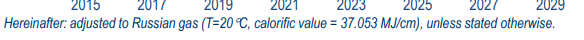

https://www.oxfordenergy.org/wpcms/wp-content/uploads/2020/09/Russian-Gas-the-year-of-living-dangerously.pdf

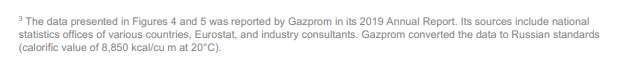

## API call to Enstog

In [8]:
#manual list of points on Entsog. 
both = pd.read_excel('working_data\pointsSAFE_EU27.xlsx',sheet_name='entry only')

#I am stripping out the useful part from the URL / api call. 
identifiers = []
for num in range(1,len(both['both'])):
    idt = both['both'][num][93:].split("&",1)[0]
    identifiers.append(idt)

In [9]:
dates = []
values = []
direction = []
operator = []
point = []
labels = []

urls = []
ids = []
# new addition to track exceptions
exc = []

for idt in identifiers:
    # print(idt)
    try:
        url = 'https://transparency.entsog.eu/api/v1/operationalData?forceDownload=true&pointDirection={}&from={}&to={}&indicator=Physical%20Flow&periodType=day&timezone=CET&limit=-1&dataset=1&directDownload=true'.format(idt,d1,d2)      
        r = requests.get(url)
        data = r.json()
        op = data['operationalData']

        for item in op:
            date = item['periodFrom'][:10]
            value = item['value']
            drc = item['directionKey']
            opr = item['operatorKey']
            pt = item['pointKey']
            label = item['pointLabel']

            dates.append(date)
            values.append(value)
            direction.append(drc)
            operator.append(opr)
            point.append(pt)
            labels.append(label)
            urls.append(url)
            ids.append(idt)
            
    except Exception as e:
        print(idt)          
        # print(e)
        exc.append(idt)
        # print(r.status_code)

fr-lso-0004lng-00020entry,fr-lso-0003lng-00025entry
fr-lso-0001lng-00047entry
fr-lso-0001lng-00047entry
nl-lso-0001lng-00027entry
gr-tso-0001lng-00014entry
tr-tso-0001itp-00041entry
ro-tso-0004itp-00154entry
ro-tso-0001itp-00084entry
ua-tso-0001itp-00307entry
hu-tso-0001itp-00095entry
ua-tso-0001itp-00089exit
ru-tso-0001itp-00050entry
ru-tso-0001itp-00187entry
ru-tso-0001itp-00243entry
fi-tso-0003itp-00024entry
no-tso-0001itp-00106entry
no-tso-0001itp-00210entry
nl-tso-0001itp-00161entry
no-tso-0001itp-00210entry
de-tso-0009itp-00108entry,de-tso-0002itp-00075entry,de-tso-0005itp-00086entry
no-tso-0001itp-00209entry
no-tso-0001itp-00209entry
no-tso-0001itp-00208entry
ru-tso-0002itp-00120entry
de-tso-0018itp-00501exit
de-tso-0018itp-00501exit
fr-tso-0003itp-00281entry
fr-tso-0003itp-00281exit,ch-dso-0003itp-00281entry
ch-tso-0002itp-00039entry,ch-tso-0001itp-00039entry
ch-tso-0002itp-00294entry,ch-tso-0001itp-00294entry
ch-dso-0001itp-00228entry
ch-dso-0002itp-00229entry
at-dso-0001itp-0

In [10]:
# Store all the entry points for which the API call failed
import csv
exceptions = [str(i) for i in exc]
with open(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\Imports\raw_data\checks\Exceptions (failed API calls)\{}.csv'.format(today), 'w', newline='') as file:
    writer = csv.writer(file)
    for item in exceptions:
        # Write each item as a separate row in the CSV file
        writer.writerow([item])

In [11]:
# if you need to check some specific idt
# idt = 'de-tso-0009itp-00525entry'
# url = 'https://transparency.entsog.eu/api/v1/operationalData?forceDownload=true&pointDirection={}&from={}&to={}&indicator=Physical%20Flow&periodType=day&timezone=CET&limit=-1&dataset=1&directDownload=true'.format(idt,d1,d2)      
# r = requests.get(url)
# print(r.status_code)
# data = r.json()
# op = data['operationalData']

In [12]:
df = pd.DataFrame()
df['dates'] = dates
df['values'] = values
df['direction'] = direction
df['operator'] = operator
df['location'] = point
df['label'] = labels
df['country'] = df['operator'].str[:2]

In [13]:
df.shape

(11597, 7)

In [14]:
df.shape

(11597, 7)

In [16]:
df.replace('', np.NaN)  #we set missing values to the numpy notation, NaN - easier to work with. 
df['values'] = pd.to_numeric(df['values'])  #because of initial missing values, the dataframe column was not integer. 
#We need to set it to integer to work with. 

In [17]:
#Merge with IEA point location data. Now we also know where the gas is coming from. 
mapping = pd.read_excel('working_data\locationsSAFE.xlsx')
mapping = mapping[['location','exportcountry','IEAname']] # IEA keep it only for checks
dfmerge = df.merge(mapping,on='location') ## this was deleting all values not matched up ... 
# Problem is that location is now the same in two instances...

In [18]:
#this checks for the data which is dropped when I match with IEA. This should only be dropping import/export points with
#Swizterland and the Balkans. 
set(df['label']) - set(dfmerge['label'])

## Newly added Moffat also in here. While Moffat (IE) stays. Not sure what's happening (?)

{'Bizzarone',
 'Greifswald / LBTG',
 'Griespass (CH) / Passo Gries (IT)',
 'Kireevo (BG) / Zaychar (RS)',
 'Kiskundorozsma-2 (HU) / Horgos (RS)',
 'Lubmin II',
 'Moffat',
 'Oltingue (FR) / Rodersdorf (CH)',
 'RC Basel',
 'RC Lindau',
 'RC Thayngen-Fallentor',
 'Teesside',
 'VIP Germany-CH',
 'Wallbach'}

#### Save the file

In [19]:
dfmerge.to_csv(r'raw_data/2023manual_EU27.csv') 

## Starting after API call 

In [20]:
df1 = pd.read_csv('raw_data/2015manual_EU27.csv',index_col=0)
df2 = pd.read_csv('raw_data/2016manual_EU27.csv',index_col=0)
df3 = pd.read_csv('raw_data/2017manual_EU27.csv',index_col=0)
df4 = pd.read_csv('raw_data/2018manual_EU27.csv',index_col=0)
df5 = pd.read_csv('raw_data/2019manual_EU27.csv',index_col=0)
df6 = pd.read_csv('raw_data/2020manual_EU27.csv',index_col=0)
df7 = pd.read_csv('raw_data/2021manual_EU27.csv',index_col=0)
df8 = pd.read_csv('raw_data/2022a_manual_EU27.csv',index_col=0)
df9 = pd.read_csv('raw_data/2022b_manual_EU27.csv',index_col=0)
df10 = pd.read_csv('raw_data/2023manual_EU27.csv',index_col=0)

In [21]:
df = pd.concat([df1,df2,df3,df4,df5,df6,df7,df8,df9,df10])

## Cleaning Data 

#### Check for what labels we do not have data in the last observation

In [22]:
labels = list(df.label.unique())
last_obs = today - timedelta(days=2)
print(last_obs)

2023-04-23


In [23]:
justified_missing = ['Revythoussa', # Greek LNG terminating operations in 2022
                     'Uzhgorod (UA) - Velké Kapušany (SK)', # changed name, now: UZHHOROD
                     'Nybro', # replaced by the baltic pipe
                     'Teesside', # UK domestic production and not LNG
                     'Dornum / NETRA (jordgas Transport)', # values valid only till 31.12.2017
                     'Emden (NPT) (GTS)', # excluded from the early days 
                     'Uzhgorod-2', 'Uzhgorod-3','Uzhgorod-4', 'Uzhgorod-1' # excluded from the early days 
                    ]

In [24]:
for label in labels:
    if df[(df['label']==label)&(df['dates']==str(last_obs))].empty == True: # if we are missing the latest observation for some label
        if label not in justified_missing: # and if that label is not in the list above
            print(label) # then print the problematic labels

Agia Triada
Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)
Drozdovichi (UA)  -Drozdowicze (PL) 
Misso Izborsk
Strandzha (BG) / Malkoclar (TR)
Mediesu Aurit (RO) - Tekovo (UA)
Isaccea (RO) - Orlovka (UA)
Beregdaróc 800 (HU) - Beregovo (UA) (HU>UA)
Sakiai
Dunkerque DKB (BE)
Imatra
Croatia LNG


In [13]:
# del df['IEAname'] # Now confident with the data, keep it in for checks

#### Getting EU flows to the UK and some cleaning (new)

##### First get the UK imports from the EU

In [25]:
## Maybe smarter top store locally

In [26]:
#manual list of Bacton and Zebrugge points on Entsog. 
UK_EU_identifiers = ['uk-tso-0004itp-00207exit','uk-tso-0003itp-00061entry']

dates_UK = []
values_UK = []
direction_UK = []
operator_UK = []
point_UK = []
labels_UK = []

urls = []
ids = []

for idt in UK_EU_identifiers:
    # print(idt)
    try:
        url = 'https://transparency.entsog.eu/api/v1/operationalData?forceDownload=true&pointDirection={}&from=2015-01-01&to={}&indicator=Physical%20Flow&periodType=day&timezone=CET&limit=-1&dataset=1&directDownload=true'.format(idt,today)
        r = requests.get(url)
        data = r.json()
        op = data['operationalData']

        for item in op:
            date = item['periodFrom'][:10]
            value = item['value']
            drc = item['directionKey']
            opr = item['operatorKey']
            pt = item['pointKey']
            label = item['pointLabel']

            dates_UK.append(date)
            values_UK.append(value)
            direction_UK.append(drc)
            operator_UK.append(opr)
            point_UK.append(pt)
            labels_UK.append(label)
            urls.append(url)
            ids.append(idt)
            
    except Exception as e:
        print(e)
        print(idt)  

In [27]:
UK_EU = pd.DataFrame()
UK_EU['dates'] = dates_UK
UK_EU['values'] = values_UK
UK_EU['direction'] = direction_UK
UK_EU['operator'] = operator_UK
UK_EU['location'] = point_UK
UK_EU['label'] = labels_UK
UK_EU['country'] = UK_EU['operator'].str[:2]

In [28]:
UK_EU.replace('', np.NaN)  #we set missing values to the numpy notation, NaN - easier to work with. 
UK_EU['values'] = pd.to_numeric(UK_EU['values'])  #because of initial missing values, the dataframe column was not integer. 

In [29]:
# Can be deleted 
# Interc = df[(df.label =='Zeebrugge IZT') & (df['exportcountry']=='Belgium')&(df['operator']=='BE-TSO-0001')]
# BBL = df[(df.label =='Bacton (BBL)') & (df['exportcountry']=='Netherlands')&(df['direction']=='exit')]

In [30]:
UK_EU.tail()

,dates,values,direction,operator,location,label,country
5761,2023-04-20,0.0,entry,UK-TSO-0003,ITP-00061,Zeebrugge IZT,UK
5762,2023-04-21,0.0,entry,UK-TSO-0003,ITP-00061,Zeebrugge IZT,UK
5763,2023-04-22,0.0,entry,UK-TSO-0003,ITP-00061,Zeebrugge IZT,UK
5764,2023-04-23,0.0,entry,UK-TSO-0003,ITP-00061,Zeebrugge IZT,UK
5765,2023-04-24,0.0,entry,UK-TSO-0003,ITP-00061,Zeebrugge IZT,UK


##### Then the other UK imports (new)

In [31]:
UK_imp = df[df.label.isin(['Milford Haven', 'Isle of Grain', 'St. Fergus', 'Easington'])] # 'Teesside' should be own production

In [32]:
UK_imp = pd.concat([UK_EU,UK_imp])

In [33]:
UK_imp = UK_imp.set_index(pd.DatetimeIndex(UK_imp['dates']))

In [34]:
UK_imp.label.unique()

array(['Bacton (BBL)', 'Zeebrugge IZT', 'Milford Haven', 'Isle of Grain',
       'St. Fergus', 'Easington'], dtype=object)

In [35]:
# # # present for only half of the dataset and creating problems when merging
del UK_imp['exportcountry']
del UK_imp['IEAname']

In [36]:
#Merge with IEA point location data, the export country and relevant aggregation
mapping = pd.read_excel('working_data\locationsSAFE.xlsx',sheet_name='UK')
mapping = mapping[['location','exportcountry','IEAname','aggregation']] # IEA keep it only for checks
df_UK = UK_imp.merge(mapping,on='location')

df_UK = df_UK.drop_duplicates()
df_UK = df_UK.drop_duplicates(subset=['dates', 'operator','label','country'], keep='last')
df_UK = df_UK.set_index(pd.DatetimeIndex(df_UK['dates']))

#### Get rid of UK entry points for the EU27 dataset (new)

In [37]:
# Exclude the UK imports and Teesside
df = df[~df.label.isin(['Teesside', 'Milford Haven', 'Isle of Grain', 'St. Fergus', 'Easington'])]

In [38]:
# Zeebrugge IZT, Bacton (BBL) and Moffat (IE) stay in df as UK exports to the EU

In [39]:
# Zeebrugge IZT has the UK and BE for entry and exit (respectively) 
## We want to keep only the entry point from the UK, so should be fine deleting it the "exit" observations later on
print(df[df['label']=='Zeebrugge IZT'].country.unique())
# Bacton has the UK for both its entry and exit 
print(df[df['label']=='Bacton (BBL)'].country.unique())

['BE' 'UK']
['UK']


In [40]:
# Make a index with single values (not the case till here)
df = df.reset_index()
del df['index']

In [41]:
# Creating a list with the index values of entry at Bacton 
Bacton_i = df[(df['label']=='Bacton (BBL)') & (df['direction']=='entry')].index

# # Forcibly set the importing country to the Netherlands for the entry point Bacton
for i in Bacton_i:
    df.loc[i,'country']='NL'

In [42]:
# UK_imp.label.unique()

#### Delete the extra points which Entsog records, but which seem superflous to IEA

In [43]:
dornum = df[(df['label'] == 'Dornum / NETRA (jordgas Transport)') & (df['dates'] < '2017-12-31')]
spainlng = df[(df['label'].isin(['Huelva', 'Cartagena', 'Sagunto', 'Barcelona', 'Bilbao'])) & (df['dates'] < '2020-04-01')]

In [44]:
#df = df[~df.label.isin(['Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)'])]

df = df[~df.label.isin(['Dornum / NETRA (OGE)','Dornum / NETRA (GUD)','Dornum / NETRA (jordgas Transport)'])]

df = df[~df.label.isin(['Huelva', 'Cartagena', 'Sagunto', 'Barcelona', 'Bilbao'])]

df = df[~df.label.isin(['Greifswald / Fluxys Deutschland','Greifswald / GUD'])]

df = df[~df.label.isin(['Uzhgorod-2', 'Uzhgorod-3','Uzhgorod-4', 'Uzhgorod-1'])]

df = df[~df.label.isin(['Emden (EPT1) (GUD)'])] #for now we keep but this may be adjusted back to include NL flows. 
#df = df[~df.label.isin(['Emden (EPT1) (GTS)', 'Emden (EPT1) (GUD)'])] #change on 19th Jan

df = df[~df.label.isin(['Melendugno - IT / TAP'])]
#otherwise we double count azerbaijan exports.

In [45]:
## replaced by GCP GAZ-SYSTEM/UA TSO since July 2020
droz = df[(df['label']== 'Drozdovichi (UA)  -Drozdowicze (PL) ') & (df['dates'] < '2020-07-01')]
#Drozdowicze, needed to be counted as 'entry', it is all listed as 'exit'. 
droz.loc[:,'direction'] = 'entry'
## careful because country = UA (removed later)
droz.loc[:,'country']='PL'

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_27040\1166160316.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  droz.loc[:,'direction'] = 'entry'
C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_27040\1166160316.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  droz.loc[:,'country']='PL'


In [46]:
df = pd.concat([df,spainlng,dornum,droz])
df = df.sort_values('dates')

In [47]:
# Checks for Norway # Can be removed
# Norway = ['North Sea Entry','Emden (EPT1) (GTS)', 'Emden (EPT1) (OGE)','Emden (EPT1) (Thyssengas)','Dunkerque','Dornum GASPOOL', 'Dornum / NETRA (jordgas Transport)','Zeebrugge ZPT']
# df[(df['label'].isin(Norway))&(df['dates']=='2023-01-01')]

In [48]:
df = df.replace('#N/A()',0) #string values breaking code - but this didn't work. 

In [49]:
df = df.dropna()
df = df[df['values']!=0]

In [50]:
df = df.drop_duplicates()
# The below adds to the previous line, which stopped doing the job on 04.04.2023 as there started to be two different values for the very same observation (hence not real duplicates)
df = df.drop_duplicates(subset=['dates', 'operator','label','country'], keep='first')

In [51]:
df.country.unique()

array(['FR', 'RO', 'IT', 'ES', 'IE', 'BE', 'GR', 'LT', 'DE', 'NL', 'PL',
       'PT', 'UA', 'SK', 'HU', 'DK', 'EE', 'UK', 'BG', 'FI', 'LV', 'AL',
       'HR'], dtype=object)

In [52]:
df = df[df['direction'] == 'entry']

In [53]:
df.country.unique()

array(['FR', 'RO', 'IT', 'ES', 'IE', 'BE', 'GR', 'LT', 'DE', 'NL', 'PL',
       'PT', 'SK', 'HU', 'DK', 'EE', 'BG', 'FI', 'LV', 'AL', 'UA', 'HR'],
      dtype=object)

In [54]:
## To compare across years we should delete Barcelona, Bilbao, and Cartagena because Entsog stops reporting them. 

In [55]:
#This creates dataframe for looking at individual countries 
dff = df.groupby(["country","dates","direction"])["values"].sum(numeric_only=True).reset_index()
dff['dates'] = dff['dates']
dff = dff.set_index(pd.DatetimeIndex(dff['dates']))

In [56]:
import os
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\Imports'

In [57]:
## Merge with the aggregation which we use. 
mapping = pd.read_excel('working_data/locationsSAFE.xlsx')
mapping = mapping[['location','aggregation','aggregation2','aggregation3']] ## to add 'IEAname'?
df1 = df.merge(mapping,on='location',how='inner')

df1 = df1[df1['country']!='UA'] #exclude Ukraine imports. 
df1 = df1.drop_duplicates(subset=['dates', 'operator','label','country'], keep='last')
df1 = df1.set_index(pd.DatetimeIndex(df1['dates']))

### Download

In [58]:
Share_point_data = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\Imports\EU27'

In [59]:
import os
os.chdir(Share_point_data)

In [60]:
from datetime import date
today = date.today()

In [61]:
last_obs = today - timedelta(days=2)
print(last_obs)

2023-04-23


In [62]:
enddate = last_obs
startdate = enddate - timedelta(days=30)

In [63]:
str(startdate)

'2023-03-24'

In [64]:
# Check if we have all observation for last Sunday 
print(len(df1[df1['dates']=='2023-01-17'])) # normal number of daily observation
len(df1[df1['dates']==str(enddate)])  # last Sunday 

34


34

In [65]:
# Here the values for which we had values on the 17th of August 2022 and for which we do not have them anymore
set(df1[df1['dates']=='2022-08-17']['label'])-set(df1[df1['dates']==str(enddate)]['label'])

{'Croatia LNG',
 'Greifswald / NEL',
 'Greifswald / OPAL',
 'Luhamaa',
 'Tarifa',
 'VIP Bereg (HU) / VIP Bereg (UA)'}

In [66]:
# Here the latest additions
set(df1[df1['dates']==str(enddate)]['label'])-set(df1[df1['dates']=='2022-08-17']['label'])

{'BRUNSBUETTEL HAFEN (FSRU) (DE)',
 'Baltic Energy Gate (Port) (DE)',
 'Cavarzere (Porto Levante / Adriatic LNG)',
 'Eems Energy Terminal',
 'Hamina LNG',
 'North Sea Entry',
 'Wilhelmshaven, LNG-Terminal 1 (DE)'}

#### Weekly Data

In [67]:
data = pd.DataFrame()
data['week'] = list(range(0,54,1))

plot = df1.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)[:enddate]/converter  # changed from df1
plot['week'] = plot.index.isocalendar().week

minvalues = plot['2015-01-05':'2021-01-02'].groupby('week').min()   # before '2015-01-05':'2021-01-02'
maxvalues = plot['2015-01-05':'2021-01-02'].groupby('week').max()   # before '2015-01-05':'2021-01-02'
# avgvalues = plot['2015-01-05':'2021-01-02'].groupby('week').mean()  # before '2015-01-05':'2021-01-02'

# values2017 = plot['2017-01-02':'2017-12-31'].groupby('week').max()
# values2018 = plot['2018-01-01':'2018-12-30'].groupby('week').max()
# values2019 = plot['2018-12-31':'2019-12-29'].groupby('week').max()
# values2020 = plot['2019-12-30':'2020-02-27'].groupby('week').max()       # before '2020-01-05':'2021-01-02'
values2021 = plot.loc['2020-12-28':'2022-01-02'].groupby('week').max()   # before '2020-12-28':'2022-01-02'
values2022 = plot.loc['2022-01-03':'2023-01-01'].groupby('week').max()   # before  '2022-01-03':
values2023 = plot.loc['2023-01-02':].groupby('week').max()         
    
data['EU_min'] = minvalues
data['EU_max'] = maxvalues
# data['EU_2017'] = values2017
# data['EU_2018'] = values2018
# data['EU_2019'] = values2019
# data['EU_2020'] = values2020
data['EU_2021'] = values2021
data['EU_2022'] = values2022
data['EU_2023'] = values2023

In [68]:
### For countries
for country in ['Russia','Norway','LNG','Algeria','UK']:
# for country in ['LNG', 'Algeria', 'Libya', 'Russia', 'Norway', 'UK', 'Azerbaijan']:

    ctemp = df1[df1['aggregation'] == country]
    cplot = ctemp.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)[:enddate]/converter
    cplot['week'] = cplot.index.isocalendar().week

    minvalues = cplot['2015-01-05':'2021-01-02'].groupby('week').min()  # before '2015-01-05':'2021-01-02'
    maxvalues = cplot['2015-01-05':'2021-01-02'].groupby('week').max()  # before '2015-01-05':'2021-01-02'
#     avgvalues = cplot['2015-01-05':'2021-01-02'].groupby('week').mean() # before '2015-01-05':'2021-01-02'

#     values2017 = cplot.loc['2017-01-02':'2017-12-31'].groupby('week').max()
#     values2018 = cplot.loc['2018-01-01':'2018-12-30'].groupby('week').max()
#     values2019 = cplot.loc['2018-12-31':'2019-12-29'].groupby('week').max()    
#     values2020 = cplot.loc['2019-12-30':'2020-12-27'].groupby('week').max()    # before '2020-01-05':'2021-01-02'
    values2021 = cplot.loc['2020-12-28':'2022-01-02'].groupby('week').max()    # before '2020-12-28':'2022-01-02'
    values2022 = cplot.loc['2022-01-03':'2023-01-01'].groupby('week').max()
    values2023 = cplot.loc['2023-01-02':].groupby('week').max()
    
    data['{}_min'.format(country)] = minvalues
    data['{}_max'.format(country)] = maxvalues
#     data['{}_avg'.format(country)] = avgvalues
#     data['{}_2017'.format(country)] = values2017
#     data['{}_2018'.format(country)] = values2018 
#     data['{}_2019'.format(country)] = values2019
#     data['{}_2020'.format(country)] = values2020
    data['{}_2021'.format(country)] = values2021 
    data['{}_2022'.format(country)] = values2022 
    data['{}_2023'.format(country)] = values2023 

data = data.round(1)
# data.to_csv('country data\country_data_{}.csv'.format(today))

In [69]:
# Other_21 = data['Azerbaijan_2021'].sum(numeric_only=True) +  data['Libya_2021'].sum(numeric_only=True)
# Other_22 = data['Azerbaijan_2022'].sum(numeric_only=True) +  data['Libya_2022'].sum(numeric_only=True)
# print(Other_22-Other_21)

##### UK imports (new)

In [70]:
df_UK.aggregation.unique()

array(['EU', 'LNG', 'Norway'], dtype=object)

In [71]:
UK = pd.DataFrame()
UK['week'] = list(range(0,54,1))

plot_UK = df_UK.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)[:enddate]/converter
plot_UK['week'] = plot_UK.index.isocalendar().week

UK_min = plot_UK['2015-01-05':'2021-01-02'].groupby('week').min()  # before '2015-01-05':'2021-01-02'
UK_max = plot_UK['2015-01-05':'2021-01-02'].groupby('week').max()  # before '2015-01-05':'2021-01-02'
# UK_avg = plot_UK['2015':'2020'].groupby('week').mean()

# UKvalues2017 = plot_UK.loc['2017-01-02':'2017-12-31'].groupby('week').max() 
# UKvalues2018 = plot_UK.loc['2018-01-01':'2018-12-30'].groupby('week').max() 
# UKvalues2019 = plot_UK.loc['2018-12-31':'2019-12-29'].groupby('week').max()
# UKvalues2020 = plot_UK.loc['2019-12-30':'2020-12-27'].groupby('week').max()
UKvalues2021 = plot_UK.loc['2020-12-28':'2022-01-02'].groupby('week').max() # before '2020-12-28':'2022-01-02'
UKvalues2022 = plot_UK.loc['2022-01-03':'2023-01-01'].groupby('week').max()
UKvalues2023 = plot_UK.loc['2023-01-02':].groupby('week').max()
    
UK['min'] = UK_min
UK['max'] = UK_max

# UK['2017'] = UKvalues2017
# UK['2018'] = UKvalues2018
# UK['2019'] = UKvalues2019
# UK['2020'] = UKvalues2020
UK['2021'] = UKvalues2021
UK['2022'] = UKvalues2022
UK['2023'] = UKvalues2023

In [72]:
### For countries
for source in ['Norway','LNG','EU']:

    UK_temp = df_UK[df_UK['aggregation'] == source]
    UK_plot = UK_temp.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)[:enddate]/converter
    UK_plot['week'] = UK_plot.index.isocalendar().week

    minvalues = UK_plot['2015-01-05':'2021-01-02'].groupby('week').min()    # before '2015-01-05':'2021-01-02'
    maxvalues = UK_plot['2015-01-05':'2021-01-02'].groupby('week').max()    # before '2015-01-05':'2021-01-02'
    avgvalues = UK_plot['2015':'2020'].groupby('week').mean()   

#     values2017 = UK_plot.loc['2017-01-02':'2017-12-31'].groupby('week').max()  
#     values2018 = UK_plot.loc['2018-01-01':'2018-12-30'].groupby('week').max()    
#     values2019 = UK_plot.loc['2018-12-31':'2019-12-29'].groupby('week').max()    
#     values2020 = UK_plot.loc['2019-12-30':'2020-12-27'].groupby('week').max()  
    values2021 = UK_plot.loc['2020-12-28':'2022-01-02'].groupby('week').max()      # before '2020-12-28':'2022-01-02'
    values2022 = UK_plot.loc['2022-01-03':'2023-01-01'].groupby('week').max()
    values2023 = UK_plot.loc['2023-01-02':].groupby('week').max()
    
    
    UK['{}_min'.format(source)] = minvalues
    UK['{}_max'.format(source)] = maxvalues
#     UK['{}_avg'.format(source)] = avgvalues
#     UK['{}_2017'.format(source)] = values2017 
#     UK['{}_2018'.format(source)] = values2018 
#     UK['{}_2019'.format(source)] = values2019
#     UK['{}_2020'.format(source)] = values2020
    UK['{}_2021'.format(source)] = values2021 
    UK['{}_2022'.format(source)] = values2022 
    UK['{}_2023'.format(source)] = values2023 

UK = UK.round(1)
# UK.to_csv('country data\UK_data_{}.csv'.format(today))

##### Net EU imports from the UK (new)

In [73]:
#Check
# df1[df1['aggregation'] == 'UK'].loc['2022-06-27':'2022-07-03']['values'].sum(numeric_only=True)/converter
# df1[df1['aggregation'] == 'UK'].loc['2022-07-04':'2022-07-10'].groupby([pd.Grouper(freq='W'),'label']).sum(numeric_only=True)/converter

In [74]:
## Make the two dataframes
EU_temp = df1[df1['aggregation'] == 'UK']
EU_plot = EU_temp.groupby(pd.Grouper(freq='D')).sum(numeric_only=True)[:enddate]
# EU_plot['week'] = EU_plot.index.isocalendar().week

UK_temp = df_UK[df_UK['aggregation'] == 'EU']
UK_plot = UK_temp.groupby(pd.Grouper(freq='D')).sum(numeric_only=True)[:enddate]
# UK_plot['week'] = UK_plot.index.isocalendar().week

In [75]:
Net_imports = EU_plot-UK_plot
Net_imp = Net_imports.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)[:enddate]/converter
Net_imp['week'] = Net_imp.index.isocalendar().week

In [76]:
df_UK

,dates,values,direction,operator,location,label,country,exportcountry,IEAname,aggregation
dates,,,,,,,,,,
2015-10-30,2015-10-30,0.0,exit,UK-TSO-0004,ITP-00207,Bacton (BBL),UK,Netherlands,BBL,EU
2015-10-31,2015-10-31,0.0,exit,UK-TSO-0004,ITP-00207,Bacton (BBL),UK,Netherlands,BBL,EU
2015-11-01,2015-11-01,29611399.2,exit,UK-TSO-0004,ITP-00207,Bacton (BBL),UK,Netherlands,BBL,EU
2015-11-02,2015-11-02,148703041.8,exit,UK-TSO-0004,ITP-00207,Bacton (BBL),UK,Netherlands,BBL,EU
2015-11-03,2015-11-03,127542475.0,exit,UK-TSO-0004,ITP-00207,Bacton (BBL),UK,Netherlands,BBL,EU
...,...,...,...,...,...,...,...,...,...,...
2023-04-19,2023-04-19,434587508.0,entry,UK-TSO-0001,ITP-00091,Easington,UK,Norway,Easington,Norway
2023-04-20,2023-04-20,413842231.0,entry,UK-TSO-0001,ITP-00091,Easington,UK,Norway,Easington,Norway
2023-04-21,2023-04-21,411742529.0,entry,UK-TSO-0001,ITP-00091,Easington,UK,Norway,Easington,Norway


In [77]:
min_net = Net_imp['2015-01-05':'2021-01-02'].groupby('week').min()   # before '2015-01-05':'2021-01-02'
max_net = Net_imp['2015-01-05':'2021-01-02'].groupby('week').max()   # before '2015-01-05':'2021-01-02'
# avg_net = Net_imp['2015':'2020'].groupby('week').mean()   

# Net_2017 = Net_imp.loc['2017-01-02':'2017-12-31'].groupby('week').max()
# Net_2018 = Net_imp.loc['2018-01-01':'2018-12-30'].groupby('week').max()
# Net_2019 = Net_imp.loc['2018-12-31':'2019-12-29'].groupby('week').max()
# Net_2020 = Net_imp.loc['2019-12-30':'2020-12-27'].groupby('week').max()
Net_2021 = Net_imp.loc['2020-12-28':'2022-01-02'].groupby('week').max()
Net_2022 = Net_imp.loc['2022-01-03':'2023-01-01'].groupby('week').max()
Net_2023 = Net_imp.loc['2023-01-02':].groupby('week').max()

In [78]:
Net = pd.DataFrame()
Net['week'] = list(range(0,54,1))
Net['EU_UK_net_min'] = min_net
Net['EU_UK_net_max'] = max_net
# Net['EU_UK_net_avg'] = avg_net
# Net['EU_UK_net_2017'] = Net_2017
# Net['EU_UK_net_2018'] = Net_2018 
# Net['EU_UK_net_2019'] = Net_2019 
# Net['EU_UK_net_2020'] = Net_2020
Net['EU_UK_net_2021'] = Net_2021 
Net['EU_UK_net_2022'] = Net_2022 
Net['EU_UK_net_2023'] = Net_2023
Net = Net.round(1)

In [79]:
import os
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\Imports\\EU27'

In [80]:
# Outdated can be deleted
with pd.ExcelWriter("country data\country_data_{}.xlsx".format(today)) as writer:
# Excelwriter = pd.ExcelWriter("country data\country_data_Nat_Geo.xlsx",engine="xlsxwriter")
    Excelwriter = pd.ExcelWriter("country data\country_data_{}.xlsx".format(today),engine="xlsxwriter")
    data.to_excel(Excelwriter, sheet_name="EU27 gross imports ", index=False)
    UK.to_excel(Excelwriter, sheet_name="UK gross imports", index=False)
    Net.to_excel(Excelwriter, sheet_name="EU27 net UK imports", index=False)
Excelwriter.close()
Excelwriter.save()

# # Excelwriter function
# with pd.ExcelWriter("path_to_file.xlsx", mode="a", engine="openpyxl") as writer:
     
#     # use to_excel function and specify the sheet_name and index to
#     # store the dataframe in specified sheet
#     data_frame4.to_excel(writer, sheet_name="Cool drinks")

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_27040\1490163803.py:9: FutureWarning: save is not part of the public API, usage can give unexpected results and will be removed in a future version
  Excelwriter.save()
C:\Users\giovanni.sgaravatti\anaconda3\lib\site-packages\xlsxwriter\workbook.py:339: UserWarning: Calling close() on already closed file.
  warn("Calling close() on already closed file.")


In [81]:
#For routes 
rdata = pd.DataFrame()
rdata['week'] = list(range(0,54,1))

for route in ['Nord Stream','Ukraine Gas Transit','Yamal (BY,PL)']:

    ctemp = df1[df1['aggregation2'] == route]
    cplot = ctemp.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)[:enddate]/converter
    cplot['week'] = cplot.index.isocalendar().week

    minvalues = cplot['2015-01-05':'2021-01-02'].groupby('week').min()
    maxvalues = cplot['2015-01-05':'2021-01-02'].groupby('week').max()
#     avgvalues = cplot['2015':'2020'].groupby('week').mean()
   
#     values2017 = cplot.loc['2017-01-02':'2017-12-31'].groupby('week').max() 
#     values2018 = cplot.loc['2018-01-01':'2018-12-30'].groupby('week').max()
#     values2019 = cplot.loc['2018-12-31':'2019-12-29'].groupby('week').max()
#     values2020 = cplot.loc['2019-12-30':'2020-12-27'].groupby('week').mean()  # before 2020-01-05':'2021-01-02
    values2021 = cplot.loc['2020-12-28':'2022-01-02'].groupby('week').max() # before 2020-12-28':'2022-01-02
    values2022 = cplot.loc['2022-01-03':'2023-01-01'].groupby('week').max()
    values2023 = cplot.loc['2023-01-02':].groupby('week').max()
    
    rdata['{}_min'.format(route)] = minvalues
    rdata['{}_max'.format(route)] = maxvalues
#     rdata['{}_2017'.format(route)] = values2017                   
#     rdata['{}_2018'.format(route)] = values2018   
#     rdata['{}_2019'.format(route)] = values2019   
#     rdata['{}_2020'.format(route)] = values2020                   
    rdata['{}_2021'.format(route)] = values2021
    rdata['{}_2022'.format(route)] = values2022
    rdata['{}_2023'.format(route)] = values2023

rdata = rdata.round(1)

## Add Turkstream
turk = df1[df1['label'].isin(['Strandzha 2 (BG) / Malkoclar (TR)','Strandzha (BG) / Malkoclar (TR)'])]
turk = turk.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)[:enddate]/converter
turk['week'] = turk.index.isocalendar().week
values20 = turk.loc['2019-12-30':'2020-12-27'].groupby('week').mean()
values21 = turk.loc['2020-12-28':'2022-01-02'].groupby('week').mean()  # before '2020-12-28':'2022-01-02'
values22 = turk.loc['2022-01-03':'2023-01-01'].groupby('week').mean()
values23 = turk.loc['2023-01-02':].groupby('week').mean()

rdata['turkstream20'] = values20.round(1)
rdata['turkstream21'] = values21.round(1)
rdata['turkstream22'] = values22.round(1)
rdata['turkstream23'] = values23.round(1)

# rdata.to_csv(r'route data\route_data_Nat Geo{}.csv'.format(today))
rdata.to_csv(r'route data\route_data_{}.csv'.format(today))

#### Daily Data 

In [82]:
# startdate='2015-01-01'
enddate= today

In [83]:
Ddata = df1.groupby(pd.Grouper(freq='D')).sum(numeric_only=True)[startdate:enddate]/converter

for country in ['Norway','Algeria','LNG','Russia','Azerbaijan']:

    cdtemp = df1[df1['aggregation'] == country]
    cdplot = cdtemp.groupby(pd.Grouper(freq='D')).sum(numeric_only=True)[startdate:enddate]/converter
    
    Ddata['{}'.format(country)] = cdplot #add data to Dataframe for export. 

   # fig, ax = plt.subplots(figsize=(8, 8))
   # ax.plot(cdplot['values'])

   # plt.xticks(rotation=45)
    #plt.title('Daily imports from {}'.format(country),fontsize='16')
    #plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)

    plt.show()
    #fig.savefig('figures/DAILY_{}_imports.png'.format(country),dpi=300,bbox_inches="tight")

In [84]:
Ddata['Norway'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)

dates
2023-03-26     797.822445
2023-04-02    1823.831048
2023-04-09    1874.522449
2023-04-16    1905.726876
2023-04-23    1867.082390
2023-04-30     244.420493
Freq: W-SUN, Name: Norway, dtype: float64

In [85]:
Ddata['UK net flows'] = Net_imports.groupby(pd.Grouper(freq='D')).sum(numeric_only=True)[startdate:enddate]/converter

In [86]:
for route in ['Nord Stream','Ukraine Gas Transit','Yamal (BY,PL)','Turkstream']:

    rdtemp = df1[df1['aggregation2'] == route]
    rdplot = rdtemp.groupby(pd.Grouper(freq='D')).sum(numeric_only=True)[startdate:enddate]/converter
    
    Ddata['{}'.format(route)] = rdplot #add data to Dataframe for export. 

    #fig, ax = plt.subplots(figsize=(8, 8))

   # ax.plot(cdplot['values'],color='red')

    #plt.xticks(rotation=45)
    #plt.title('Daily imports from {}'.format(route),fontsize='16')
    #plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)

    #plt.show()
#    fig.savefig('figures/DAILY_{}_imports.png'.format(route),dpi=300,bbox_inches="tight")

In [87]:
Ddata = Ddata.round(1)
Ddata.to_csv('daily data\daily_data_{}.csv'.format(today))
# Ddata.to_csv('daily data\daily_data_hist.csv'.format(today))

In [88]:
## Useless to delete 

#To play with (deleting UK data)
dff1 = df1.loc['2015':]

noUK = dff1[dff1['country'] != 'UK']
plotM = noUK.groupby(pd.Grouper(freq='M')).sum(numeric_only=True)[:enddate]/converter
plotM['month'] = plotM.index.month

noRUS = noUK[noUK['aggregation'] != 'Russia']
plotR = noRUS.groupby(pd.Grouper(freq='M')).sum(numeric_only=True)[:enddate]/converter
plotR['month'] = plotR.index.month

plotR.to_csv(r'MONTHLY imports\noRUS_MONTHLYimports {}.csv'.format(today))
plotM.to_csv(r'MONTHLY imports\MONTHLYimports {}.csv'.format(today))

#### Monthly

In [57]:
converter

10300000

In [58]:
data = pd.DataFrame()
data['month'] = list(range(0,13,1))

plot = df1.groupby(pd.Grouper(freq='M')).sum(numeric_only=True)[:enddate]/converter
plot['month'] = plot.index.month

# minvalues = plot['2019':'2021'].groupby('month').min()
# maxvalues = plot['2019':'2021'].groupby('month').max()
# avgvalues = plot['2019':'2021'].groupby('month').mean()

# values2019 = plot.loc['2019'].groupby('month').max()
values2020 = plot.loc['2020-01-05':'2021-01-02'].groupby('month').max()
values2021 = plot.loc['2020-12-28':'2022-01-02'].groupby('month').max()
values2022 = plot.loc['2022-01-03':'2023-01-01'].groupby('month').max()
values2023 = plot.loc['2023-01-02':'2023-03-31'].groupby('month').max()
    
# data['EU_min'] = minvalues
# data['EU_max'] = maxvalues
# data['EU_2019'] = values2019
data['EU_2020'] = values2020
data['EU_2021'] = values2021
data['EU_2022'] = values2022
data['EU_2023'] = values2023

In [59]:
### For countries
for country in ['Russia','Norway','Algeria','Azerbaijan','LNG','UK']: 

    ctemp = df1[df1['aggregation'] == country]
    cplot = ctemp.groupby(pd.Grouper(freq='M')).sum(numeric_only=True)[:enddate]/converter
    cplot['month'] = cplot.index.month

#     minvalues = cplot['2019':'2021'].groupby('month').min()
#     maxvalues = cplot['2019':'2021'].groupby('month').max()
#     avgvalues = cplot['2019':'2021'].groupby('month').mean()   
    
#     values2019 = cplot.loc['2019'].groupby('month').max()
    values2020 = cplot.loc['2020-01-05':'2021-01-02'].groupby('month').max()
    values2021 = cplot.loc['2020-12-28':'2022-01-02'].groupby('month').max()
    values2022 = cplot.loc['2022-01-03':'2023-01-01'].groupby('month').max()
    values2023 = cplot.loc['2023-01-02':'2023-03-31'].groupby('month').max()
    
#     data['{}_min'.format(country)] = minvalues
#     data['{}_max'.format(country)] = maxvalues
#     data['{}_avg'.format(country)] = avgvalues
#     data['{}_2019'.format(country)] = values2019
    data['{}_2020'.format(country)] = values2020
    data['{}_2021'.format(country)] = values2021 
    data['{}_2022'.format(country)] = values2022 
    data['{}_2023'.format(country)] = values2023 

data = data.round(1)
data.to_csv('MONTHLY imports\country_data_monthly_with_UK_{}.csv'.format(today))

### Single-out Iberia

In [64]:
Iberia = df1[df1['country'].isin(['ES','PT'])]

In [67]:
data = pd.DataFrame()
data['month'] = list(range(0,13,1))

plot = Iberia.groupby(pd.Grouper(freq='M')).sum(numeric_only=True)[:enddate]/1000000000 #converter
plot['month'] = plot.index.month

### For countries
for country in ['Algeria', 'LNG']: 

    ctemp = Iberia[Iberia['aggregation'] == country]
    cplot = ctemp.groupby(pd.Grouper(freq='M')).sum(numeric_only=True)[:enddate]/1000000000 #converter
    cplot['month'] = cplot.index.month

    values2021 = cplot.loc['2020-12-28':'2022-01-02'].groupby('month').max()
    values2022 = cplot.loc['2022-01-03':'2023-01-01'].groupby('month').max()
    values2023 = cplot.loc['2023-01-02':'2023-03-31'].groupby('month').max()
    
    data['{}_2021'.format(country)] = values2021 
    data['{}_2022'.format(country)] = values2022 
    data['{}_2023'.format(country)] = values2023 

data = data.round(1)
data.to_csv('MONTHLY imports\iberia monthly.csv'.format(today))

### Checks

#### Eurostat checks

In [44]:
df_euro = eurostat.get_data_df('nrg_ti_gasm') #this is the code for pply, transformation and consumption of gas - monthly data
EU_imports = df_euro[df_euro['unit'] == 'MIO_M3'] #filter to have only the unit million cubic metres.

In [63]:
gas_type = {'G3000':'piped','G3200':'LNG'} 
df_euro['siec'].replace(gas_type, inplace=True)

In [64]:
df_euro = df_euro[df_euro['unit']=='MIO_M3']
# df_euro = df_euro[df_euro['partener'].isin([''])

In [67]:
df_euro.head()

,freq,siec,partner,unit,geo\TIME_PERIOD,2008-01,2008-02,2008-03,2008-04,2008-05,...,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01
0,M,piped,AD,MIO_M3,AL,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,M,piped,AD,MIO_M3,AT,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,M,piped,AD,MIO_M3,BE,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,M,piped,AD,MIO_M3,BG,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,M,piped,AD,MIO_M3,CY,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [68]:
dates = df_euro.iloc[:,5:]

In [72]:
dates_col = dates.columns

In [125]:
df_eurostat = pd.melt(df_euro, id_vars =['siec','partner','geo\\TIME_PERIOD'],value_vars=dates,var_name='dates')

In [126]:
#setting the index as datetime. 
df_eurostat = df_eurostat.set_index(pd.DatetimeIndex(df_eurostat['dates']))

In [127]:
del df_eurostat['dates']

In [128]:
df_eurostat.rename({'geo\\TIME_PERIOD':'importer'},axis=1,inplace=True)

In [231]:
countries_map = {'RU':'Russia','NO':'Norway','DZ':'Algeria','AZ':'Azerbaijan','LY':'Libya'}
df_eurostat['partner'].replace(countries_map, inplace=True)

In [57]:
df_check = df
df_check = df_check.set_index(pd.DatetimeIndex(df_check['dates']))

In [233]:
countries = ['Algeria', 'Libya', 'Russia', 'Norway', 'UK', 'Azerbaijan']

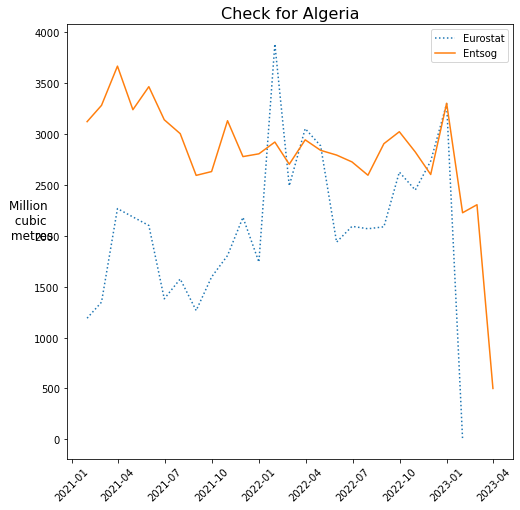

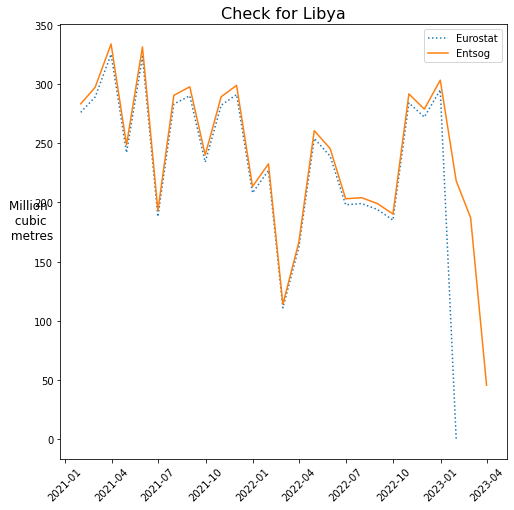

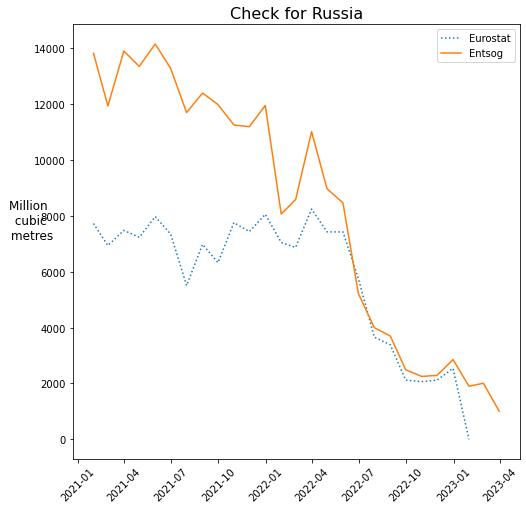

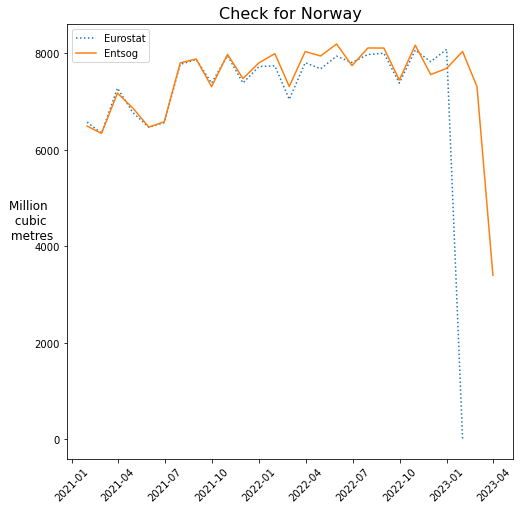

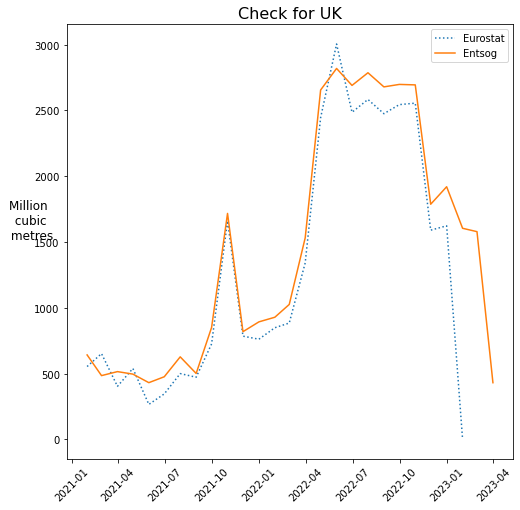

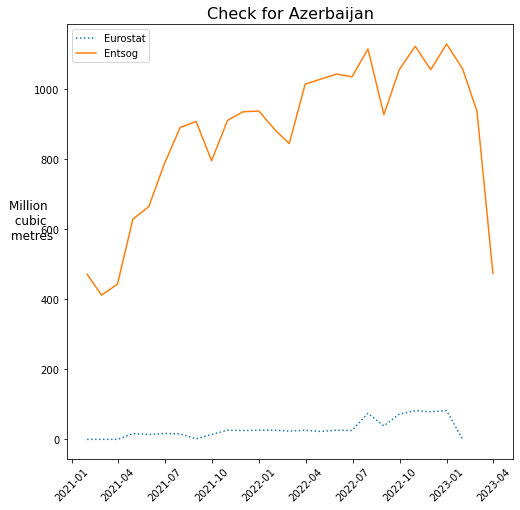

In [234]:
for country in countries:
    eurostat_c = df_eurostat[(df_eurostat['importer']=='EU27_2020')&(df_eurostat['partner']==country)&(df_eurostat['siec']=='piped')]['value']
    eurostat_plot = eurostat_c.groupby(pd.Grouper(freq='M')).sum(numeric_only=True)['2021':]
    entsog_c = df1[df1['aggregation'] == country]
    cplot = entsog_c.groupby(pd.Grouper(freq='M')).sum(numeric_only=True)['2021':]/converter
    
    fig, ax = plt.subplots(figsize=(8, 8))

    ax.plot(eurostat_plot,label='Eurostat',linestyle=':')
    ax.plot(cplot,label='Entsog')

    plt.xticks(rotation=45)
    plt.title('Check for {}'.format(country),fontsize='16')
    plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)
    plt.legend(loc='best')

#### Baltic pipe check vs IEA

In [62]:
baltic_pipe = df_check[df_check['label']=='North Sea Entry'].groupby(pd.Grouper(freq='M')).sum(numeric_only=True)/converter

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_7956\2324345549.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  baltic_pipe = df_check[df_check['label']=='North Sea Entry'].groupby(pd.Grouper(freq='M')).sum()/converter


In [63]:
baltic_pipe

,values
dates,
2022-11-30,8.163616
2022-12-31,373.186679
2023-01-31,664.588564
2023-02-28,624.850568
2023-03-31,702.134563
2023-04-30,64.089086


In [46]:
df_check[df_check['label']=='Mazara del Vallo']

,dates,values,direction,operator,location,label,country,exportcountry,IEAname
dates,,,,,,,,,
2015-01-01,2015-01-01,449049334.5,entry,IT-TSO-0001,ITP-00093,Mazara del Vallo,IT,Tunisia,Mazara del Vallo
2015-01-02,2015-01-02,438309474.0,entry,IT-TSO-0001,ITP-00093,Mazara del Vallo,IT,Tunisia,Mazara del Vallo
2015-01-03,2015-01-03,377098718.2,entry,IT-TSO-0001,ITP-00093,Mazara del Vallo,IT,Tunisia,Mazara del Vallo
2015-01-04,2015-01-04,354604263.0,entry,IT-TSO-0001,ITP-00093,Mazara del Vallo,IT,Tunisia,Mazara del Vallo
2015-01-05,2015-01-05,373076466.8,entry,IT-TSO-0001,ITP-00093,Mazara del Vallo,IT,Tunisia,Mazara del Vallo
...,...,...,...,...,...,...,...,...,...
2023-03-01,2023-03-01,534436114.0,entry,IT-TSO-0001,ITP-00093,Mazara del Vallo,IT,Tunisia,Mazara del Vallo
2023-03-02,2023-03-02,632963157.0,entry,IT-TSO-0001,ITP-00093,Mazara del Vallo,IT,Tunisia,Mazara del Vallo
2023-03-03,2023-03-03,480365552.0,entry,IT-TSO-0001,ITP-00093,Mazara del Vallo,IT,Tunisia,Mazara del Vallo


In [50]:
mazara = df_check[df_check['label']=='Mazara del Vallo']['values'] #.groupby(pd.Grouper(freq='M')).sum(numeric_only=True)/converter

In [51]:
mazara['2022-01-01']

691231271.0

#### Random checks

<AxesSubplot:xlabel='dates'>

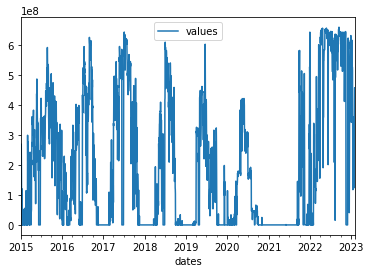

In [94]:
df1[df1['label'] == 'Zeebrugge IZT'].plot()

<AxesSubplot:xlabel='dates'>

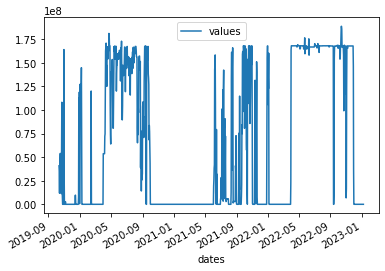

In [81]:
df1[df1['label'] == 'Bacton (BBL)'].plot()

In [62]:
## Check the weekly values for Russia
# df_checks = df1[df1['aggregation']=='Russia']

# df_checks['dates'] = pd.to_datetime(df_checks['dates'], format='%Y/%m/%d')
# # # Create new columns for week number and year
# df_checks['week_number'] = df_checks['dates'].dt.week
# df_checks['year'] = df_checks['dates'].dt.year

# # # Create the pivot table
# table = pd.pivot_table(df_checks, values='values', index=['week_number'],columns=['year'], aggfunc='sum')

# # # Print the pivot table
# print(table)

In [63]:
df1[df1['aggregation2']=='Ukraine Gas Transit'].loc['2020-04-13':'2020-05-03'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)/converter

,values
dates,
2020-04-19,991.572473
2020-04-26,967.468139
2020-05-03,931.720721


In [73]:
#This creates dataframe for looking at EU27. 
EUdff = df.groupby(["country","dates","direction"])["values"].sum(numeric_only=True).reset_index()

EUdff['eu27'] = 'yes'
EUdff.loc[EUdff.country == 'UA', 'eu27'] = "no"
EUdff.loc[EUdff.country == 'UK', 'eu27'] = "yes"

EUdff = EUdff.groupby(["eu27","dates","direction"])["values"].sum(numeric_only=True).reset_index()
dff['dates'] = dff['dates'].str[:7]
EUdff = EUdff.set_index(pd.DatetimeIndex(EUdff['dates']))
EUdff.tail(3)

,eu27,dates,direction,values
dates,,,,
2023-01-01,yes,2023-01-01,entry,8.437682e+09
2023-01-02,yes,2023-01-02,entry,5.969310e+09
2023-01-03,yes,2023-01-03,entry,2.568566e+08


##### Year-to-date Aggregate Plots

In [57]:
#df1.to_csv('20152021rawdata.csv')

##### Plot revisions

In [59]:
## Number of observation with manual data
print(len(df1.loc['2015']))
print(len(df1.loc['2016']))
print(len(df1.loc['2017']))
print(len(df1.loc['2018']))
print(len(df1.loc['2019']))
print(len(df1.loc['2020']))
print(len(df1.loc['2021']))

16493
17261
17379
17290
17162
17359
17567


In [64]:
df1[df1['aggregation2']=='Ukraine Gas Transit']['label'].unique()

array(['Isaccea (RO) - Orlovka (UA) III',
       'VIP Mediesu Aurit - Isaccea (RO-UA)',
       'Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)',
       'Uzhgorod (UA) - Velké Kapušany (SK)',
       'Uzhhorod (UA) - Velké Kapušany (SK)', 'Budince',
       'Isaccea (RO) - Orlovka (UA) I', 'Isaccea (RO) - Orlovka (UA) II',
       'VIP Bereg (HU) / VIP Bereg (UA)', 'GCP GAZ-SYSTEM/UA TSO',
       'Drozdovichi (UA)  -Drozdowicze (PL) '], dtype=object)

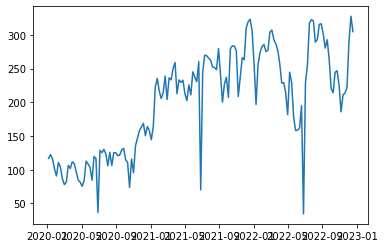

In [65]:
plt.plot(df1[df1['aggregation2']=='Turkstream'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)/converter)

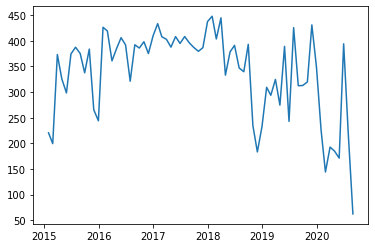

In [66]:
plt.plot(df1[df1['label']=='Drozdovichi (UA)  -Drozdowicze (PL) '].groupby(pd.Grouper(freq='M')).sum(numeric_only=True)/converter)

In [317]:
# this does not change df1
df1[df1['label'].isin(['Fos (Tonkin/Cavaou)', 'Montoir de Bretagne', 'Zeebrugge LNG',
       'Gate Terminal (I)', 'Eems Energy Terminal', 'Panigaglia', 'OLT LNG / Livorno',
       'Cavarzere (Porto Levante / Adriatic LNG)', 'Klaipeda (LNG)',
       'Agia Triada', # 'Teesside', 'Milford Haven',  'Isle of Grain',  # Removed UK LNG
       'Sines', 'Dunkerque LNG / PEG North', 'Swinoujscie', 'TVB',
       'Croatia LNG'])].loc['2022-10-03':].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)/converter

,values
dates,
2022-10-09,2203.452475
2022-10-16,2403.647696
2022-10-23,2087.255780
2022-10-30,2112.547305
2022-11-06,2379.563808
2022-11-13,2538.855803
2022-11-20,2512.314386
2022-11-27,2699.533249
2022-12-04,2678.852370


In [274]:
df1[df1['aggregation'] == 'LNG'].loc['2022-10-03':].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)/converter

,values
dates,
2022-10-09,2203.452475
2022-10-16,2403.647696
2022-10-23,2087.255780
2022-10-30,2112.547305
2022-11-06,2379.563808
2022-11-13,2538.855803
2022-11-20,2512.314386
2022-11-27,2699.533249
2022-12-04,2678.852370


In [275]:
df1['aggregation'].unique()

array(['LNG', 'Algeria', 'Libya', 'Russia', 'Norway', 'UK', 'Azerbaijan'],
      dtype=object)

In [276]:
df1[df1['aggregation2'] == 'Ukraine Gas Transit']['label'].unique()

array(['Isaccea (RO) - Orlovka (UA) III',
       'VIP Mediesu Aurit - Isaccea (RO-UA)',
       'Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)',
       'Uzhgorod (UA) - Velké Kapušany (SK)',
       'Uzhhorod (UA) - Velké Kapušany (SK)', 'Budince',
       'Drozdovichi (UA)  -Drozdowicze (PL) ',
       'Isaccea (RO) - Orlovka (UA) I', 'Isaccea (RO) - Orlovka (UA) II',
       'VIP Bereg (HU) / VIP Bereg (UA)', 'GCP GAZ-SYSTEM/UA TSO'],
      dtype=object)

#### Revisions check

In [123]:
df0 = pd.read_csv('raw_data/2015manual_EU27.csv',index_col=0)
df2 = pd.read_csv('raw_data/2016manual_EU27.csv',index_col=0)
df3 = pd.read_csv('raw_data/2017manual_EU27.csv',index_col=0)
df4 = pd.read_csv('raw_data/2018manual_EU27.csv',index_col=0)
df5 = pd.read_csv('raw_data/2019manual_EU27.csv',index_col=0)

df_new = pd.concat([df0,df2,df3,df4,df5])

df_1 =  pd.read_csv('raw_data/2015manual.csv',index_col=0)
df_2 =  pd.read_csv('raw_data/2016manual.csv',index_col=0)
df_3 =  pd.read_csv('raw_data/2017manual.csv',index_col=0)
df_4 =  pd.read_csv('raw_data/2018manual.csv',index_col=0)
df_5 =  pd.read_csv('raw_data/2019manual.csv',index_col=0)

df_old = pd.concat([df_1,df_2,df_3,df_4,df_5])

In [124]:
df_old.rename(columns = {'values':'valuesOLD'}, inplace=True)

In [125]:
df = df_new.merge(df_old[['valuesOLD','label','dates']],on=['label','dates'],how='outer')

In [126]:
df['dates'] = pd.to_datetime(df['dates'])
df.index = df['dates']

In [127]:
import matplotlib.pyplot as plt 
import plotly.express as px

In [84]:
df['label'].unique()

array(['Fos (Tonkin/Cavaou)', 'Wysokoje', 'Zeebrugge IZT', 'Gela',
       'Barcelona', 'Värska', 'Cartagena', 'Kondratki',
       'Isaccea (RO) - Orlovka (UA) III',
       'Cavarzere (Porto Levante / Adriatic LNG)',
       'Isaccea (RO) - Orlovka (UA) II', 'Emden (NPT) (GTS)',
       'Gate Terminal (I)', 'Revythoussa', 'Dunkerque', 'Huelva',
       'Isaccea (RO) - Orlovka (UA) I', 'Tieterowka', 'Sines',
       'Zeebrugge LNG', 'Sagunto', 'Moffat (IE)', 'Misso Izborsk',
       'Greifswald / NEL', 'Zeebrugge ZPT', 'Almería', 'Mazara del Vallo',
       'Kotlovka', 'Bilbao', 'Tarifa', 'Nybro', 'Emden (EPT1) (GTS)',
       'Greifswald / OPAL', 'Klaipeda (LNG)', 'Emden (EPT1) (Thyssengas)',
       'Uzhgorod (UA) - Velké Kapušany (SK)',
       'VIP Mediesu Aurit - Isaccea (RO-UA)', 'Budince',
       'Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)',
       'Emden (EPT1) (OGE)', 'OLT LNG / Livorno', 'Montoir de Bretagne',
       'Drozdovichi (UA)  -Drozdowicze (PL) ', 'Narva',
       'Dornum / NE

In [129]:
slash = ['Fos (Tonkin/Cavaou)','Cavarzere (Porto Levante / Adriatic LNG)','Dornum / NETRA (OGE)',
        'Dornum / NETRA (GUD)', 'Dornum / NETRA (jordgas Transport)','Strandzha (BG) / Malkoclar (TR)',
       'Greifswald / GUD', 'Greifswald / OPAL', 'Greifswald / NEL', 'Dunkerque LNG / PEG North', 'Beregdaróc 800 (HU) - Beregovo (UA) (HU>UA)',
       'Greifswald / Fluxys Deutschland','OLT LNG / Livorno','Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)']

In [130]:
df_clean = df[~df['label'].isin(slash)]

In [131]:
df_slash =df[df['label'].isin(slash)]

In [112]:
# pio.renderers.default = 'notebook'  # Set renderer to display plots inline in Jupyter notebook

for label in df_clean['label'].unique():
    temp = df_clean[df_clean['label']==label]
    fig = px.line(temp, x=temp['dates'], y=['values','valuesOLD'], template='plotly_dark',
                  title='{} Flows (in KWh)'.format(label))
#     fig.add_trace(x=temp['dates'], y=['valuesOLD')
    fig.write_html('raw_data/checks/{}.html'.format(label))

In [54]:
df1[df1['aggregation2'] == 'Ukraine Gas Transit']['label'].unique()

array(['Isaccea (RO) - Orlovka (UA) III',
       'VIP Mediesu Aurit - Isaccea (RO-UA)',
       'Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)',
       'Uzhgorod (UA) - Velké Kapušany (SK)', 'Budince',
       'Isaccea (RO) - Orlovka (UA) I', 'Isaccea (RO) - Orlovka (UA) II',
       'VIP Bereg (HU) / VIP Bereg (UA)', 'GCP GAZ-SYSTEM/UA TSO'],
      dtype=object)

In [55]:
df1[df1['label'] == 'Isaccea (RO) - Orlovka (UA) III']['2021']['values'].max()

C:\Users\GIOVAN~1.SGA\AppData\Local\Temp/ipykernel_27340/3790208742.py:1: FutureWarning: Indexing a DataFrame with a datetimelike index using a single string to slice the rows, like `frame[string]`, is deprecated and will be removed in a future version. Use `frame.loc[string]` instead.
  df1[df1['label'] == 'Isaccea (RO) - Orlovka (UA) III']['2021']['values'].max()


0.0

<AxesSubplot:xlabel='dates'>

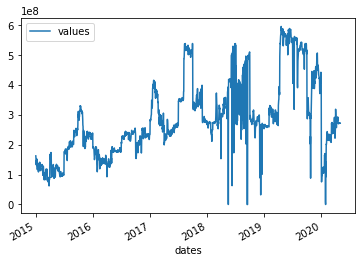

In [103]:
df1[df1['label'] == 'Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)'].plot()

In [57]:
df1[df1['aggregation2'] == 'Ukraine Gas Transit']['label'].unique()

array(['Isaccea (RO) - Orlovka (UA) III',
       'VIP Mediesu Aurit - Isaccea (RO-UA)',
       'Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)',
       'Uzhgorod (UA) - Velké Kapušany (SK)', 'Budince',
       'Isaccea (RO) - Orlovka (UA) I', 'Isaccea (RO) - Orlovka (UA) II',
       'VIP Bereg (HU) / VIP Bereg (UA)', 'GCP GAZ-SYSTEM/UA TSO'],
      dtype=object)

In [58]:
df1[df1['label'].isin(['Isaccea (RO) - Orlovka (UA) III',
                      'Isaccea (RO) - Orlovka (UA) II',
                      'Isaccea (RO) - Orlovka (UA) I'])]['values'].loc['2022'].sum(numeric_only=True)/1000000

4124.51625489

In [59]:
tots = []
for label in df1[df1['aggregation2'] == 'Ukraine Gas Transit']['label'].unique().tolist():
    tot = df1[df1['label'] == label]['values'].loc['2020'].sum(numeric_only=True)/converter
    tots.append(tot)
    
check = pd.DataFrame()
check['value'] = tots
check['label'] = df1[df1['aggregation2'] == 'Ukraine Gas Transit']['label'].unique().tolist()

In [60]:
check

,value,label
0,0.000000,Isaccea (RO) - Orlovka (UA) III
1,214.234739,VIP Mediesu Aurit - Isaccea (RO-UA)
2,2541.789287,Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)
3,36536.516146,Uzhgorod (UA) - Velké Kapušany (SK)
4,0.000000,Budince
5,702.517349,Isaccea (RO) - Orlovka (UA) I
6,0.000000,Isaccea (RO) - Orlovka (UA) II
7,4266.132981,VIP Bereg (HU) / VIP Bereg (UA)
8,1617.027681,GCP GAZ-SYSTEM/UA TSO


In [61]:
check['value'].sum(numeric_only=True)

45878.2181808736

In [62]:
df1[df1['aggregation2'] == 'Ukraine Gas Transit'].groupby(pd.Grouper(freq='A')).sum(numeric_only=True)/converter

,values
dates,
2015-12-31,52276.268634
2016-12-31,76996.543835
2017-12-31,88186.210445
2018-12-31,83746.536169
2019-12-31,84627.762114
2020-12-31,45878.218181
2021-12-31,39722.046749
2022-12-31,15990.071061


In [63]:
df1[df1['aggregation2'] == 'Ukraine Gas Transit']['label'].unique()

array(['Isaccea (RO) - Orlovka (UA) III',
       'VIP Mediesu Aurit - Isaccea (RO-UA)',
       'Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)',
       'Uzhgorod (UA) - Velké Kapušany (SK)', 'Budince',
       'Isaccea (RO) - Orlovka (UA) I', 'Isaccea (RO) - Orlovka (UA) II',
       'VIP Bereg (HU) / VIP Bereg (UA)', 'GCP GAZ-SYSTEM/UA TSO'],
      dtype=object)

### Weekly Gas Decomposed

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_7956\2526942178.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  isac = df1[df1['label'] == 'Isaccea (RO) - Orlovka (UA) III'].groupby(pd.Grouper(freq='W')).sum()
C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_7956\2526942178.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  med = df1[df1['label'] == 'VIP Mediesu Aurit - Isaccea (RO-UA)'].groupby(pd.Grouper(freq='W')).sum()
C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_7956\2526942178.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecate

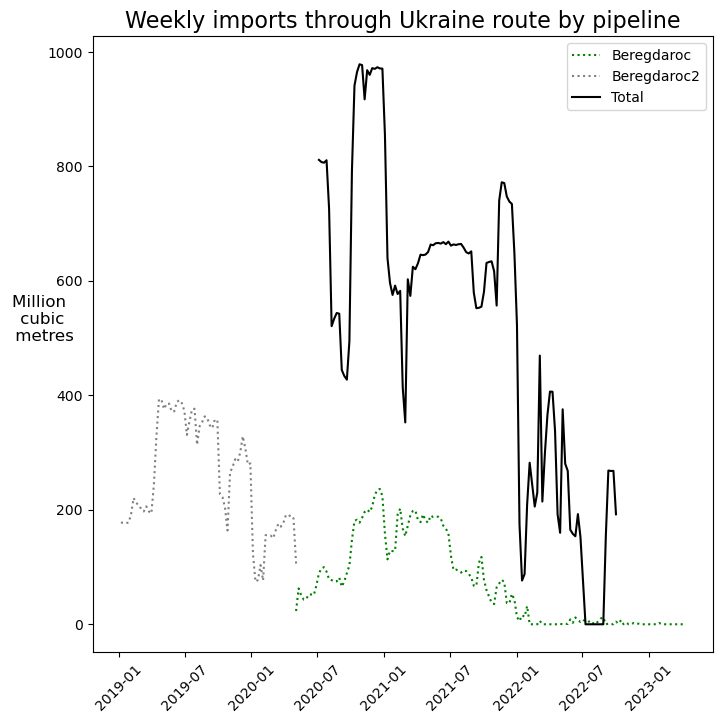

In [181]:
year = '2019'

isac = df1[df1['label'] == 'Isaccea (RO) - Orlovka (UA) III'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
isacplot = isac['values'][year:]/converter

med = df1[df1['label'] == 'VIP Mediesu Aurit - Isaccea (RO-UA)'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
medplot = med['values'][year:]/converter

bereg = df1[df1['label'] == 'VIP Bereg (HU) / VIP Bereg (UA)'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
beregplot = bereg['values'][year:]/converter

bereg2 = df1[df1['label'] == 'Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
bereg2plot = bereg2['values'][year:]/converter

uzg = df1[df1['label'] == 'Uzhgorod (UA) - Velké Kapušany (SK)'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
uzgplot = uzg['values'][year:]/converter

drz = df1[df1['label'] == 'GCP GAZ-SYSTEM/UA TSO'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
drzplot = drz['values'][year:]/converter

ukraine = df1[df1['aggregation2'] == 'Ukraine Gas Transit'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
ukrainePlot = ukraine['values'][year:]/converter

fig, ax = plt.subplots(figsize=(8, 8))

#ax.plot(isacplot,color='red',label='Isaccea',linestyle=':')
#ax.plot(medplot,color='blue',label='Mediesu Aurit',linestyle=':')
ax.plot(beregplot,color='green',label='Beregdaroc',linestyle=':')
ax.plot(bereg2plot,color='grey',label='Beregdaroc2',linestyle=':')
#ax.plot(uzgplot,color='brown',label='Velké Kapušany',linestyle=':')
#ax.plot(drzplot,color='orange',label='Drozdovichi',linestyle=':')

ax.plot(uzgplot+isacplot+medplot+drzplot,color='black',label='Total',alpha=1)
#ax.plot(ukrainePlot,color='grey',label='Reported Total')

plt.xticks(rotation=45)
plt.title('Weekly imports through Ukraine route by pipeline',fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)
plt.legend(loc='best')

In [ ]:
isac = df1[df1['label'] == 'Isaccea (RO) - Orlovka (UA) III']
isacplot = isac['values'][startdate:]/converter

med = df1[df1['label'] == 'VIP Mediesu Aurit - Isaccea (RO-UA)']
medplot = med['values'][startdate:]/converter

bereg = df1[df1['label'] == 'VIP Bereg (HU) / VIP Bereg (UA)']
beregplot = bereg['values'][startdate:]/converter

uzg = df1[df1['label'] == 'Uzhgorod (UA) - Velké Kapušany (SK)']
uzgplot = uzg['values'][startdate:]/converter

##Added in on 18th November
drz = df1[df1['label'] == 'GCP GAZ-SYSTEM/UA TSO']
drzplot = drz['values'][startdate:]/converter

## Code for figure

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(isacplot,color='red',label='Isaccea',linestyle=':',marker='o')
ax.plot(medplot,color='blue',label='Mediesu Aurit',linestyle=':',marker='o')
ax.plot(beregplot,color='green',label='Beregdaroc',linestyle=':',marker='o')
ax.plot(uzgplot,color='brown',label='Velké Kapušany',linestyle=':',marker='o',alpha=0.5)
ax.plot(drzplot,color='orange',label='Dostoevsky',linestyle=':',marker='o')

ax.plot(uzgplot+isacplot+medplot+beregplot+drzplot,color='black',label='Total',alpha=1)

date_form1 = DateFormatter("%m-%d")
ax.xaxis.set_major_formatter(date_form1)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.xticks(rotation=45)
plt.title('Daily imports through Ukraine route by pipeline',fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)
plt.legend(loc='best')

plt.show()
fig.savefig('figures/UkraineDAILY_18novupdate.png'.format(route),dpi=300,bbox_inches="tight")

### Daily Graphs decomposed by plants 

#### Norway

In [91]:
import os
os.getcwd()
import matplotlib.dates as mdates

In [92]:
startdate = '2023-01'

In [ ]:
 # df[(df['label'].isin(Norway))&(df['dates']=='2023-04-10')]

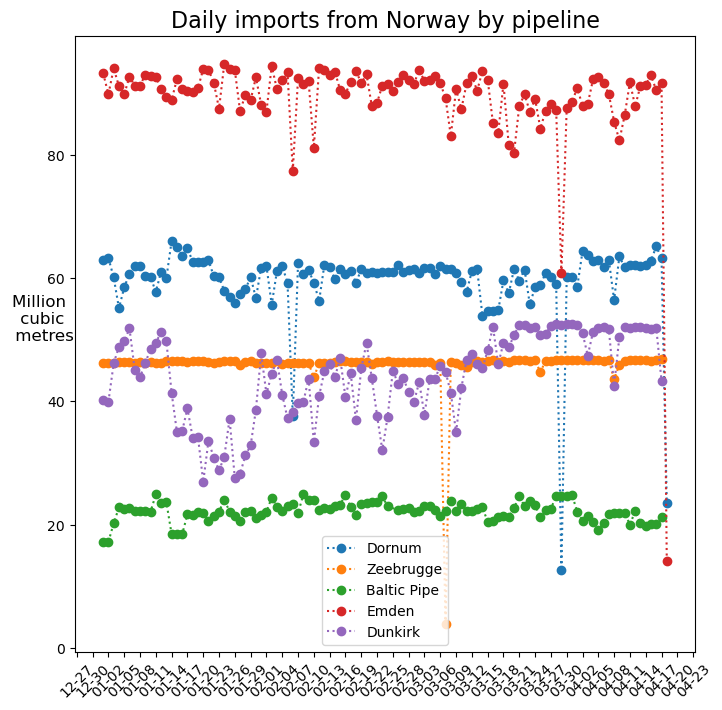

In [93]:
## List of considered plants 
# fergus = df1[df1['label'] == 'St. Fergus']
# fergusplot = fergus['values'][startdate:]/converter

# easington = df1[df1['label'] == 'Easington']
# easingtonplot = easington['values'][startdate:]/converter

zeebrugge = df1[df1['label'] == 'Zeebrugge ZPT']
zeebruggeplot = zeebrugge['values'][startdate:]/converter

balticpipe = df1[df1['label'] == 'North Sea Entry']
balticpipeplot = balticpipe['values'][startdate:]/converter

dornum = df1[df1['label'].isin(['Dornum GASPOOL', 'Dornum / NETRA (jordgas Transport)','Dornum / NETRA (GUD)','Dornum / NETRA (OGE)'])]
dornumplot = dornum.groupby(pd.Grouper(freq='D')).sum(numeric_only=True)[startdate:]/converter

dunkirk = df1[df1['label'].isin(['Dunkerque','Dunkerque DKB (BE)'])]
dunkirkplot = dunkirk.groupby(pd.Grouper(freq='D')).sum(numeric_only=True)[startdate:]/converter

emden = df1[df1['label'].isin(['Emden (EPT1) (GTS)', 'Emden (EPT1) (OGE)','Emden (EPT1) (Thyssengas)'])]
emdenplot = emden.groupby(pd.Grouper(freq='D')).sum(numeric_only=True)[startdate:]/converter

## Code for figure plot
fig, ax = plt.subplots(figsize=(8, 8))

# ax.plot(fergusplot,label='St. Fergus (UK)',linestyle=':',marker='o')
# ax.plot(easingtonplot,label='Easington (UK)',linestyle=':', marker='o')
ax.plot(dornumplot,label='Dornum',linestyle=':', marker='o')
ax.plot(zeebruggeplot,label='Zeebrugge',linestyle=':', marker='o')
ax.plot(balticpipeplot,label='Baltic Pipe',linestyle=':', marker='o')
ax.plot(emdenplot,label='Emden',linestyle=':', marker='o')
ax.plot(dunkirkplot,label='Dunkirk',linestyle=':', marker='o')

# ax.plot(zeebruggeplot+balticpipe['values']+dornumplot['values']+dunkirkplot['values']+emdenplot['values'],label='Total')

date_form1 = DateFormatter("%m-%d")
ax.xaxis.set_major_formatter(date_form1)
ax.xaxis.set_major_locator(ticker.MultipleLocator(3))

plt.xticks(rotation=45)
plt.title('Daily imports from Norway by pipeline',fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)
plt.legend(loc='best')

plt.show()
# fig.savefig('figures/NorwayDAILY.png'.format(route),dpi=300,bbox_inches="tight")

In [ ]:
df1[df1['label'].isin(['Dornum GASPOOL'])

In [165]:
df1[df1['label'].isin(['Dornum / NETRA (OGE)'])].tail(10)

,dates,values,direction,operator,location,label,country,exportcountry,IEAname,aggregation,aggregation2,aggregation3
dates,,,,,,,,,,,,


#### Algeria

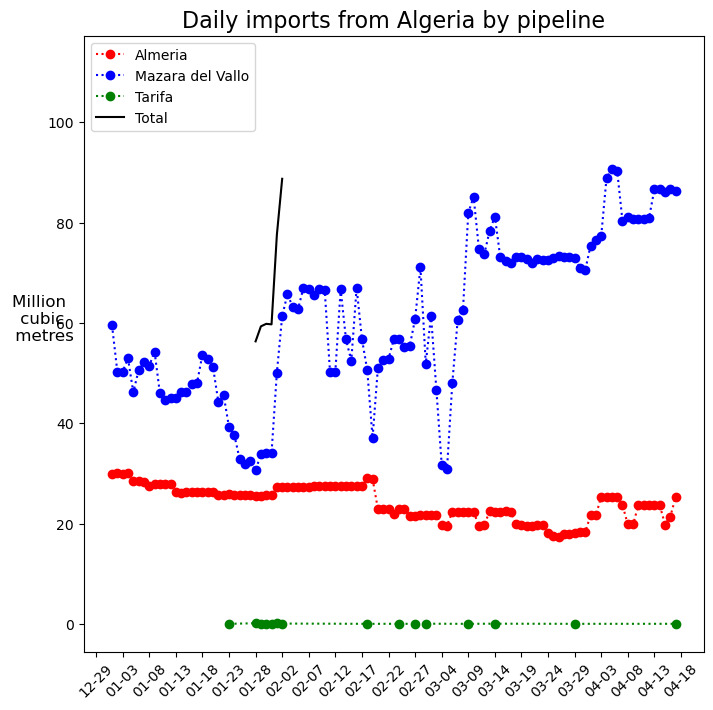

In [94]:
## List of plants

almeria = df1[df1['label'] == 'Almería']
almeriaplot = almeria['values'][startdate:]/converter

mazaro = df1[df1['label'] == 'Mazara del Vallo']
mazaroplot = mazaro['values'][startdate:]/converter

tarifa = df1[df1['label'] == 'Tarifa']
tarifaplot = tarifa['values'][startdate:]/converter

## Code for figure

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(almeriaplot,color='red',label='Almeria',linestyle=':',marker='o')
ax.plot(mazaroplot,color='blue',label='Mazara del Vallo',linestyle=':',marker='o')
ax.plot(tarifaplot,color='green',label='Tarifa',linestyle=':',marker='o')
ax.plot(almeriaplot+mazaroplot+tarifaplot,color='black',label='Total')

date_form1 = DateFormatter("%m-%d")
ax.xaxis.set_major_formatter(date_form1)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))

plt.xticks(rotation=45)
plt.title('Daily imports from Algeria by pipeline',fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)
plt.legend(loc='best')

plt.show()
fig.savefig('figures/AlgeriaDAILY.png'.format(route),dpi=300,bbox_inches="tight")

#### UK

In [95]:
df1[df1['aggregation']=='UK']['label'].unique()

array(['Moffat (IE)', 'Zeebrugge IZT', 'Bacton (BBL)'], dtype=object)

In [96]:
df1[df1['label'] == 'Zeebrugge IZT']

,dates,values,direction,operator,location,label,country,exportcountry,IEAname,aggregation,aggregation2,aggregation3
dates,,,,,,,,,,,,
2015-01-01,2015-01-01,92260248.0,entry,BE-TSO-0001,ITP-00061,Zeebrugge IZT,BE,United Kingdom,Interconnector,UK,ignore,ignore
2015-01-02,2015-01-02,83478419.0,entry,BE-TSO-0001,ITP-00061,Zeebrugge IZT,BE,United Kingdom,Interconnector,UK,ignore,ignore
2015-01-03,2015-01-03,107299290.0,entry,BE-TSO-0001,ITP-00061,Zeebrugge IZT,BE,United Kingdom,Interconnector,UK,ignore,ignore
2015-01-04,2015-01-04,91587742.0,entry,BE-TSO-0001,ITP-00061,Zeebrugge IZT,BE,United Kingdom,Interconnector,UK,ignore,ignore
2015-01-05,2015-01-05,181867997.0,entry,BE-TSO-0001,ITP-00061,Zeebrugge IZT,BE,United Kingdom,Interconnector,UK,ignore,ignore
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-24,2023-03-24,617760139.0,entry,BE-TSO-0001,ITP-00061,Zeebrugge IZT,BE,United Kingdom,Interconnector,UK,ignore,ignore
2023-03-25,2023-03-25,381605466.0,entry,BE-TSO-0001,ITP-00061,Zeebrugge IZT,BE,United Kingdom,Interconnector,UK,ignore,ignore
2023-03-26,2023-03-26,441656244.0,entry,BE-TSO-0001,ITP-00061,Zeebrugge IZT,BE,United Kingdom,Interconnector,UK,ignore,ignore


In [97]:
startdate

'2023-01'

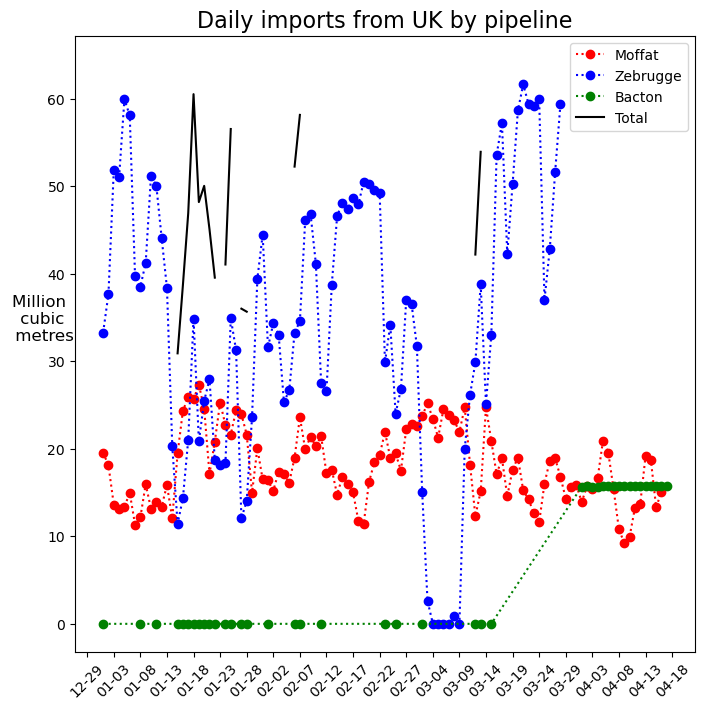

In [98]:
import matplotlib.dates as mdates

## List of plants

Moffat  = df1[df1['label'] == 'Moffat (IE)']
Moffatplot = Moffat['values'][startdate:]/converter

Zeebrugge_IZT = df1[df1['label'] == 'Zeebrugge IZT']
Zeebrugge_IZTplot = Zeebrugge_IZT['values'][startdate:]/converter

Bacton  = df1[df1['label'] == 'Bacton (BBL)']
Bactonplot = Bacton ['values'][startdate:]/converter

## Code for figure

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(Moffatplot,color='red',label='Moffat',linestyle=':',marker='o')
ax.plot(Zeebrugge_IZTplot,color='blue',label='Zebrugge',linestyle=':',marker='o')
ax.plot(Bactonplot,color='green',label='Bacton',linestyle=':',marker='o')
ax.plot(Moffatplot+Zeebrugge_IZTplot+Bactonplot,color='black',label='Total')

date_form1 = DateFormatter("%m-%d")
ax.xaxis.set_major_formatter(date_form1)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))

plt.xticks(rotation=45)
plt.title('Daily imports from UK by pipeline',fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)
plt.legend(loc='best')

plt.show()
fig.savefig('figures/UK_DAILY.png'.format(route),dpi=300,bbox_inches="tight")

#### Yamal Route

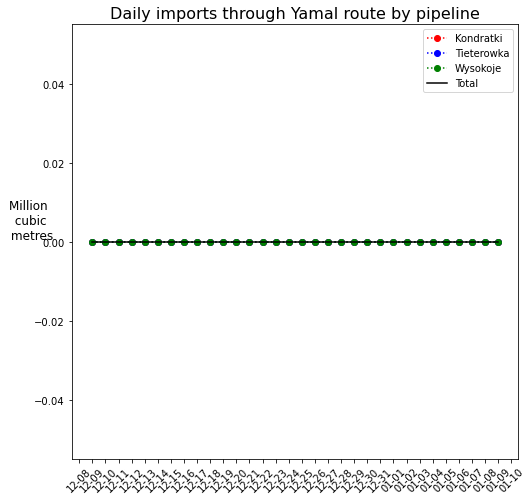

In [306]:
kond = df1[df1['label'] == 'Kondratki']
kondplot = kond['values'][startdate:]/converter

tit = df1[df1['label'] == 'Tieterowka']
titplot = tit['values'][startdate:]/converter

wys = df1[df1['label'] == 'Wysokoje']
wysplot = wys['values'][startdate:]/converter

## Code for figure

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(kondplot,color='red',label='Kondratki',linestyle=':',marker='o')
ax.plot(titplot,color='blue',label='Tieterowka',linestyle=':',marker='o')
ax.plot(wysplot,color='green',label='Wysokoje',linestyle=':',marker='o')
ax.plot(kondplot+titplot+wysplot,color='black',label='Total')

date_form1 = DateFormatter("%m-%d")
ax.xaxis.set_major_formatter(date_form1)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.xticks(rotation=45)
plt.title('Daily imports through Yamal route by pipeline',fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)
plt.legend(loc='best')

plt.show()
fig.savefig('figures/YamalDAILY.png'.format(route),dpi=300,bbox_inches="tight")

#### Ukraine Route 

In [117]:
startdate = '2023-03-01'

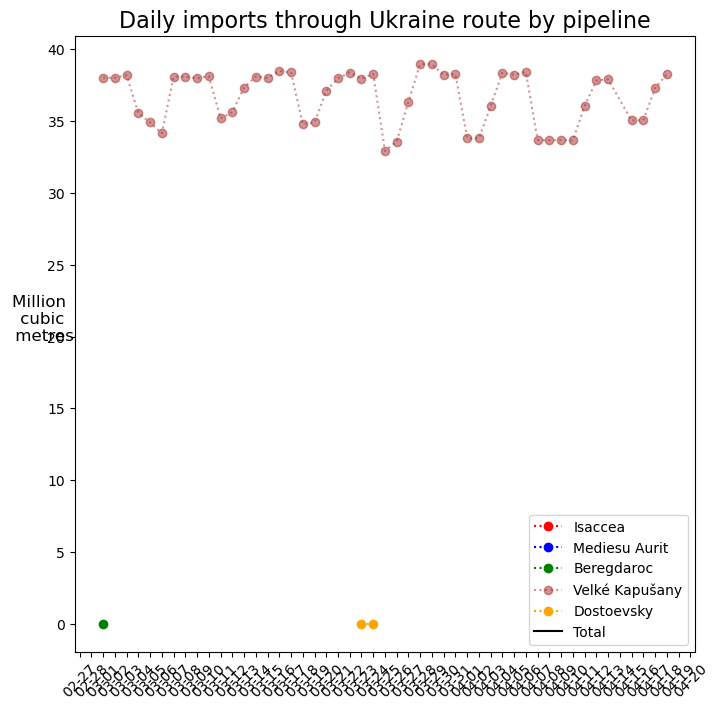

In [118]:
isac = df1[df1['label'] == 'Isaccea (RO) - Orlovka (UA) III']
isacplot = isac['values'][startdate:]/converter

med = df1[df1['label'] == 'VIP Mediesu Aurit - Isaccea (RO-UA)']
medplot = med['values'][startdate:]/converter

bereg = df1[df1['label'] == 'VIP Bereg (HU) / VIP Bereg (UA)']
beregplot = bereg['values'][startdate:]/converter

uzg = df1[df1['label'] == 'Uzhgorod (UA) - Velké Kapušany (SK)']
uzgplot = uzg['values'][startdate:]/converter

##Added on 1st Dec 2022
uzg2 = df1[df1['label'] == 'Uzhhorod (UA) - Velké Kapušany (SK)']
uzgplot2 = uzg2['values'][startdate:]/converter

##Added in on 18th November 2021
drz = df1[df1['label'] == 'GCP GAZ-SYSTEM/UA TSO']
drzplot = drz['values'][startdate:]/converter

## Code for figure

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(isacplot,color='red',label='Isaccea',linestyle=':',marker='o')
ax.plot(medplot,color='blue',label='Mediesu Aurit',linestyle=':',marker='o')
ax.plot(beregplot,color='green',label='Beregdaroc',linestyle=':',marker='o')
# ax.plot(uzgplot,color='brown',label='Velké Kapušany',linestyle=':',marker='o',alpha=0.5)
ax.plot(uzgplot2,color='brown',label='Velké Kapušany',linestyle=':',marker='o',alpha=0.5)
ax.plot(drzplot,color='orange',label='Dostoevsky',linestyle=':',marker='o')

ax.plot(uzgplot2+isacplot+medplot+beregplot+drzplot,color='black',label='Total',alpha=1) # uzgplot

date_form1 = DateFormatter("%m-%d")
ax.xaxis.set_major_formatter(date_form1)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.xticks(rotation=45)
plt.title('Daily imports through Ukraine route by pipeline',fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)
plt.legend(loc='best')

plt.show()
fig.savefig('figures/UkraineDAILY_18novupdate.png'.format(route),dpi=300,bbox_inches="tight")

#### Azerbaijan

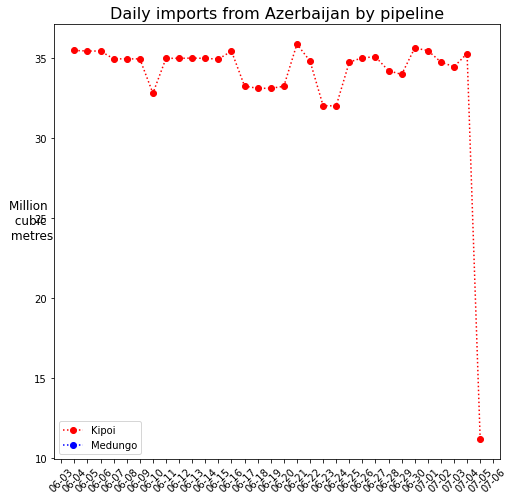

In [131]:
kip = df1[df1['label'] == 'Kipoi']
kipplot = kip['values'][startdate:]/converter

med = df1[df1['label'] == 'Melendugno - IT / TAP']
medplot = med['values'][startdate:]/converter

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(kipplot,color='red',label='Kipoi',linestyle=':',marker='o')
ax.plot(medplot,color='blue',label='Medungo',linestyle=':',marker='o')

date_form1 = DateFormatter("%m-%d")
ax.xaxis.set_major_formatter(date_form1)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.xticks(rotation=45)
plt.title('Daily imports from Azerbaijan by pipeline',fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)
plt.legend(loc='best')

plt.show()
#fig.savefig('figures/YamalDAILY.png'.format(route),dpi=300,bbox_inches="tight")

#### LNG

In [69]:
df1[df1['label']=='TVB']

,dates,values,direction,operator,location,label,country,exportcountry,aggregation,aggregation2,aggregation3
dates,,,,,,,,,,,
2020-04-01,2020-04-01,686500561.0,entry,ES-TSO-0006,VTP-00043,TVB,ES,Liquefied Natural Gas,LNG,Spain,LNG
2020-04-02,2020-04-02,665057607.0,entry,ES-TSO-0006,VTP-00043,TVB,ES,Liquefied Natural Gas,LNG,Spain,LNG
2020-04-03,2020-04-03,605847457.0,entry,ES-TSO-0006,VTP-00043,TVB,ES,Liquefied Natural Gas,LNG,Spain,LNG
2020-04-04,2020-04-04,596242183.0,entry,ES-TSO-0006,VTP-00043,TVB,ES,Liquefied Natural Gas,LNG,Spain,LNG
2020-04-05,2020-04-05,571005136.0,entry,ES-TSO-0006,VTP-00043,TVB,ES,Liquefied Natural Gas,LNG,Spain,LNG
...,...,...,...,...,...,...,...,...,...,...,...
2022-10-19,2022-10-19,304255017.0,entry,ES-TSO-0006,VTP-00043,TVB,ES,Liquefied Natural Gas,LNG,Spain,LNG
2022-10-20,2022-10-20,366011418.0,entry,ES-TSO-0006,VTP-00043,TVB,ES,Liquefied Natural Gas,LNG,Spain,LNG
2022-10-21,2022-10-21,633950529.0,entry,ES-TSO-0006,VTP-00043,TVB,ES,Liquefied Natural Gas,LNG,Spain,LNG


In [70]:
df1[df1['aggregation'] == 'LNG']['label'].unique()

array(['Fos (Tonkin/Cavaou)', 'Montoir de Bretagne', 'Zeebrugge LNG',
       'Gate Terminal (I)', 'Panigaglia', 'OLT LNG / Livorno',
       'Cavarzere (Porto Levante / Adriatic LNG)', 'Klaipeda (LNG)',
       'Revythoussa', 'Agia Triada', 'Teesside', 'Milford Haven',
       'Isle of Grain', 'Sines', 'Dunkerque LNG / PEG North',
       'Swinoujscie', 'TVB', 'Croatia LNG', 'Eems Energy Terminal',
       'Huelva', 'Cartagena', 'Sagunto', 'Barcelona', 'Bilbao'],
      dtype=object)

In [106]:
startdate = '2023-03-01'
enddate = date.today()

In [107]:
import matplotlib.dates as mdates

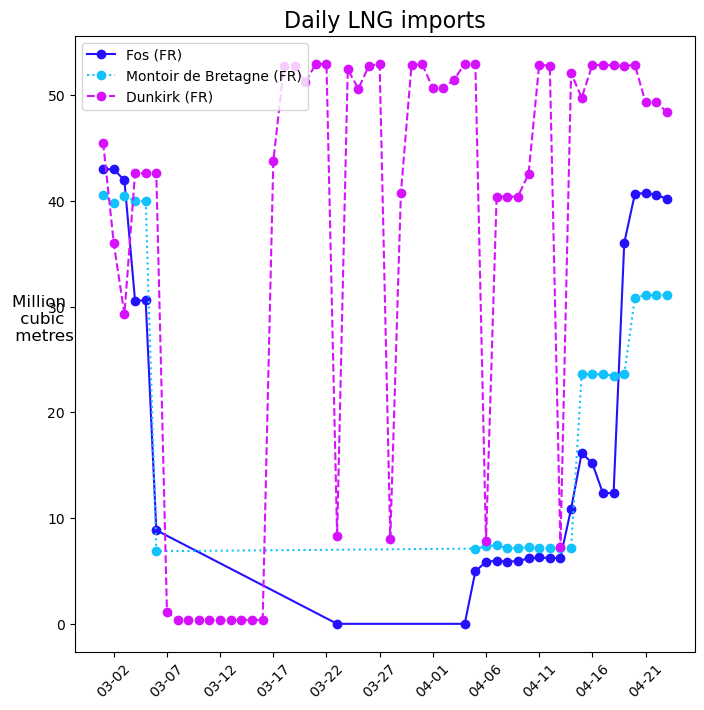

In [109]:
fos = df1[df1['label'] == 'Fos (Tonkin/Cavaou)']
fosplot = fos['values'][startdate:enddate]/converter

mont = df1[df1['label'] == 'Montoir de Bretagne']
montplot = mont['values'][startdate:enddate]/converter

zee = df1[df1['label'] == 'Zeebrugge LNG']
zeeplot = zee['values'][startdate:enddate]/converter

gate = df1[df1['label'] == 'Gate Terminal (I)']
gateplot = gate['values'][startdate:enddate]/converter

eems = df1[df1['label'] == 'Eems Energy Terminal']
eemsplot = eems['values'][startdate:enddate]/converter 

pan = df1[df1['label'] == 'Panigaglia']
panplot = pan['values'][startdate:enddate]/converter

liv = df1[df1['label'] == 'OLT LNG / Livorno']
livplot = liv['values'][startdate:enddate]/converter

adr = df1[df1['label'] == 'Cavarzere (Porto Levante / Adriatic LNG)']
adrplot = adr['values'][startdate:enddate]/converter

klp = df1[df1['label'] == 'Klaipeda (LNG)']
klpplot = klp['values'][startdate:enddate]/converter

rev = df1[df1['label'] == 'Revythoussa']
revplot = rev['values'][startdate:enddate]/converter

agi = df1[df1['label'] == 'Agia Triada']
agiplot = agi['values'][startdate:enddate]/converter

tee = df1[df1['label'] == 'Teesside']
teeplot = tee['values'][startdate:enddate]/converter

mhn = df1[df1['label'] == 'Milford Haven']
mhnplot = mhn['values'][startdate:enddate]/converter

igr = df1[df1['label'] == 'Isle of Grain']
igrplot = igr['values'][startdate:enddate]/converter

sin = df1[df1['label'] == 'Sines']
sinplot = sin['values'][startdate:enddate]/converter

dkr = df1[df1['label'] == 'Dunkerque LNG / PEG North']
dkrplot = dkr['values'][startdate:enddate]/converter

swi = df1[df1['label'] == 'Swinoujscie']
swiplot = swi['values'][startdate:enddate]/converter

tvb = df1[df1['label'] == 'TVB']
tvbplot = tvb['values'][startdate:enddate]/converter

hr = df1[df1['label'] == 'Croatia LNG']
hrplot = hr['values'][startdate:enddate]/converter

hm = df1[df1['label'] == 'Hamina LNG']
hmplot = hm['values'][startdate:enddate]/converter

bruns = df1[df1['label'] == 'BRUNSBUETTEL HAFEN (FSRU) (DE)']
brunsplot = bruns['values'][startdate:enddate]/converter

baltic = df1[df1['label'] == 'Baltic Energy Gate (Port) (DE)'] 
balticplot = baltic['values'][startdate:enddate]/converter

wh = df1[df1['label'] == 'Wilhelmshaven, LNG-Terminal 1 (DE)'] 
whplot = wh['values'][startdate:enddate]/converter

lngtot=fosplot+montplot+zeeplot+gateplot+panplot+livplot+adrplot+klpplot+agiplot+teeplot+mhnplot+igrplot+sinplot+dkrplot+swiplot+tvbplot+hrplot+hmplot+brunsplot+balticplot+whplot

## Code for figure

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(fosplot,color='#2411FD',label='Fos (FR)',linestyle='-',marker='o')
ax.plot(montplot,color='#11c2fd',label='Montoir de Bretagne (FR)',linestyle=':',marker='o')
ax.plot(dkrplot,color='#d611fd',label='Dunkirk (FR)',linestyle='--',marker='o')

# ax.plot(tvbplot,color='#8E0202',label='Spanish LNG (ES)',linestyle=':',marker='o')

# ax.plot(panplot,color='#0097FF',label='Panigaglia (IT)',linestyle='-',marker='o')
# ax.plot(livplot,color='#0097FF',label='Livorno (IT)',linestyle='--',marker='o')
# ax.plot(adrplot,color='#0097FF',label='Porto Levante (IT)',linestyle=':',marker='o')

# # ax.plot(teeplot,color='#FF1B1B',label='Teesside (UK)',linestyle=':',marker='o')
# # ax.plot(mhnplot,color='#FF1B1B',label='Milford Haven (UK)',linestyle='-',marker='o')
# # ax.plot(igrplot,color='#FF1B1B',label='Isle of Grain (UK)',linestyle='--',marker='o',alpha=0.5)

# ax.plot(zeeplot,color='#FFE402',label='Zeebrugge (BE)',linestyle=':',marker='o')
# ax.plot(gateplot,color='#FFA302',label='Gate Terminal (NL)',linestyle=':',marker='o',alpha=0.5)
# ax.plot(eemsplot,color='#4f34eb',label='EEMS Energy Terminal (NL)',linestyle=':',marker='o',alpha=0.5)
# ax.plot(klpplot,color='#FF0288',label='Klaipeda (LI)',linestyle=':',marker='o')
# ax.plot(revplot,color='black',label='Revythoussa',linestyle=':',marker='o',alpha=0.5)
# ax.plot(agiplot,color='#02FF34',label='Agia Triada (GR)',linestyle=':',marker='o')
# ax.plot(sinplot,color='#03896A',label='Sines (PT)',linestyle=':',marker='o')
# ax.plot(swiplot,color='#6704F7',label='Swinoujscie (PL)',linestyle=':',marker='o',alpha=0.5)

# ax.plot(hrplot,color='green',label='Croatia LNG',linestyle=':',marker='o')

# ax.plot(hmplot,label='Hamina LNG',linestyle=':',marker='o')
# ax.plot(brunsplot,color='#fd2511',label='Brunsbuettel FSRU (DE)',linestyle=':',marker='o')
# ax.plot(balticplot,color='#fdde11',label='Baltic Energy Gate (DE)',linestyle=':',marker='o')
# ax.plot(whplot,color='#50fd11',label='Wilhelmshaven - terminal 1',linestyle=':',marker='o')
# tot_de = brunsplot+balticplot+whplot
# ax.plot(tot_de,color='black',label='Total DE',alpha=1)
#ax.plot(lngtot,color='black',label='Total',alpha=1)

date_form1 = DateFormatter("%m-%d")
ax.xaxis.set_major_formatter(date_form1)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.xticks(rotation=45)

plt.title('Daily LNG imports',fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)
plt.legend(loc='upper left')

plt.show()
#fig.savefig('figures/UkraineDAILY_18novupdate.png'.format(route),dpi=300,bbox_inches="tight")

#### Read in LNG Capacities 

In [28]:
lng_capacities=pd.read_excel(r"{}\working_data\NGcapacities.xlsx".format(Share_point),sheet_name='lng_capacities')
#Read in LNG capacities downloaded from ENTSO-G. #Daily?

In [29]:
lng_capacities = lng_capacities[lng_capacities['region']!='ignore'] #dropping the UK numbers
lng_cap = lng_capacities[['country','entsog_gwhpd']].groupby(by='country').sum(numeric_only=True) #groupby each country 

In [30]:
lngdict = {'belgium':'BE','croatia':'HR','france':'FR','greece':'GR','italy':'IT','lithuania':'LT','netherlands':'NL',
          'poland':'PL','portugal':'PT','spain':'ES'}
lng_cap['twodigit'] = lng_cap.index.map(lngdict)

#### LNG Utilisation for Time Period below

In [39]:
df_lng = df1[df1['label'].isin(['Fos (Tonkin/Cavaou)', 'Montoir de Bretagne', 'Zeebrugge LNG',
       'Gate Terminal (I)', 'Eems Energy Terminal', 'Panigaglia', 'OLT LNG / Livorno',
       'Cavarzere (Porto Levante / Adriatic LNG)', 'Klaipeda (LNG)',
       'Agia Triada', 'Sines', 'Dunkerque LNG / PEG North', 'Swinoujscie',
       'TVB', 'Croatia LNG','Teesside (UK)','Milford Haven (UK)','Isle of Grain (UK)'])] #CHECK if UK dropped or not. 

In [57]:
lng2021 = df_lng.loc['2021-01-01':'2021-10-23'].groupby('country').sum(numeric_only=True)
lng2021['valuesTWh_2021'] = lng2021['values']*kwhtwh

lng2022 = df_lng.loc['2022-01-01':'2022-10-23'].groupby('country').sum(numeric_only=True)
lng2022['valuesTWh_2022'] = lng2022['values']*kwhtwh

In [58]:
lng_cap

,entsog_gwhpd,twodigit
country,,
belgium,461.0,BE
croatia,85.0,HR
france,1295.0,FR
greece,224.0,GR
italy,562.0,IT
lithuania,122.0,LT
netherlands,864.0,NL
poland,227.0,PL
portugal,200.0,PT


In [59]:
lngmerge = lng_cap.merge(lng2021,left_on=lng_cap['twodigit'],right_on=lng2021.index,how='outer')
del lngmerge['key_0']
lngmerge1 = lngmerge.merge(lng2022,left_on=lngmerge['twodigit'],right_on=lng2022.index,how='outer')

In [61]:
date_format = "%Y-%m-%d"

Ld1 = '2022-01-01'
Ld2 = '2022-10-23'

lngstart = datetime.strptime(Ld1,date_format)
lngend = datetime.strptime(Ld2,date_format)
n = (lngend-lngstart).days
(lngend-lngstart).days

295

In [62]:
lng_ratios = lngmerge1[['twodigit','entsog_gwhpd','valuesTWh_2021','valuesTWh_2022']]

In [63]:
## Change the number of days
lng_ratios['ToDate_cap'] = (lng_ratios['entsog_gwhpd']*n)/1000

C:\Users\GIOVAN~1.SGA\AppData\Local\Temp/ipykernel_28136/3745277605.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lng_ratios['ToDate_cap'] = (lng_ratios['entsog_gwhpd']*n)/1000


In [64]:
lng_ratios

,twodigit,entsog_gwhpd,valuesTWh_2021,valuesTWh_2022,ToDate_cap
0,BE,461.0,36.444380,94.351305,135.995
1,HR,85.0,NaN,20.979611,25.075
2,FR,1295.0,143.562155,288.900034,382.025
3,GR,224.0,19.525702,23.499290,66.080
4,IT,562.0,88.902957,116.739459,165.790
5,LT,122.0,14.228631,24.265315,35.990
6,NL,864.0,61.878335,138.846321,254.880
7,PL,227.0,31.321606,49.327363,66.965
8,PT,200.0,49.326230,50.409751,59.000
9,ES,1911.0,137.620055,206.638332,563.745


In [65]:
lng_ratios['2021_utilisation'] = (lng_ratios['valuesTWh_2021'] / lng_ratios['ToDate_cap'])*100
lng_ratios['2022_utilisation'] = (lng_ratios['valuesTWh_2022'] / lng_ratios['ToDate_cap'])*100
lng_ratios['background'] = 100

C:\Users\GIOVAN~1.SGA\AppData\Local\Temp/ipykernel_28136/3544717460.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lng_ratios['2021_utilisation'] = (lng_ratios['valuesTWh_2021'] / lng_ratios['ToDate_cap'])*100


In [66]:
lng_ratios.sort_values('2022_utilisation',inplace=True,ascending=False)

In [67]:
lngmerge['cap_gwh'] = lngmerge['entsog_gwhpd']*n ## Change for the numbers of days?
lngmerge['cap_twh'] = lngmerge['cap_gwh']/1000

In [68]:
Share_point_data

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\Imports'

In [69]:
lngmerge.to_csv(r"{}\LNG_Oct2022_capacities.csv'".format(Share_point_data))

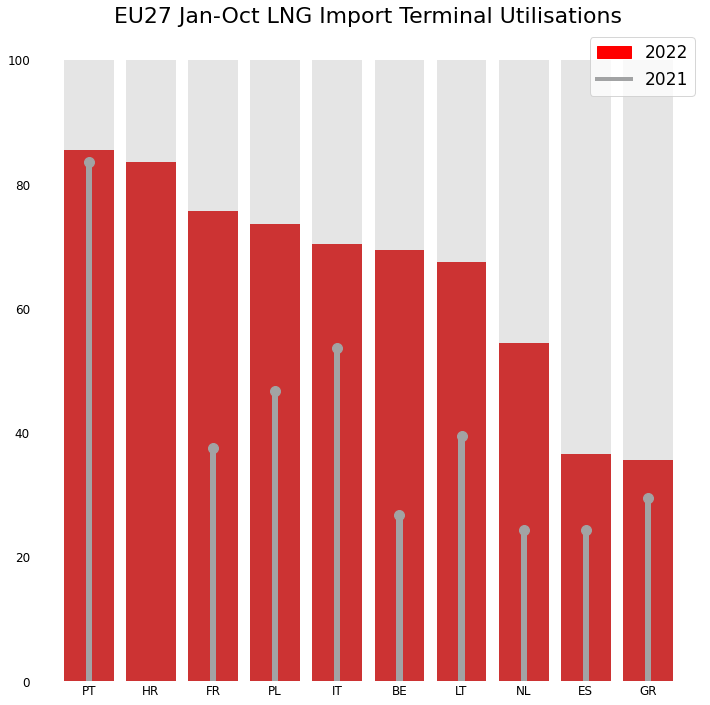

In [71]:
fig, ax = plt.subplots(figsize=(12, 12))

sns.barplot(x="twodigit", y="2022_utilisation", data=lng_ratios, color='red',alpha=1)
sns.barplot(x="twodigit", y="background", data=lng_ratios, color="grey",alpha=0.2)

ax.plot(lng_ratios['twodigit'],lng_ratios['2021_utilisation'],'o',markersize=10,color='#A2A3A4')
ax.bar(lng_ratios['twodigit'],lng_ratios['2021_utilisation'],color='#A2A3A4',width=0.1)

ax.xaxis.tick_bottom()

#ax.set_ylabel("Utilisation of \n max technical \n physical capacity",rotation=0,fontsize=12,labelpad=50)
ax.set_ylabel("")
ax.set_title('EU27 Jan-Oct LNG Import Terminal Utilisations',fontsize=22)

#ax1.yaxis.set_label_coords(-0.10, 0.3)
#ax2.yaxis.set_label_coords(-0.10, 0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xlabel("")
ax.tick_params(axis=u'both', which=u'both',length=0,labelsize=12)

legend_elements = [Patch(facecolor='red', edgecolor='r',
                         label='2022'),
                    Line2D([0], [0], color='#A2A3A4', lw=4, label='2021')]
ax.legend(handles=legend_elements, loc='upper right',fontsize=17)
    
#plt.savefig('LNGutilisation_Q1.png',dpi=400,bbox_inches='tight')
plt.savefig('LNG_Oct_utilisation.png',dpi=400,bbox_inches='tight',facecolor='white', transparent=False)

In [72]:
lngmerge['cap_annual'] = (lngmerge['entsog_gwhpd']*365)/1000

In [73]:
lngmerge.sort_values(by='cap_annual')

,entsog_gwhpd,twodigit,values,valuesTWh_2021,cap_gwh,cap_twh,cap_annual
1,85.0,HR,NaN,NaN,25075.0,25.075,31.025
5,122.0,LT,1.422863e+10,14.228631,35990.0,35.990,44.530
8,200.0,PT,4.932623e+10,49.326230,59000.0,59.000,73.000
3,224.0,GR,1.952570e+10,19.525702,66080.0,66.080,81.760
7,227.0,PL,3.132161e+10,31.321606,66965.0,66.965,82.855
0,461.0,BE,3.644438e+10,36.444380,135995.0,135.995,168.265
4,562.0,IT,8.890296e+10,88.902957,165790.0,165.790,205.130
6,864.0,NL,6.187833e+10,61.878335,254880.0,254.880,315.360
2,1295.0,FR,1.435622e+11,143.562155,382025.0,382.025,472.675
9,1911.0,ES,1.376201e+11,137.620055,563745.0,563.745,697.515


In [37]:
lngpoints.to_excel('lngpoints_ctry.xlsx')

In [40]:
(290.8074*1000000000)/converter

28233.728155339806

In [39]:
df1['label'].unique()

array(['Huelva', 'Cartagena', 'Sagunto', 'Barcelona', 'Bilbao',
       'Fos (Tonkin/Cavaou)', 'Montoir de Bretagne', 'Zeebrugge LNG',
       'Gate Terminal (I)', 'Panigaglia', 'OLT LNG / Livorno',
       'Cavarzere (Porto Levante / Adriatic LNG)', 'Klaipeda (LNG)',
       'Revythoussa', 'Agia Triada', 'Teesside', 'Milford Haven',
       'Isle of Grain', 'Tarifa', 'Almería', 'Mazara del Vallo', 'Gela',
       'Isaccea (RO) - Orlovka (UA) III',
       'VIP Mediesu Aurit - Isaccea (RO-UA)',
       'Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)',
       'Uzhgorod (UA) - Velké Kapušany (SK)', 'Budince', 'Wysokoje',
       'Kondratki', 'Tieterowka', 'Kotlovka', 'Misso Izborsk', 'Luhamaa',
       'Värska', 'Narva', 'St. Fergus', 'Easington', 'Dunkerque',
       'Zeebrugge ZPT', 'Emden (NPT) (GTS)', 'Emden (EPT1) (OGE)',
       'Emden (EPT1) (Thyssengas)', 'Greifswald / OPAL',
       'Greifswald / NEL', 'Nybro', 'Sines', 'Dunkerque LNG / PEG North',
       'Swinoujscie', 'Dornum GASPOOL', 'Kipo

In [48]:
df1[df1['label'] == 'VIP Bereg (HU) / VIP Bereg (UA)'].loc['2018-02-21':'2018-02-25'].groupby(pd.Grouper(freq='D')).sum(numeric_only=True)/converter

,values
dates,


# Original Quality Control

In [43]:
df1[df1['label'] == 'Isaccea (RO) - Orlovka (UA) III'].loc['2018-02-21':'2018-02-25']

,dates,values,direction,operator,location,label,country,IEAname,exportcountry,aggregation,aggregation2
dates,,,,,,,,,,,
2018-02-21,2018-02-21,315087975.4,entry,RO-TSO-0001,ITP-00300,Isaccea (RO) - Orlovka (UA) III,RO,Isaccea,Ukraine,Russia,Ukraine Gas Transit
2018-02-22,2018-02-22,301511695.4,entry,RO-TSO-0001,ITP-00300,Isaccea (RO) - Orlovka (UA) III,RO,Isaccea,Ukraine,Russia,Ukraine Gas Transit
2018-02-23,2018-02-23,308835753.4,entry,RO-TSO-0001,ITP-00300,Isaccea (RO) - Orlovka (UA) III,RO,Isaccea,Ukraine,Russia,Ukraine Gas Transit
2018-02-24,2018-02-24,312783275.6,entry,RO-TSO-0001,ITP-00300,Isaccea (RO) - Orlovka (UA) III,RO,Isaccea,Ukraine,Russia,Ukraine Gas Transit
2018-02-25,2018-02-25,308268284.2,entry,RO-TSO-0001,ITP-00300,Isaccea (RO) - Orlovka (UA) III,RO,Isaccea,Ukraine,Russia,Ukraine Gas Transit


In [24]:
noUK = df1[df1['country']!='UK']

## Weekly Historic Dataset

#### LNG

In [20]:
df1[df1['aggregation'] == 'Norway']['label'].unique()

array(['St. Fergus', 'Easington', 'Dunkerque', 'Zeebrugge ZPT',
       'Emden (NPT) (GTS)', 'Emden (EPT1) (GTS)', 'Emden (EPT1) (OGE)',
       'Emden (EPT1) (Thyssengas)', 'Nybro', 'Dornum GASPOOL',
       'Dornum / NETRA (jordgas Transport)'], dtype=object)

In [21]:
df_lng = df1[df1['aggregation'] == 'LNG'].loc['2019':]

In [25]:
lng_pivot = df_lng.pivot_table(values='values',index=df_lng.index,columns='aggregation2')

In [31]:
lng_pivot.to_csv('LNGdata_joseph.csv')

In [28]:
lng_pivot.groupby(pd.Grouper(freq='D')).sum(numeric_only=True)

aggregation2,Belgium,Croatia,France,Greece,Italy,Lithuania,Netherlands,Poland,Portugal,Spain,UK
dates,,,,,,,,,,,
2019-01-06,1.196816e+09,0.0,9.183258e+08,710702429.0,6.003010e+08,16073444.0,1.657299e+09,5.675815e+08,9.198304e+08,4.930701e+08,1.559720e+09
2019-01-13,1.412295e+09,0.0,1.455108e+09,770501245.0,7.682612e+08,26243298.0,2.010777e+09,6.989391e+08,1.279070e+09,6.381214e+08,1.644578e+09
2019-01-20,9.641452e+08,0.0,1.138791e+09,721749955.0,7.555210e+08,16100200.0,1.304505e+09,7.647129e+08,1.341425e+09,6.515865e+08,1.663560e+09
2019-01-27,5.941604e+08,0.0,1.122781e+09,599154161.0,9.015022e+08,16318696.0,1.562159e+09,8.645324e+08,1.275942e+09,5.850861e+08,1.815157e+09
2019-02-03,1.277578e+09,0.0,1.042228e+09,551671969.0,8.628817e+08,7115215.0,1.291803e+09,8.635079e+08,1.116879e+09,5.992158e+08,1.879430e+09
...,...,...,...,...,...,...,...,...,...,...,...
2022-05-29,1.694043e+09,527896509.0,2.390717e+09,989541415.0,9.346791e+08,802931288.0,3.170971e+09,1.481081e+09,1.322932e+09,4.771225e+09,2.037021e+09
2022-06-05,2.524848e+09,571867495.0,1.844334e+09,833411818.0,9.881441e+08,800526708.0,3.146228e+09,1.508636e+09,1.366215e+09,5.320483e+09,1.774187e+09
2022-06-12,2.691141e+09,567591057.0,1.134758e+09,712796635.0,1.231722e+09,807164998.0,3.188074e+09,1.543613e+09,1.342580e+09,5.062191e+09,1.605838e+09


In [36]:
lng_pivot

label,Agia Triada,Cavarzere (Porto Levante / Adriatic LNG),Croatia LNG,Dunkerque LNG / PEG North,Fos (Tonkin/Cavaou),Gate Terminal (I),Isle of Grain,Klaipeda (LNG),Milford Haven,Montoir de Bretagne,OLT LNG / Livorno,Panigaglia,Sines,Swinoujscie,TVB,Teesside,Zeebrugge LNG
dates,,,,,,,,,,,,,,,,,
2022-01-01,8.649385,10.647644,4.290214,33.054438,31.904696,34.158212,21.488221,1.847965,43.609424,27.080685,0.000000,0.006876,9.462417,13.443608,47.007228,30.383133,14.070683
2022-01-02,7.021665,10.652872,4.257912,36.577677,31.820475,34.145084,20.230634,1.837739,41.712507,27.068687,0.000000,0.020695,11.512250,10.016882,60.920540,30.355323,18.921837
2022-01-03,10.044289,17.046496,4.284463,27.707853,31.813826,34.159225,26.933743,2.743157,44.748858,27.070903,0.000000,0.013182,16.808821,17.192127,74.490033,29.896193,19.964826
2022-01-04,13.710926,18.231539,4.121929,36.589926,36.753996,35.876832,43.220273,1.652712,63.296518,26.533554,0.000000,0.017832,17.076570,16.977589,65.837554,28.746785,19.126971
2022-01-05,14.329688,19.184370,4.783753,42.580998,36.762453,37.868737,45.212853,1.571825,65.389317,26.513554,3.034240,0.007113,18.485285,15.817908,79.316811,29.285138,16.632098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-06-20,11.618619,27.277374,7.043405,34.069803,7.779055,47.207767,0.000000,11.383344,42.587307,0.029270,14.136262,11.841930,17.976714,17.246065,79.249187,25.727270,41.377134
2022-06-21,20.256336,27.216414,5.078354,47.199646,22.560231,43.677913,0.000000,11.305594,44.673458,0.043171,14.139358,10.942162,20.405036,21.076152,77.981285,25.045259,41.349896
2022-06-22,20.159114,27.214711,6.377978,11.645269,22.567680,45.603398,0.669636,11.210872,41.387596,0.000000,14.136536,11.500639,20.008343,21.217486,91.410680,22.466987,46.494568


#### All flows

#### Get rid of UK

In [21]:
df_EU27 = df1[df1['country'] != 'UK']

##### Useful

In [22]:
converter

NameError: name 'converter' is not defined

In [37]:
## Change the Grouper for the time --> weekly, monthly, yearly 
df2 = df_EU27.pivot_table(values='values',index=df_EU27.index,columns='aggregation3',aggfunc='sum').groupby(pd.Grouper(freq='Q')).sum(numeric_only=True)/1000000000

In [38]:
df2['Russia'] = df2['Nord Stream'] + df2['Russia Other'] + df2['Turkstream'] + df2['Ukraine Transit'] + df2['Yamal']
df2['Total'] = df2['Algeria'] + df2['Azerbaijan'] + df2['LNG'] + df2['Libya'] + df2['Norway'] + df2['Russia']

In [39]:
# df2 = df2['2020-12-28':]/10.3

In [40]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - European natural gas imports\\Code\\Imports'

In [41]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - European natural gas imports\\Code\\Imports'

In [42]:
df2.to_csv('EU27 imports {}.csv'.format(today))

In [62]:
df2['Russia']/df2['Total']

dates
2022-02-06    0.305603
2022-02-13    0.287744
2022-02-20    0.285960
2022-02-27    0.325990
2022-03-06    0.347957
2022-03-13    0.335454
2022-03-20    0.306410
2022-03-27    0.315685
2022-04-03    0.327756
2022-04-10    0.302442
2022-04-17    0.283859
2022-04-24    0.267666
2022-05-01    0.252753
2022-05-08    0.297095
2022-05-15    0.275794
2022-05-22    0.256183
2022-05-29    0.244831
2022-06-05    0.238941
2022-06-12    0.240966
2022-06-19    0.178524
2022-06-26    0.142549
2022-07-03    0.172731
2022-07-10    0.169810
2022-07-17    0.100638
2022-07-24    0.148564
2022-07-31    0.154109
2022-08-07    0.140969
2022-08-14    0.147712
2022-08-21    0.209875
Freq: W-SUN, dtype: float64

In [25]:
df2['Russia']

dates
2015-12-31    1376.782072
2016-12-31    1686.762427
2017-12-31    1899.867278
2018-12-31    1939.195178
2019-12-31    1928.591002
2020-12-31    1583.148047
2021-12-31    1553.732271
2022-12-31     563.404595
Freq: A-DEC, Name: Russia, dtype: float64

In [26]:
df2['Russia']

dates
2015-12-31    1376.782072
2016-12-31    1686.762427
2017-12-31    1899.867278
2018-12-31    1939.195178
2019-12-31    1928.591002
2020-12-31    1583.148047
2021-12-31    1553.732271
2022-12-31     563.404595
Freq: A-DEC, Name: Russia, dtype: float64

In [91]:
629-392

237

In [88]:
828-522

306

In [90]:
df2.loc['2022-01':'2022-06'][['LNG','Russia','Total']].sum(numeric_only=True)

aggregation3
LNG        629.443527
Russia     521.879373
Total     1885.211334
dtype: float64

In [198]:
df1[df1['aggregation'] == 'Russia']['label'].unique()

array(['Isaccea (RO) - Orlovka (UA) III',
       'VIP Mediesu Aurit - Isaccea (RO-UA)',
       'Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)',
       'Uzhgorod (UA) - Velké Kapušany (SK)', 'Budince', 'Wysokoje',
       'Kondratki', 'Tieterowka', 'Kotlovka', 'Misso Izborsk', 'Luhamaa',
       'Värska', 'Narva', 'Greifswald / OPAL', 'Greifswald / NEL',
       'Isaccea (RO) - Orlovka (UA) I', 'Isaccea (RO) - Orlovka (UA) II',
       'Strandzha 2 (BG) / Malkoclar (TR)', 'Ungheni',
       'VIP Bereg (HU) / VIP Bereg (UA)', 'GCP GAZ-SYSTEM/UA TSO',
       'Imatra'], dtype=object)

In [257]:
df1[df1['aggregation'] == 'Russia'].loc['2021-01-01':'2021-03-31']['values'].sum(numeric_only=True)/1000000000

408.2555431433402

In [211]:
plotme = df1[df1['label'].isin(['Isaccea (RO) - Orlovka (UA) I', 'Isaccea (RO) - Orlovka (UA) II',
                      'Isaccea (RO) - Orlovka (UA) III',
                       'VIP Mediesu Aurit - Isaccea (RO-UA)'])].loc['2015':'2020']['values'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)/converter

<AxesSubplot:xlabel='dates'>

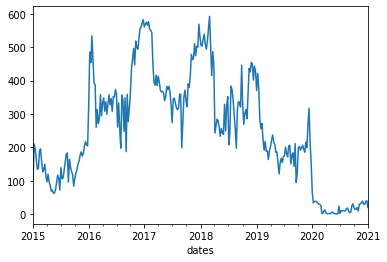

In [212]:
plotme.plot()

In [603]:
df2.to_csv('TotalWeeklyFlows_EU27.csv')

In [34]:
df2['month'] = df2.index.month

In [35]:
df2 = df2['2018':]

In [36]:
df2.to_excel(r'C:/Users/ben.mcwilliams/Documents/noRussianGas/longterm/daily_flows.xlsx')

In [65]:
import seaborn as sns
plt.style.use("seaborn")
sns.set_style("white")

In [66]:
df2 = df2['2018':]

In [67]:
df2.columns

Index(['Belgium', 'Croatia', 'France', 'Greece', 'Italy', 'Lithuania',
       'Netherlands', 'Nord Stream', 'Poland', 'Portugal', 'Spain',
       'Turkstream', 'UK', 'Ukraine Gas Transit', 'Yamal (BY,PL)', 'ignore',
       'other', 'week'],
      dtype='object', name='aggregation2')

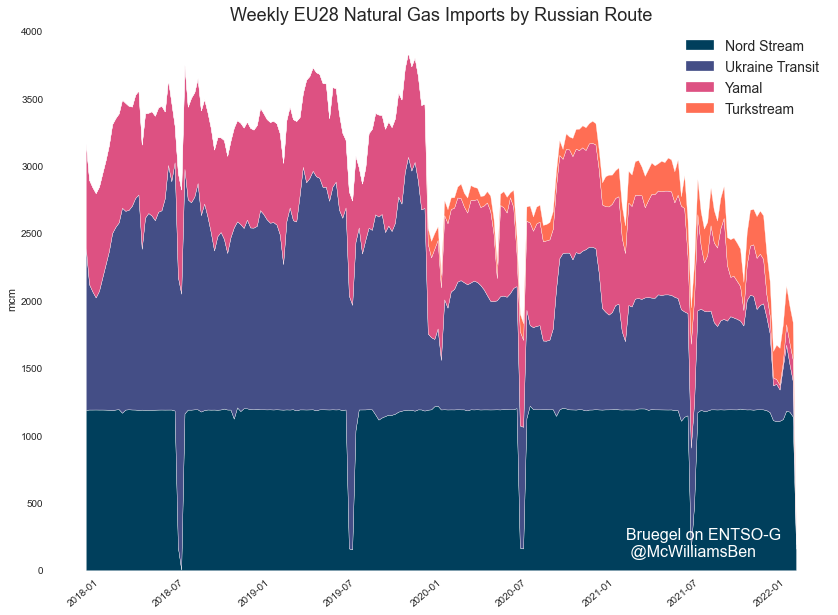

In [96]:
colors = ['#003f5c','#444e86','#955196','#dd5182','#ff6e54','#ffa600']

colors = sns.color_palette("Spectral", 4).as_hex()

colors = ['#003f5c','#444e86','#dd5182','#ff6e54']


plt.figure(figsize=(14,10))
plt.stackplot(df2.index,df2['Nord Stream'],df2['Ukraine Gas Transit'],df2['Yamal (BY,PL)'],df2['Turkstream'],
             labels=['Nord Stream','Ukraine Transit','Yamal','Turkstream'],
             colors=colors)

plt.xticks(rotation=40)
plt.title('Weekly EU28 Natural Gas Imports by Russian Route',fontsize=18)
plt.ylabel('mcm')
plt.legend(fontsize=14)
plt.text(datetime(year=2021,month=3,day=1),100,'Bruegel on ENTSO-G \n @McWilliamsBen',fontsize=16,color='white')
plt.savefig('WeeklyImportsRussia.png',dpi=300)

In [59]:
df2.to_csv('weekly_historic_data.csv')

In [48]:
## Ukraine Transit
d1 = '2020-01-01'
d2 = '2022-05-10'

suzha = 'https://transparency.entsog.eu/api/v1/operationalData?forceDownload=true&pointDirection=ru-tso-0001itp-00184exit,ua-tso-0001itp-00184entry&from={}&to={}&indicator=Physical%20Flow&periodType=day&timezone=CET&limit=-1&dataset=1&directDownload=true'.format(d1,d2)
sohv = 'https://transparency.entsog.eu/api/v1/operationalData?forceDownload=true&pointDirection=ru-tso-0001itp-00183exit,ua-tso-0001itp-00183entry&from={}&to={}&indicator=Physical%20Flow&periodType=day&timezone=CET&limit=-1&dataset=1&directDownload=true'.format(d1,d2)
ukrainetransit = [suzha,sohv]

In [49]:
dates = []
values = []
direction = []
operator = []
point = []
labels = []

urls = []
ids = []

for url in ukrainetransit:
    print(idt)
    try:
        r = requests.get(url)
        data = r.json()
        op = data['operationalData']

        for item in op:
            date = item['periodFrom'][:10]
            value = item['value']
            drc = item['directionKey']
            opr = item['operatorKey']
            pt = item['pointKey']
            label = item['pointLabel']

            dates.append(date)
            values.append(value)
            direction.append(drc)
            operator.append(opr)
            point.append(pt)
            labels.append(label)
            urls.append(url)
            ids.append(idt)
            
    except Exception as e:
        print(e)
        print(idt)  

ua-tso-0001itp-00299exit,ro-tso-0001itp-00299entry
ua-tso-0001itp-00299exit,ro-tso-0001itp-00299entry


In [51]:
dates

['2020-01-01',
 '2020-01-02',
 '2020-01-03',
 '2020-01-04',
 '2020-01-05',
 '2020-01-06',
 '2020-01-07',
 '2020-01-08',
 '2020-01-09',
 '2020-01-10',
 '2020-01-11',
 '2020-01-12',
 '2020-01-13',
 '2020-01-14',
 '2020-01-15',
 '2020-01-16',
 '2020-01-17',
 '2020-01-18',
 '2020-01-19',
 '2020-01-20',
 '2020-01-21',
 '2020-01-22',
 '2020-01-23',
 '2020-01-24',
 '2020-01-25',
 '2020-01-26',
 '2020-01-27',
 '2020-01-28',
 '2020-01-29',
 '2020-01-30',
 '2020-01-31',
 '2020-02-01',
 '2020-02-02',
 '2020-02-03',
 '2020-02-04',
 '2020-02-05',
 '2020-02-06',
 '2020-02-07',
 '2020-02-08',
 '2020-02-09',
 '2020-02-10',
 '2020-02-11',
 '2020-02-12',
 '2020-02-13',
 '2020-02-14',
 '2020-02-15',
 '2020-02-16',
 '2020-02-17',
 '2020-02-18',
 '2020-02-19',
 '2020-02-20',
 '2020-02-21',
 '2020-02-22',
 '2020-02-23',
 '2020-02-24',
 '2020-02-25',
 '2020-02-26',
 '2020-02-27',
 '2020-02-28',
 '2020-02-29',
 '2020-03-01',
 '2020-03-02',
 '2020-03-03',
 '2020-03-04',
 '2020-03-05',
 '2020-03-06',
 '2020-03-

In [52]:
udf = pd.DataFrame()
udf['dates'] = dates
udf['values'] = values
udf['direction'] = direction
udf['operator'] = operator
udf['location'] = point
udf['label'] = labels

In [57]:
udf = udf.set_index(pd.DatetimeIndex(udf['dates']))
udf['label'].unique()

array(['Sudzha (RU) / Ukraine (UA)', 'Sokhranovka (RU) / Ukraine (UA)'],
      dtype=object)

In [59]:
sudz

,values
dates,


In [72]:
sohvplot['2022-04']

dates
2022-04-30    9.38085
Freq: M, Name: values, dtype: float64

In [75]:
sudzplot['2022-04']

dates
2022-04-30    14.766696
Freq: M, Name: values, dtype: float64

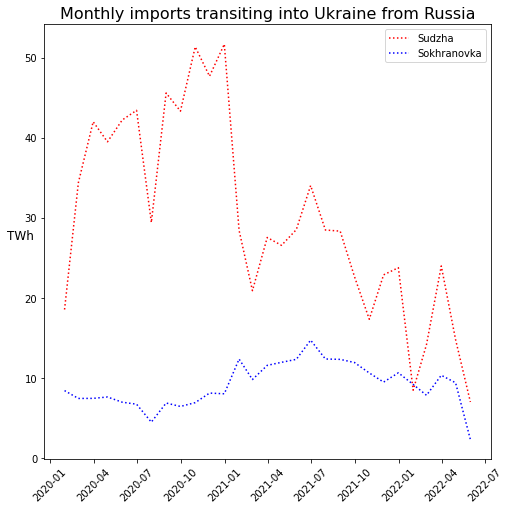

In [74]:
sudz = udf[udf['label'] == 'Sudzha (RU) / Ukraine (UA)'].groupby(pd.Grouper(freq='M')).sum(numeric_only=True)
sudzplot = sudz['values']/1000000000

sohv = udf[udf['label'] == 'Sokhranovka (RU) / Ukraine (UA)'].groupby(pd.Grouper(freq='M')).sum(numeric_only=True)
sohvplot = sohv['values']/1000000000

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(sudzplot,color='red',label='Sudzha',linestyle=':')
ax.plot(sohvplot,color='blue',label='Sokhranovka',linestyle=':')

plt.xticks(rotation=45)
plt.title('Monthly imports transiting into Ukraine from Russia',fontsize='16')
plt.ylabel('TWh',fontsize=12,rotation=0)
plt.legend(loc='best')

## 2021 Usage 

In [27]:
noUK[noUK['aggregation'] == 'LNG'].loc['2022-01-01':'2022-01-24']['values'].sum(numeric_only=True)/1000000000

80.0020251318

In [252]:
belgium = df1[df1['label'] == 'Zeebrugge LNG']['2021']['values'].sum(numeric_only=True)/1000000000
france = df1[df1['label'].isin(['Montoir de Bretagne','Fos (Tonkin/Cavaou)','Dunkerque LNG / PEG North'])].loc['2021']['values'].sum(numeric_only=True)/1000000000
italy = df1[df1['label'].isin(['Panigaglia','OLT LNG / Livorno','Cavarzere (Porto Levante / Adriatic LNG)'])].loc['2021']['values'].sum(numeric_only=True)/1000000000
spain = df1[df1['label'] == 'TVB']['2021']['values'].sum(numeric_only=True)/1000000000
greece = df1[df1['label'] == 'Agia Triada']['2021']['values'].sum(numeric_only=True)/1000000000
portugal = df1[df1['label'] == 'Sines']['2021']['values'].sum(numeric_only=True)/1000000000
netherlands = df1[df1['label'] == 'Gate Terminal (I)']['2021']['values'].sum(numeric_only=True)/1000000000
lithuania = df1[df1['label'] == 'Klaipeda (LNG)']['2021']['values'].sum(numeric_only=True)/1000000000
poland = df1[df1['label'] == 'Swinoujscie']['2021']['values'].sum(numeric_only=True)/1000000000
croatia = df1[df1['label'] == 'Croatia LNG']['2021']['values'].sum(numeric_only=True)/1000000000

nafrica = df1[df1['label'].isin(['Tarifa', 'Almería', 'Mazara del Vallo', 'Gela'])].loc['2021']['values'].sum(numeric_only=True)/1000000000
azerbaijan = df1[df1['label'] == 'Melendugno - IT / TAP']['2021']['values'].sum(numeric_only=True)/1000000000
norway = df1[df1['label'].isin(['Dunkerque', 'Zeebrugge ZPT',
       'Emden (EPT1) (GTS)', 'Emden (EPT1) (OGE)',
       'Dornum GASPOOL','Nybro','Emden (EPT1) (Thyssengas)'])].loc['2021']['values'].sum(numeric_only=True)/1000000000
russia = df1[df1['label'].isin(['Isaccea (RO) - Orlovka (UA) III',
       'VIP Mediesu Aurit - Isaccea (RO-UA)',
       'Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)',
       'Uzhgorod (UA) - Velké Kapušany (SK)', 'Budince', 'Wysokoje',
       'Kondratki', 'Tieterowka', 'Kotlovka', 'Misso Izborsk', 'Luhamaa',
       'Värska', 'Narva','Greifswald / OPAL', 'Greifswald / NEL',
       'Strandzha 2 (BG) / Malkoclar (TR)','VIP Bereg (HU) / VIP Bereg (UA)', 'GCP GAZ-SYSTEM/UA TSO',
       'Imatra'])].loc['2021']['values'].sum(numeric_only=True)/1000000000

In [135]:
norwaydf = df1[df1['label'].isin(['Dunkerque', 'Zeebrugge ZPT',
       'Emden (EPT1) (GTS)', 'Emden (EPT1) (OGE)',
       'Dornum GASPOOL','Nybro','Emden (EPT1) (Thyssengas)'])]
norwaywk = norwaydf.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)[:enddate]
norwaywk['week'] = norwaywk.index.isocalendar().week
norwaywk['values']/1000000000

dates
2015-01-04     7.008163
2015-01-11    12.214752
2015-01-18    10.408828
2015-01-25    11.921200
2015-02-01    11.815453
                ...    
2021-12-19    18.360596
2021-12-26    17.733156
2022-01-02    18.880879
2022-01-09    18.807298
2022-01-16    18.138719
Freq: W-SUN, Name: values, Length: 368, dtype: float64

In [510]:
df1

,dates,values,direction,operator,location,label,country,IEAname,exportcountry
0,2015-01-01,52600000.0,entry,ES-TSO-0006,LNG-00018,Huelva,ES,Huelva,Liquefied Natural Gas
1,2015-01-02,71400000.0,entry,ES-TSO-0006,LNG-00018,Huelva,ES,Huelva,Liquefied Natural Gas
2,2015-01-03,134520000.0,entry,ES-TSO-0006,LNG-00018,Huelva,ES,Huelva,Liquefied Natural Gas
3,2015-01-04,103520000.0,entry,ES-TSO-0006,LNG-00018,Huelva,ES,Huelva,Liquefied Natural Gas
4,2015-01-05,108250000.0,entry,ES-TSO-0006,LNG-00018,Huelva,ES,Huelva,Liquefied Natural Gas
...,...,...,...,...,...,...,...,...,...
34538,2015-12-27,48846180.0,entry,PT-TSO-0001,LNG-00026,Sines,PT,Sines,Liquefied Natural Gas
34539,2015-12-28,33916791.0,entry,PT-TSO-0001,LNG-00026,Sines,PT,Sines,Liquefied Natural Gas
34540,2015-12-29,32385838.0,entry,PT-TSO-0001,LNG-00026,Sines,PT,Sines,Liquefied Natural Gas
34541,2015-12-30,53212563.0,entry,PT-TSO-0001,LNG-00026,Sines,PT,Sines,Liquefied Natural Gas


In [525]:
nafricadf = df1[df1['label'].isin(['Gela'])]
nafricawk = nafricadf.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)[:enddate]
nafricawk['week'] = nafricawk.index.isocalendar().week
nafricawk['values']/converter

dates
2015-01-04     57.115047
2015-01-11    114.216392
2015-01-18    118.497837
2015-01-25    126.271943
2015-02-01    139.316235
                 ...    
2021-12-19     41.910004
2021-12-26     24.153429
2022-01-02     63.077297
2022-01-09     56.234856
2022-01-16     52.696900
Freq: W-SUN, Name: values, Length: 368, dtype: float64

In [528]:
azbdf = df1[df1['label'].isin(['Kipoi'])]
azbwk = azbdf.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)[:enddate]
azbwk['week'] = azbwk.index.isocalendar().week
azbwk['values']/converter

dates
2020-11-15      0.000000
2020-11-22      0.000000
2020-11-29      0.000000
2020-12-06      0.000000
2020-12-13      0.000000
                 ...    
2021-12-19    209.851811
2021-12-26    209.254680
2022-01-02    214.127540
2022-01-09    199.531388
2022-01-16    210.941558
Freq: W-SUN, Name: values, Length: 62, dtype: float64

In [115]:
lngpoints = df1[df1['aggregation'] == 'LNG']['label'].unique()
values = []
for name in lngpoints[5:]:
    temp = df1[df1['label'] == name]
    tempg = temp.groupby(pd.Grouper(freq='M')).sum(numeric_only=True)
    value = tempg.max().mean()
    value1 = value/converter
    values.append(value1)

In [134]:
dff1 = pd.DataFrame()
dff1['point'] = lngpoints[5:]
dff1['max'] = values
dff1['max'] = (dff1['max'])/1000

<AxesSubplot:title={'center':'Record Monthly Imports by LNG Point (bcm)'}, ylabel='point'>

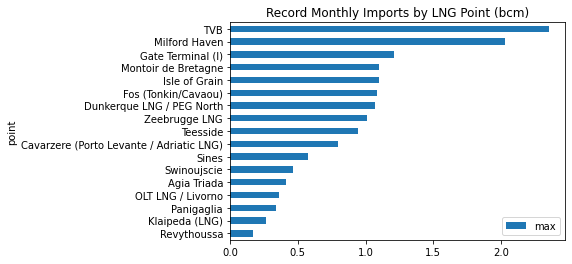

In [135]:
dff1.sort_values(by='max').plot.barh(x='point',y='max',title='Record Monthly Imports by LNG Point (bcm)')

## Check Stacked Bar (eg vs EC data)

In [179]:
## Create Dataframe to work with 

nor = df[df['label'].isin(['Dunkerque', 'Zeebrugge ZPT',
       'Emden (EPT1) (GTS)', 'Emden (EPT1) (OGE)',
       'Dornum GASPOOL','Nybro','Emden (EPT1) (Thyssengas)'])]
                          #'Easington','St. Fergus'

nor = nor.set_index(pd.DatetimeIndex(nor['dates']))
norpiv1 = nor.pivot_table(values='values',index=nor.index,columns='label')
norpiv = norpiv1.groupby(pd.Grouper(freq='Q')).sum(numeric_only=True)
norpiv=norpiv['2018':'2022-09-30']
norpiv = norpiv/1000000000

#To calculate totals.
#norpiv["sum"] = norpiv.sum(axis=1)

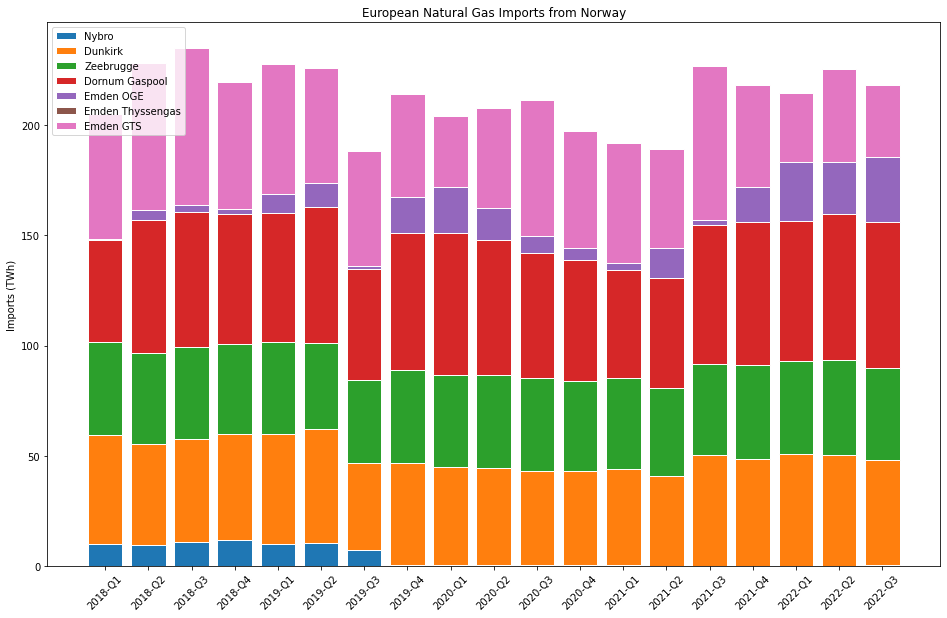

In [180]:
## Stacked Bar Plot 

labels = ['2018-Q1','2018-Q2','2018-Q3','2018-Q4',
          '2019-Q1','2019-Q2','2019-Q3','2019-Q4',
          '2020-Q1','2020-Q2','2020-Q3','2020-Q4',
          '2021-Q1','2021-Q2','2021-Q3','2021-Q4',
          '2022-Q1','2022-Q2','2022-Q3']

width = 0.8       

fig, ax = plt.subplots(figsize=(16,10))

ax.bar(labels, norpiv['Nybro'], width, label='Nybro', edgecolor='white')

ax.bar(labels, norpiv['Dunkerque'], width, 
       bottom=norpiv['Nybro'], 
       label='Dunkirk', edgecolor='white')

ax.bar(labels, norpiv['Zeebrugge ZPT'], width,
      bottom=norpiv['Nybro']+norpiv['Dunkerque'],
      label='Zeebrugge', edgecolor='white')

ax.bar(labels, norpiv['Dornum GASPOOL'], width, 
       bottom = norpiv['Nybro']+norpiv['Dunkerque']+norpiv['Zeebrugge ZPT'],
       label='Dornum Gaspool',edgecolor='white')

ax.bar(labels, norpiv['Emden (EPT1) (OGE)'], width, 
       bottom = norpiv['Nybro'] +norpiv['Dunkerque']+norpiv['Zeebrugge ZPT']+norpiv['Dornum GASPOOL'],
       label='Emden OGE',edgecolor='white')

ax.bar(labels, norpiv['Emden (EPT1) (Thyssengas)'], width, 
       bottom = norpiv['Nybro'] +norpiv['Dunkerque']+norpiv['Zeebrugge ZPT']+norpiv['Dornum GASPOOL']
       +norpiv['Emden (EPT1) (OGE)'],
       label='Emden Thyssengas',edgecolor='white')

ax.bar(labels, norpiv['Emden (EPT1) (GTS)'], width, 
       bottom = norpiv['Nybro'] +norpiv['Dunkerque']+norpiv['Zeebrugge ZPT']+norpiv['Dornum GASPOOL']
       +norpiv['Emden (EPT1) (OGE)'],
       label='Emden GTS',edgecolor='white')


ax.set_ylabel('Imports (TWh)')
ax.set_title('European Natural Gas Imports from Norway')
ax.legend()
plt.xticks(rotation=45)

plt.show()

## Compare by Plant: IEA vs Entsog

In [188]:
import os
os.chdir('C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\Code\imports')
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\imports'

In [235]:
IEA = pd.read_excel('Export_GTF_IEA_202208.xls',nrows=217)
del IEA['Unnamed: 2']

#cleaning the data into different format
IEA['identifier'] = IEA['Borderpoint'] # + '_' + IEA['Exit'] + '_' + IEA['Entry']
columns = IEA['identifier']
IEA = IEA.transpose()
IEA.columns = columns
IEA = IEA.reset_index()
IEA = IEA[4:171] ## Change the columns to have the last months

#datetime index
IEAplant = IEA.set_index(pd.DatetimeIndex(IEA['index']))
del IEAplant['index']

In [237]:
IEAplant = IEAplant.replace('#N/A()',np.NaN)

In [238]:
#This dictionary allows for more accurate comparison than my old for loop. 
IEAdict = {
    'Adriatic LNG': ['Cavarzere (Porto Levante / Adriatic LNG)'],
    'Almeria': ['Almería'],
    'BBL':['Bacton (BBL)'],
    'Barcelona': ['Barcelona'],
    'Beregdaróc': ['Beregdaróc 800 (HU) - Beregovo (UA) (HU>UA)',
                  'Beregdaróc 1400 (HU) - Beregovo (UA) (UA>HU)'],
    'Bilbao': ['Bilbao'],
   # 'Budince': ['Budince'],
    'Cartagena': ['Cartagena'],
    'Dornum': ['Dornum / NETRA (jordgas Transport)','Dornum GASPOOL'],
#     'Milford Haven': ['Dragon LNG','South Hook'],
    'Drozdowicze': ['Drozdovichi (UA)  -Drozdowicze (PL) '],
    'Dunkerque': ['Dunkerque LNG / PEG North'],
#     'Easington': ['Easington'],
    'Emden (EPT1)': ['Emden (EPT1) (GTS)','Emden (EPT1) (GUD)',
                    'Emden (EPT1) (OGE)','Emden (EPT1) (Thyssengas)'],
    'Emden (NPT)': ['Emden (NPT) (GTS)'],
    'Fos sur Mer': ['Fos (Tonkin/Cavaou)'],
    'Gate': ['Gate Terminal (I)'],
    'Gela': ['Gela'],
    'Huelva': ['Huelva'],
    'Imatra': ['Imatra'],
    'Isaccea': ['Isaccea (RO) - Orlovka (UA) I','Isaccea (RO) - Orlovka (UA) II','Isaccea (RO) - Orlovka (UA) III',
               'VIP Mediesu Aurit - Isaccea (RO-UA)'],
#     'Isle of Grain':['Isle of Grain'],
    'Kipoi': ['Kipi'],
    'Klaipeda': ['Klaipeda (LNG)'],
    'Kondratki': ['Kondratki'],
    'Kotlovka': ['Kotlovka'],
    'Livorno': ['OLT LNG / Livorno'],
    'Mazara del Vallo': ['Mazara del Vallo'],
    'Mediesu Aurit': ['VIP Mediesu Aurit - Isaccea (RO-UA)'],
    'Moffat':['Moffat (IE)'],
    'Montoir de Bretagne': ['Montoir de Bretagne'],
    'Narva': ['Narva'],
    'Nord Stream': ['Greifswald / NEL',
                   'Greifswald / OPAL'],
    'Nybro': ['Nybro'],
    'Panigaglia': ['Panigaglia'],
    'Revithoussa': ['Agia Triada'],
    'Sagunto': ['Sagunto'],
    'Sines': ['Sines'],
#     'St Fergus (3)': ['St Fergus'],
    'Swinoujscie': ['Swinoujscie'],
    'Tarifa': ['Tarifa'],
#     'Teesside via CATS': ['Teesside'],
    'Tietierowka': ['Tieterowka'],
    'Ungheni': ['Ungheni'],
    'Varska': ['Värska'],
    'Velke Kapusany': ['Uzhgorod (UA) - Velké Kapušany (SK)'],
    'Wysokoje': ['Wysokoje'],
    'Zeebrugge (LNG)': ['Zeebrugge LNG'],
    'Zeebrugge (ZPT)': ['Zeebrugge ZPT'],
    'Interconnector':['Zeebrugge IZT']
}

C:\Users\GIOVAN~1.SGA\AppData\Local\Temp/ipykernel_34328/3954327545.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfplant['dates'] = dfplant['dates'].str[:7]


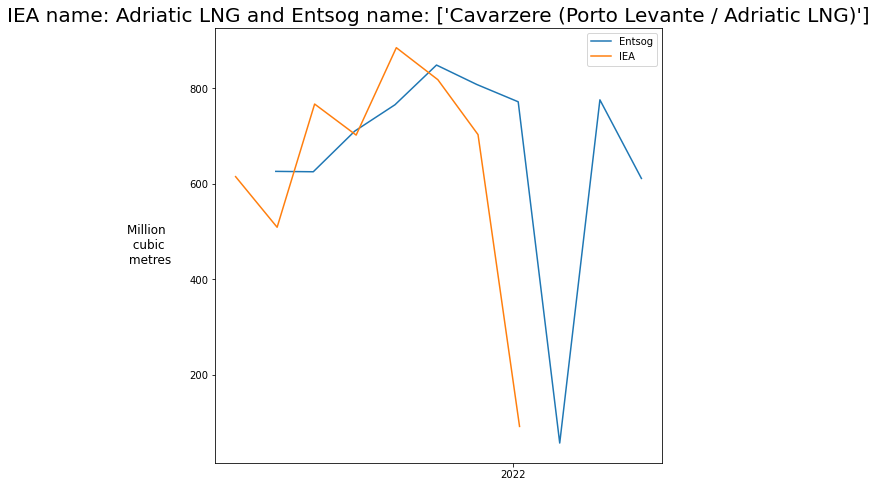

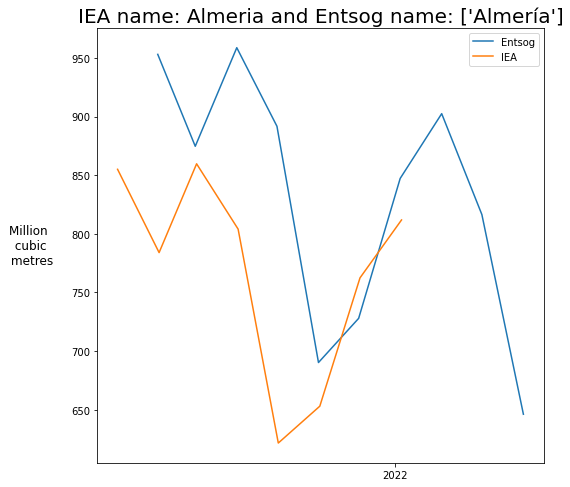

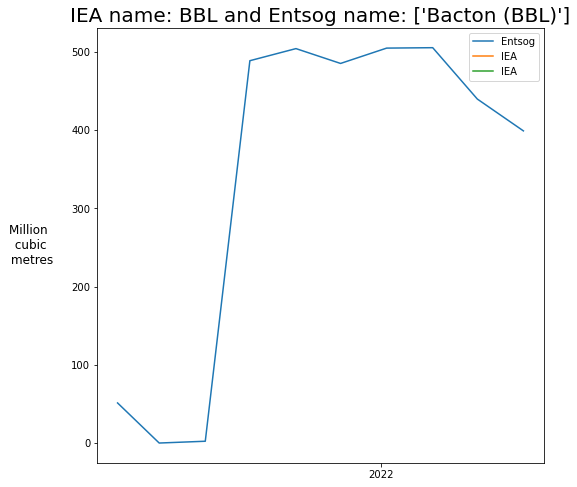

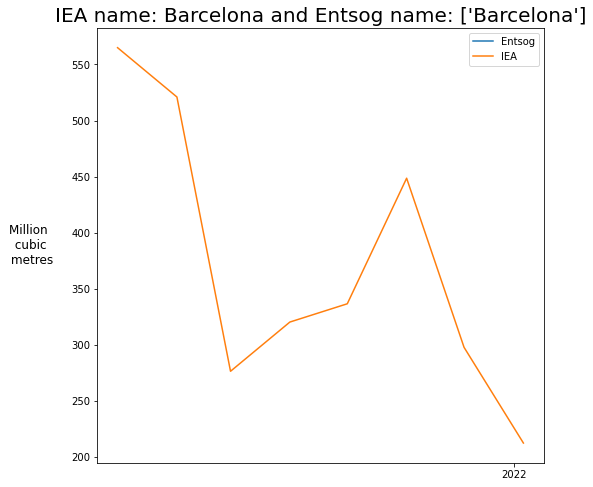

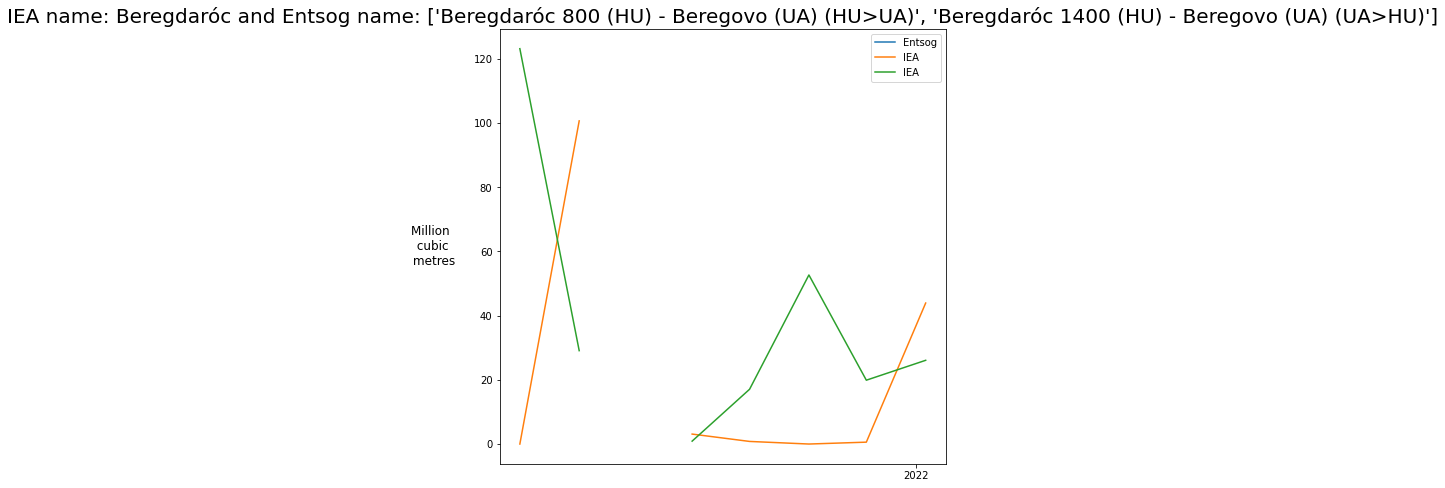

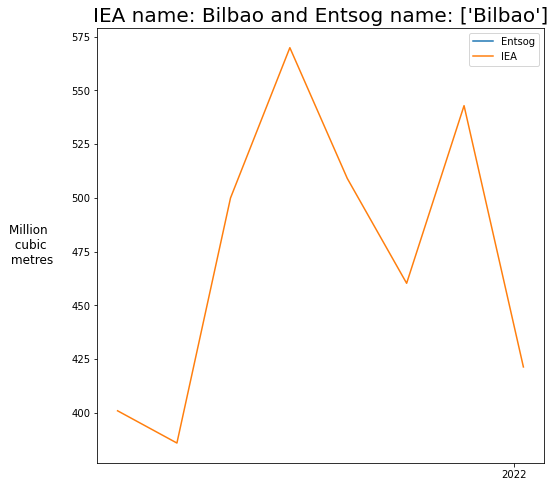

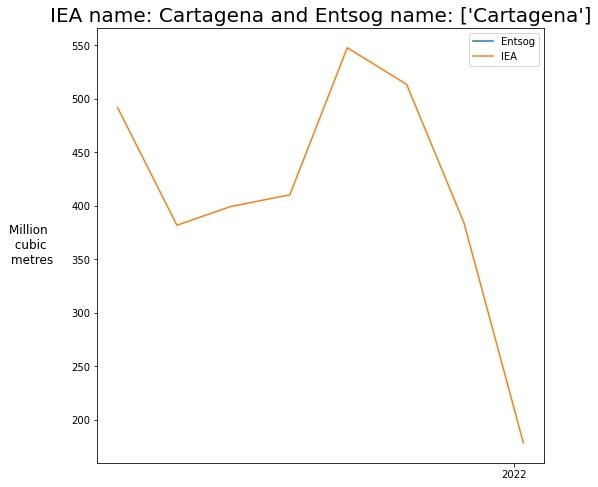

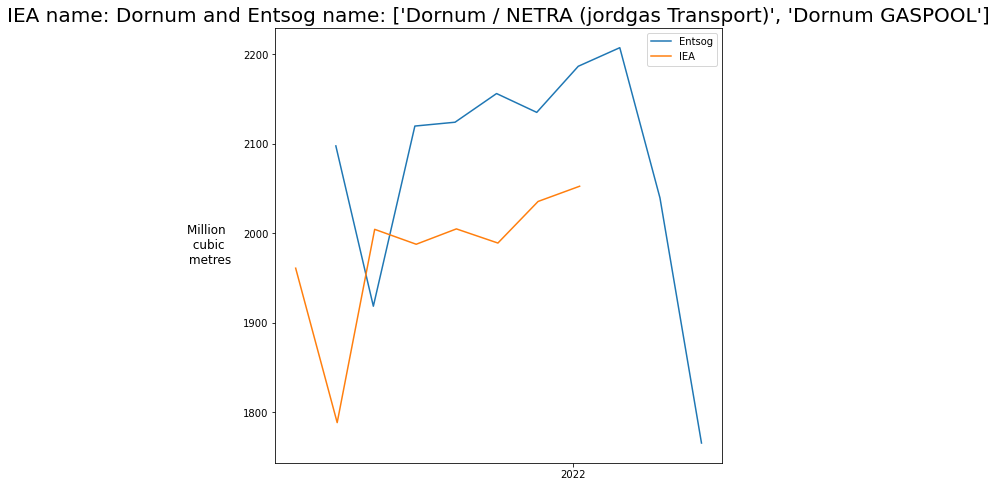

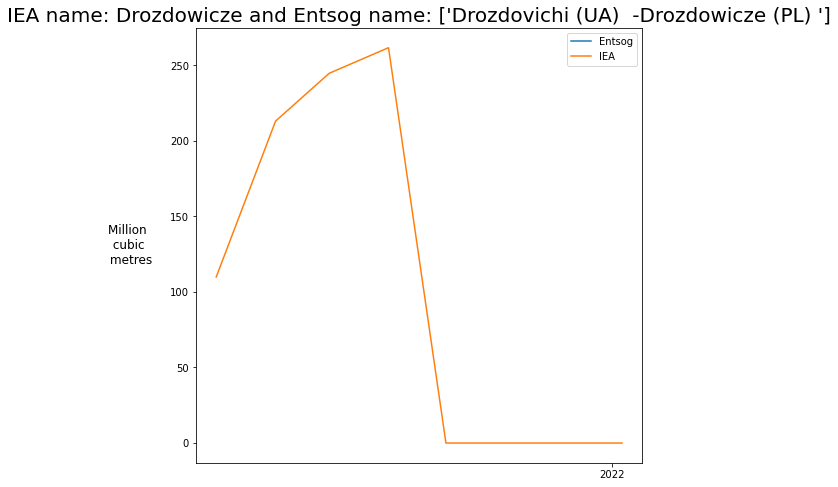

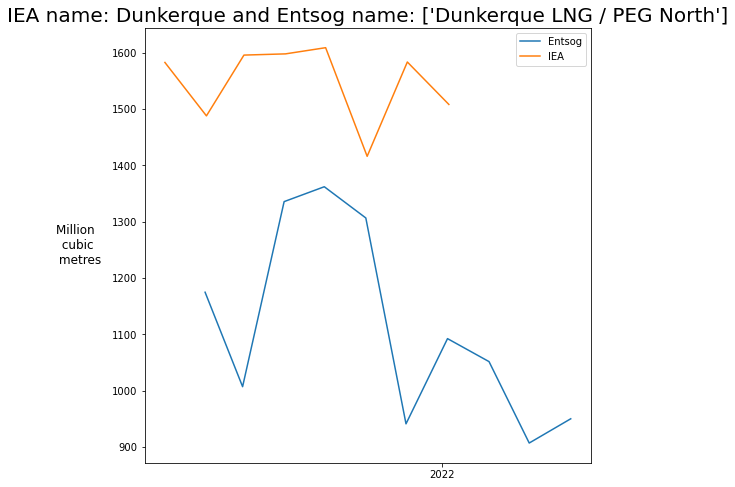

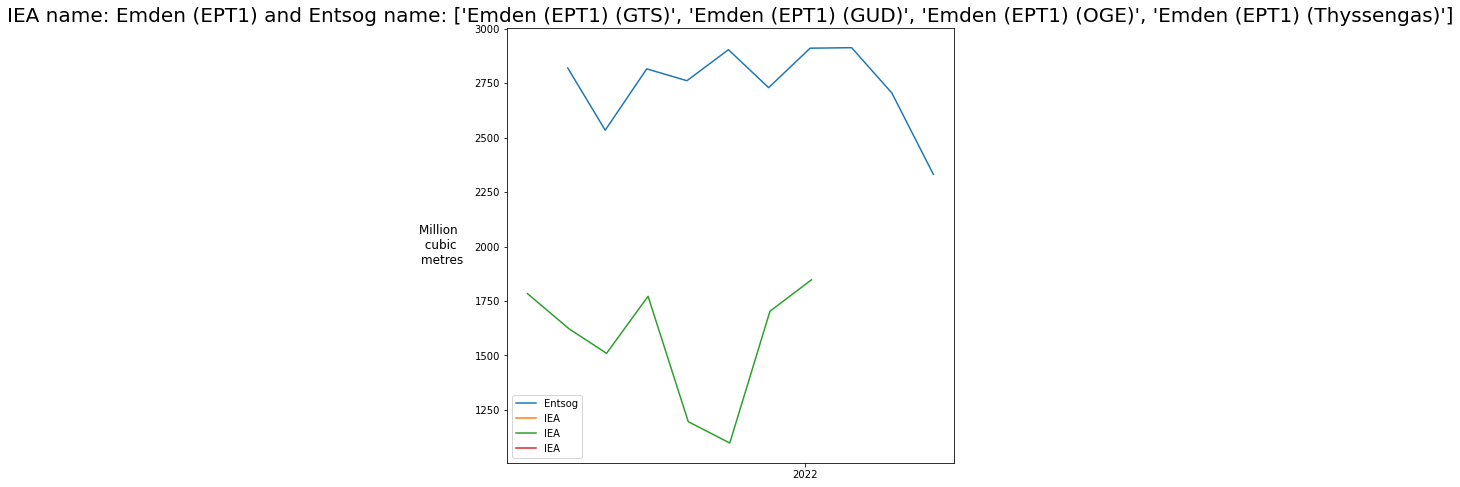

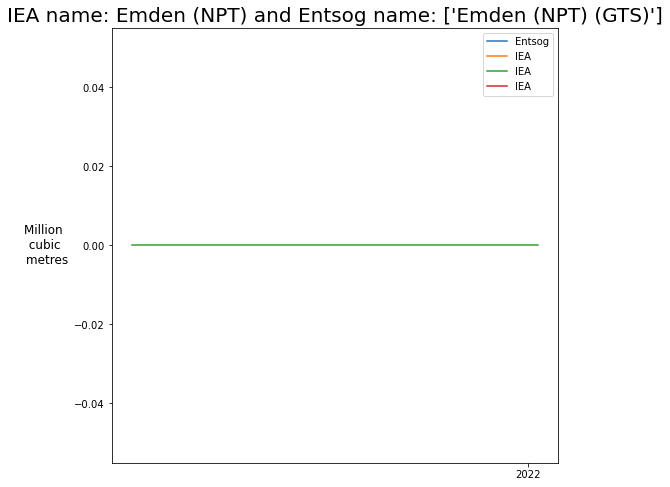

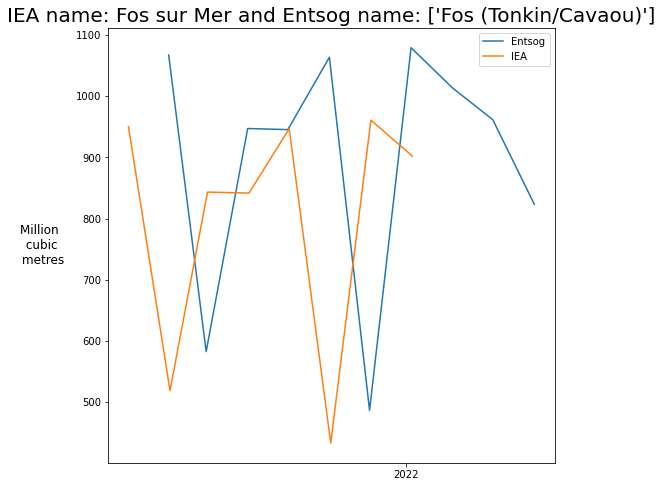

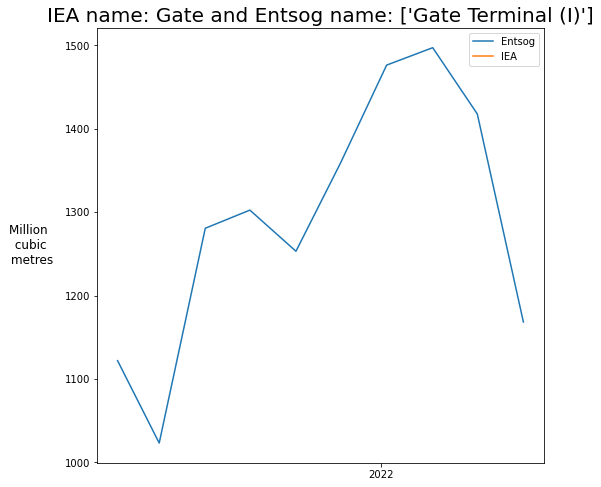

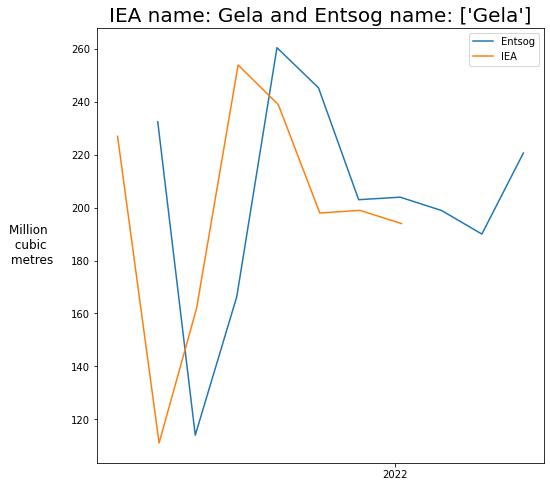

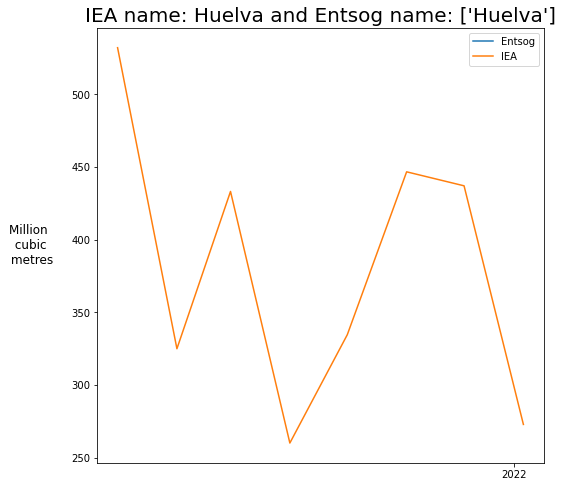

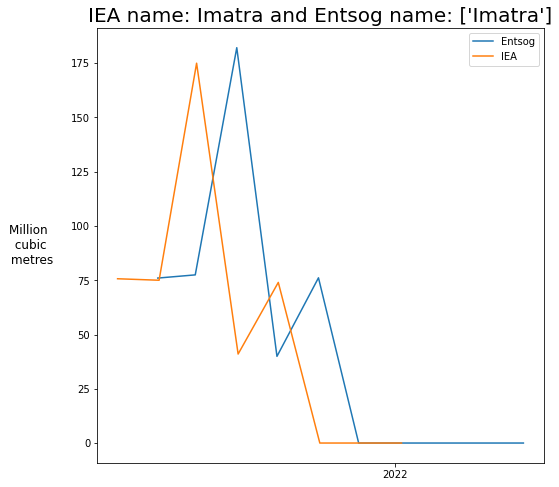

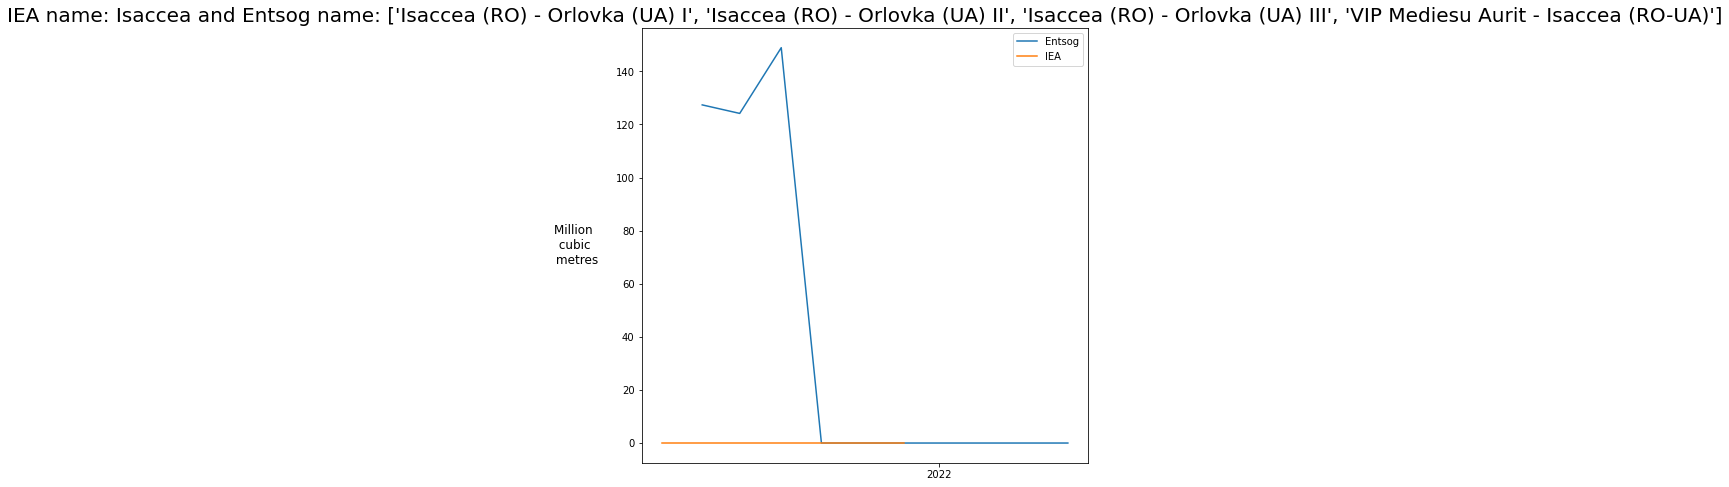

'Kipoi'
Kipoi


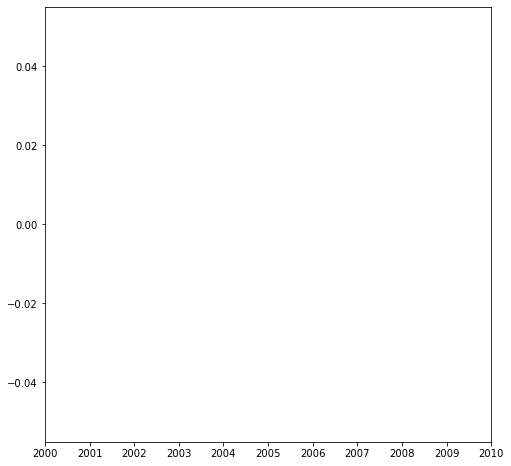

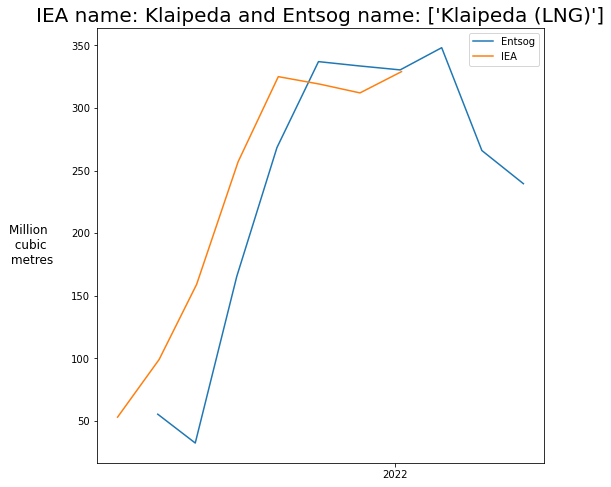

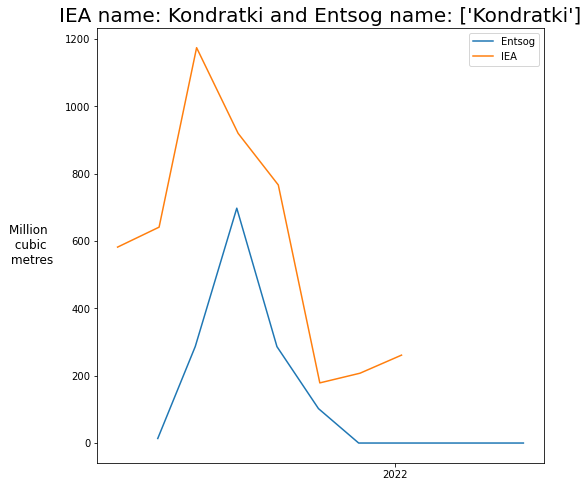

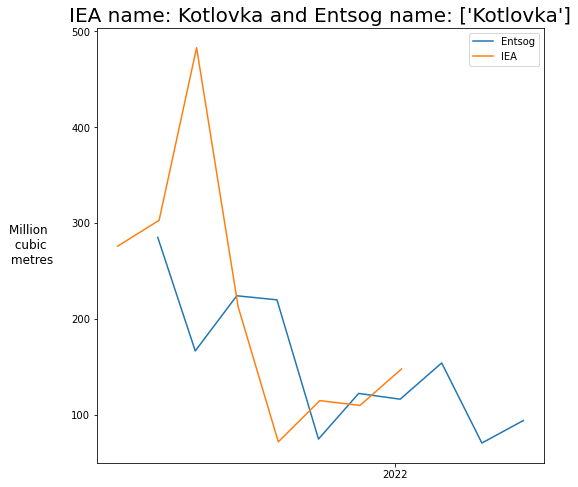

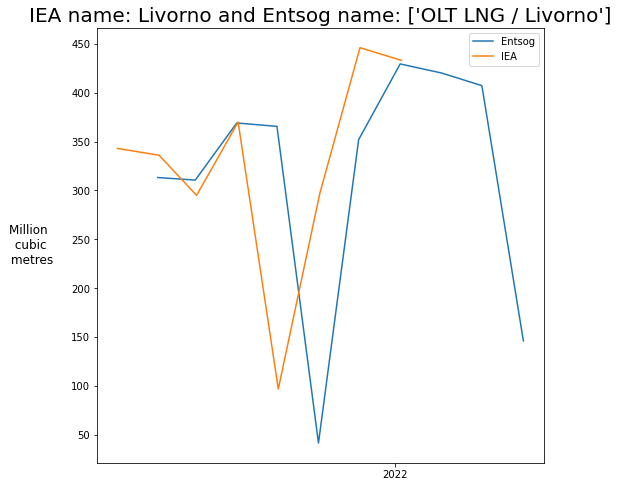

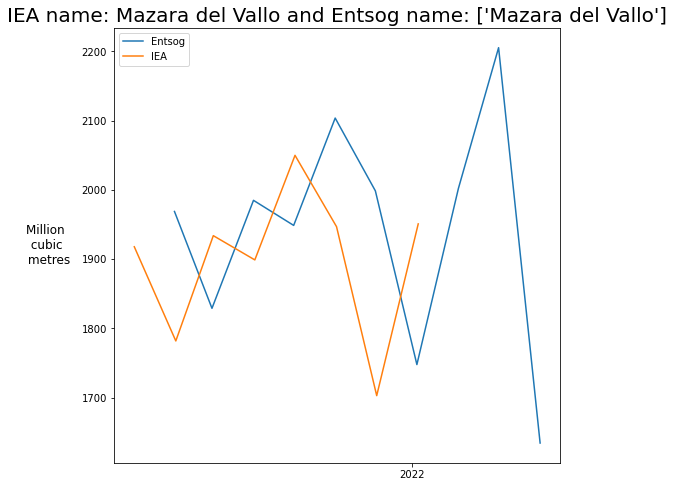

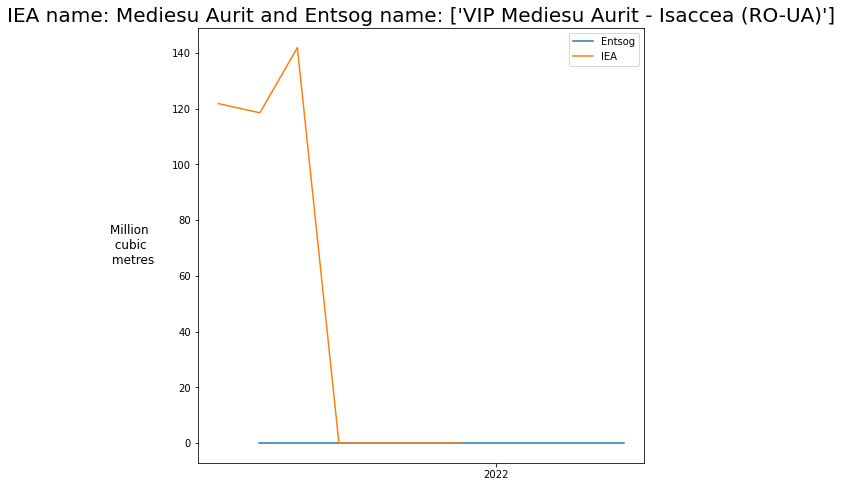

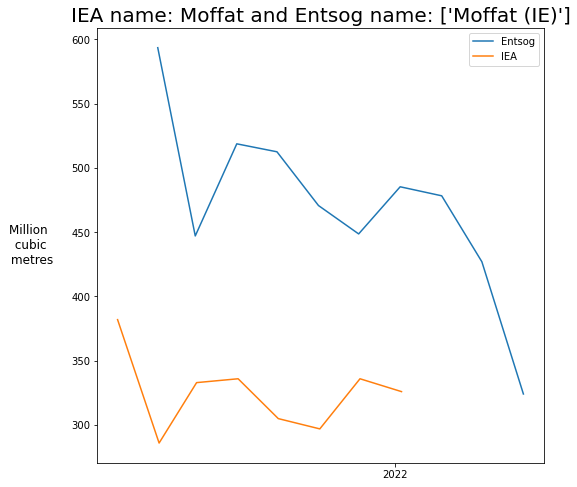

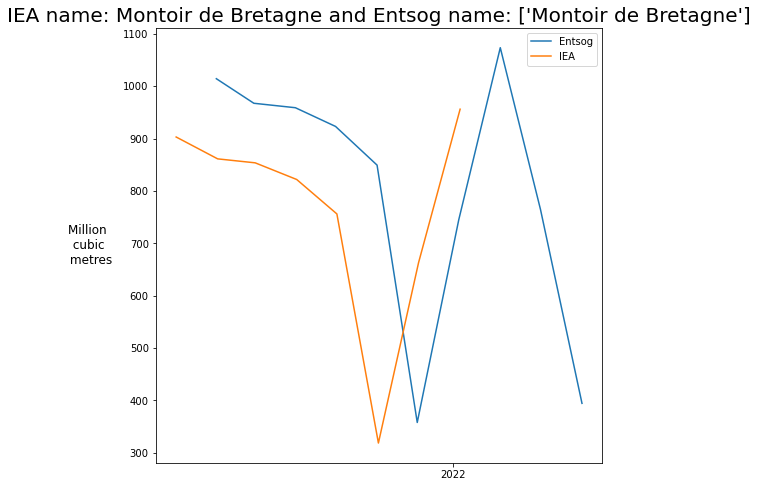

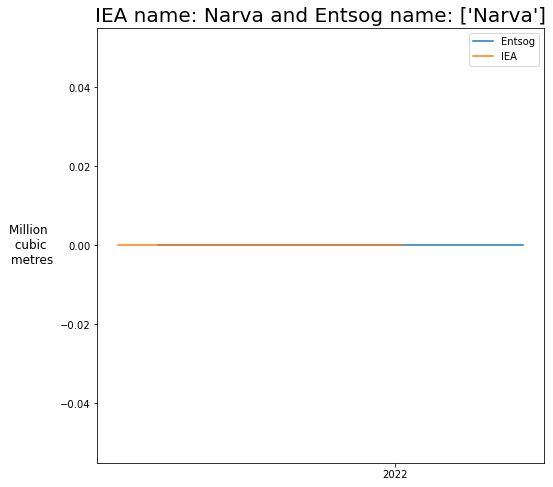

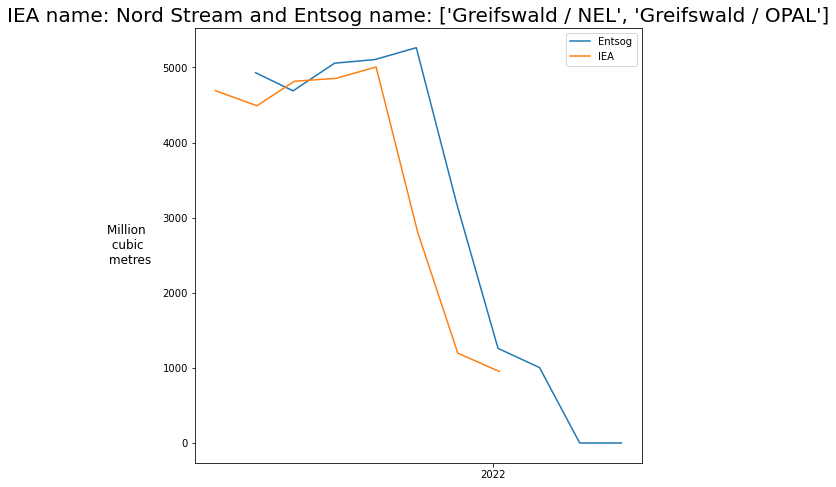

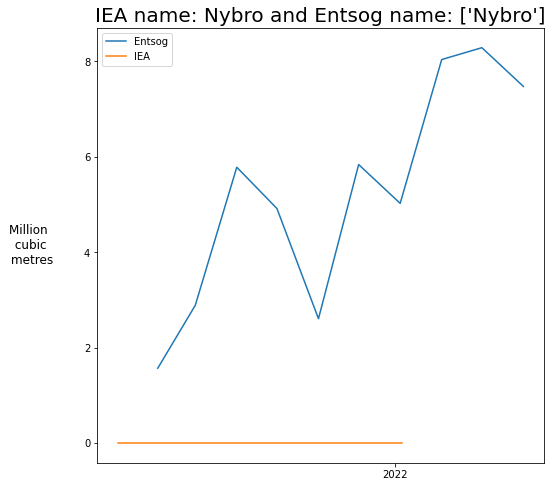

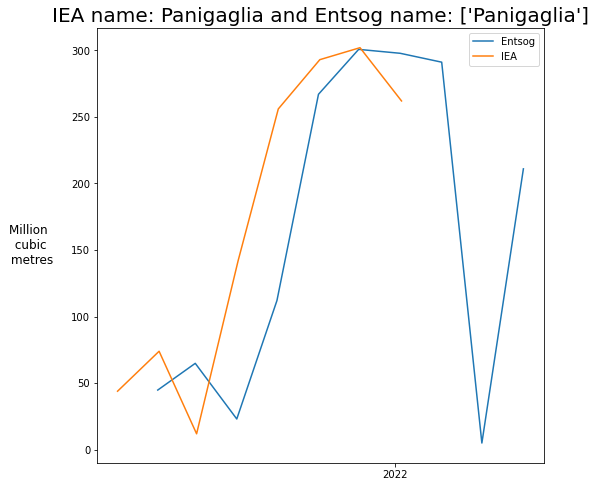

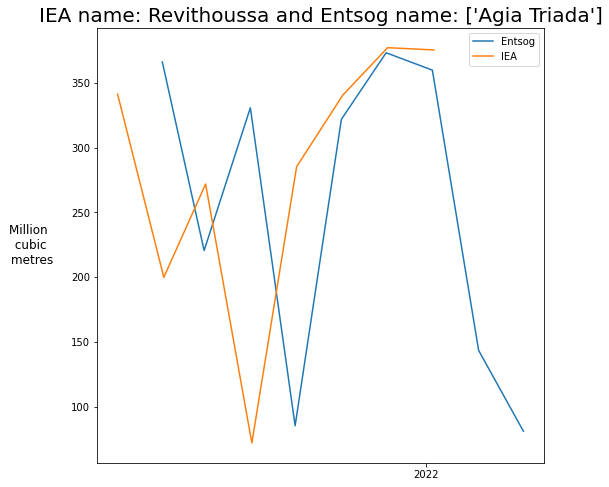

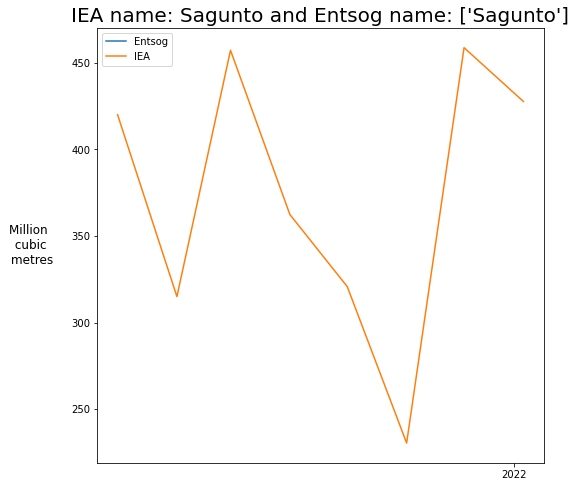

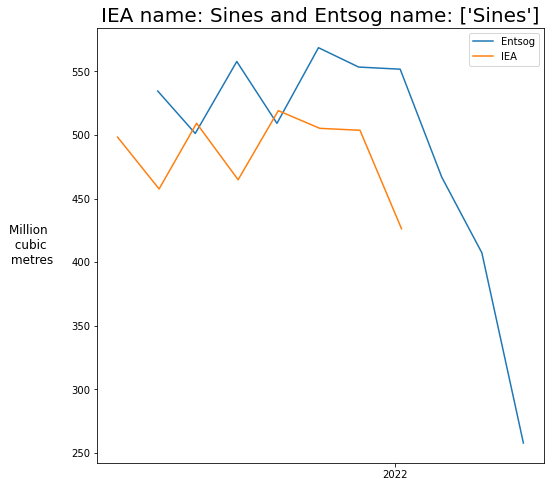

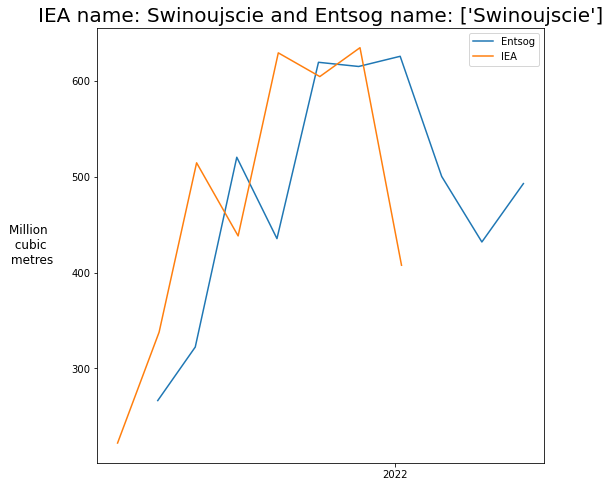

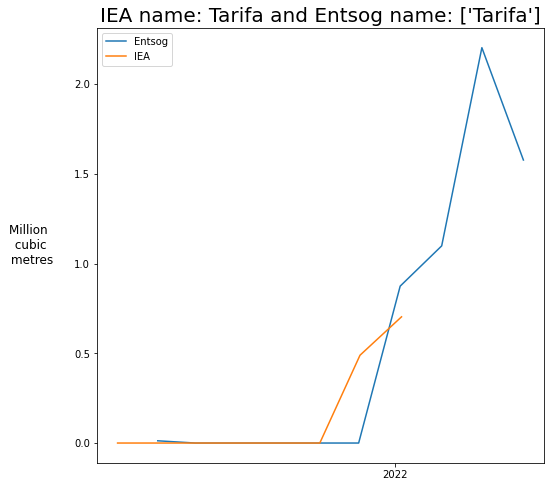

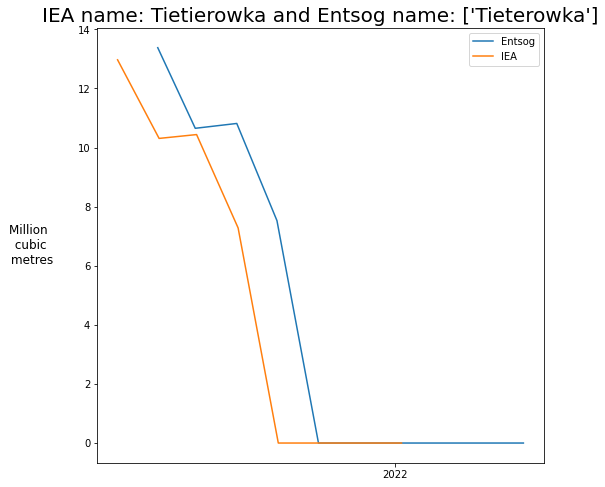

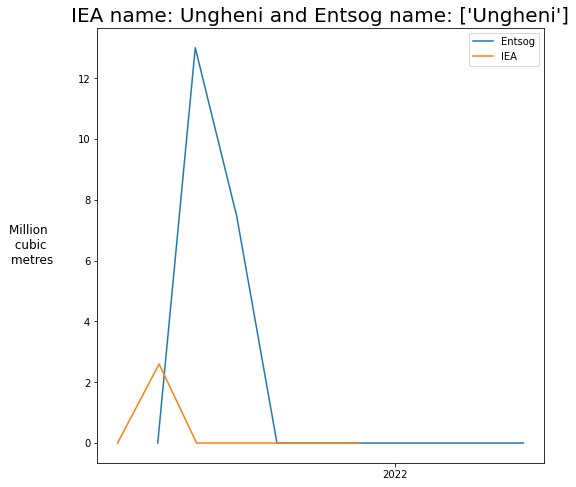

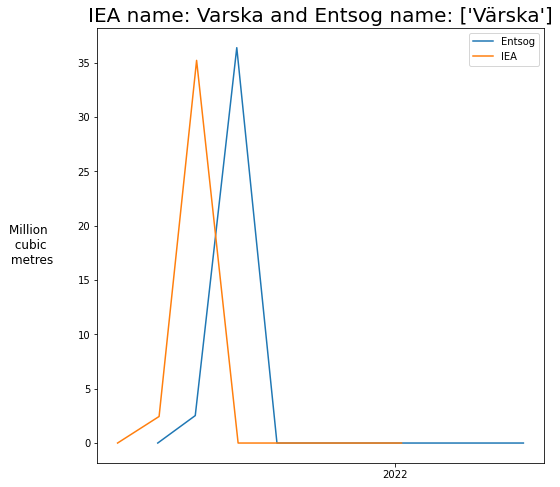

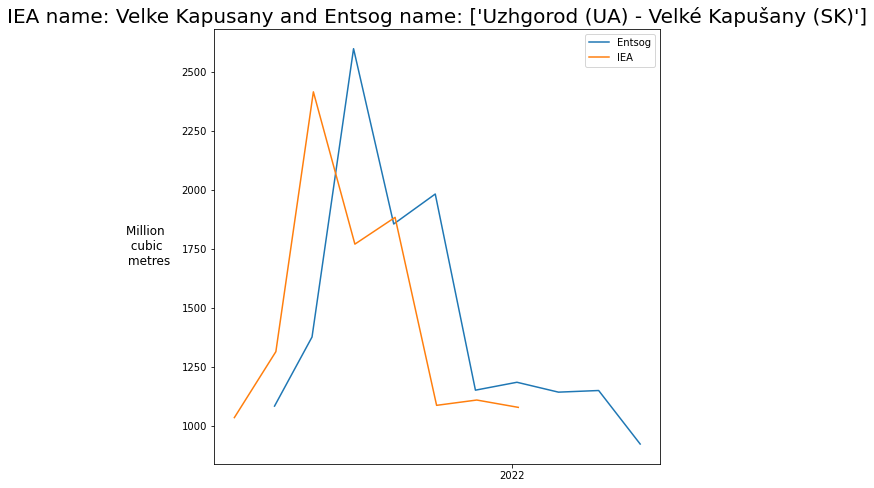

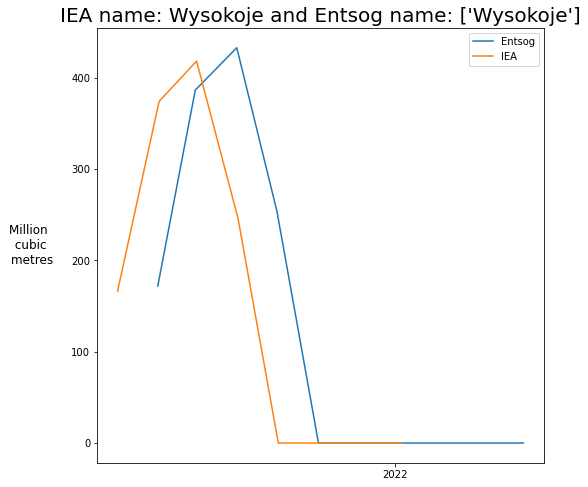

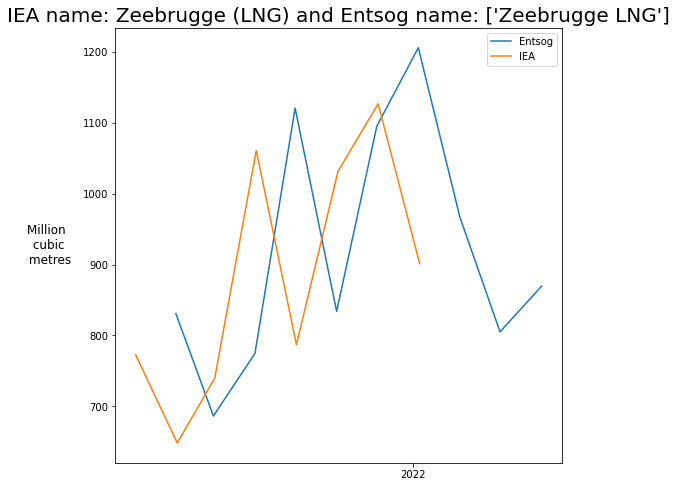

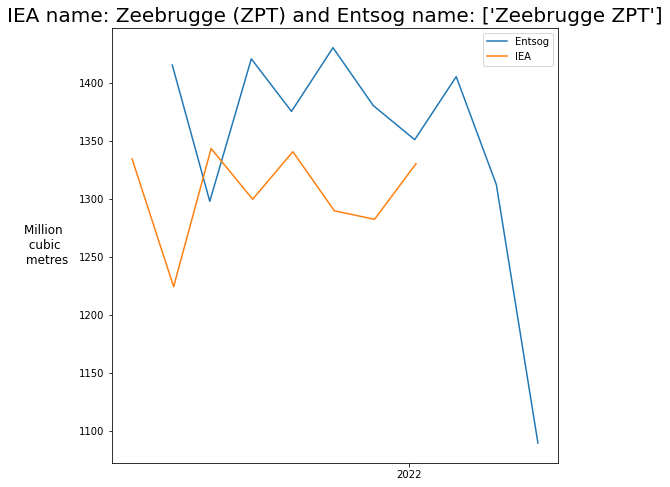

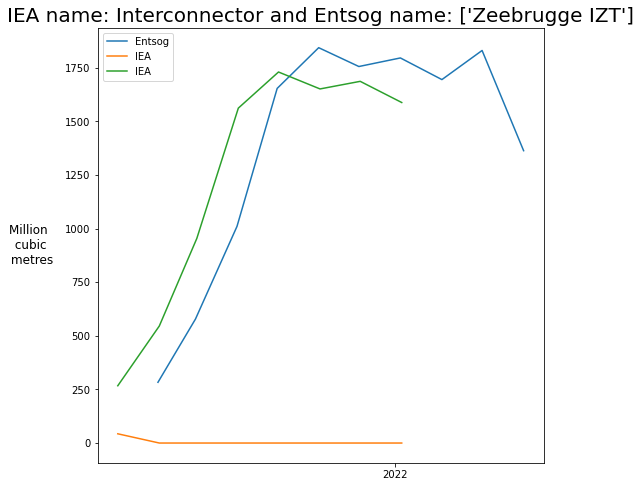

In [240]:
startdate = '2022-01'
enddate = '2022-10'

tick_spacing = 400
date_form = DateFormatter("%Y")

for key,value in zip(IEAdict,IEAdict.values()):
    try: 
        dfplant = df[df['label'].isin(value)] #already includes Ukraine exit. 
        dfplant['dates'] = dfplant['dates'].str[:7]
        dfplant = dfplant.set_index(pd.DatetimeIndex(dfplant['dates']))

        fig, ax = plt.subplots(figsize=(8, 8))

        ax.plot(dfplant.loc[startdate:enddate].groupby(pd.Grouper(freq='M')).sum(numeric_only=True)/converter,label='Entsog')
        ax.plot(IEAplant.loc[startdate:enddate][key],label='IEA')

        ax.xaxis.set_major_formatter(date_form)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
        ax.yaxis.set_label_coords(-0.15,.45)

        plt.title('IEA name: {} and Entsog name: {}'.format(key,value),fontsize=20)
        plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0) 
        plt.legend()
#         fig.savefig('IEAvsENTSOG/{}.png'.format(key),dpi=300,bbox_inches="tight")
        plt.show()
    
    except Exception as e:
        print(e)
        print(key) 

In [77]:
del df1['dates']

In [78]:
dfpivot = df1.pivot_table(values='values',index='dates',columns='aggregation',aggfunc='sum')

In [79]:
dfpivot

aggregation,Algeria,Azerbaijan,LNG,Libya,Norway,Russia,UK
dates,,,,,,,
2015-01-01,982609334.5,NaN,6.866024e+08,133668198.0,2.333167e+09,3.479783e+09,220038009.0
2015-01-02,925079474.0,NaN,6.934388e+08,135504915.0,2.338957e+09,3.519615e+09,243856193.0
2015-01-03,877858718.2,NaN,7.285640e+08,183451115.2,2.522203e+09,3.382665e+09,276288209.0
2015-01-04,874674263.0,NaN,6.835555e+08,135660759.0,2.512126e+09,3.399646e+09,246787734.0
2015-01-05,902406466.8,NaN,6.982848e+08,148208199.0,2.487983e+09,3.478338e+09,374534623.0
...,...,...,...,...,...,...,...
2022-11-13,819576889.0,376528037.0,3.587266e+09,99222564.0,2.618755e+09,7.126817e+08,936755103.7
2022-11-14,820930185.0,381155582.0,3.825170e+09,132190169.0,2.535054e+09,7.565741e+08,907875597.7
2022-11-15,823991871.0,364662654.0,3.653622e+09,132396520.0,2.565473e+09,8.501890e+08,367085090.4


In [80]:
dfplot1 = dfpivot.groupby(pd.Grouper(freq='M')).sum(numeric_only=True)

In [81]:
dfplot1 = dfplot1*kwhtwh

In [82]:
dfplot1.to_csv('monthlyimportsbysource.csv')

In [91]:
y_ec = range(-100,1200,100)

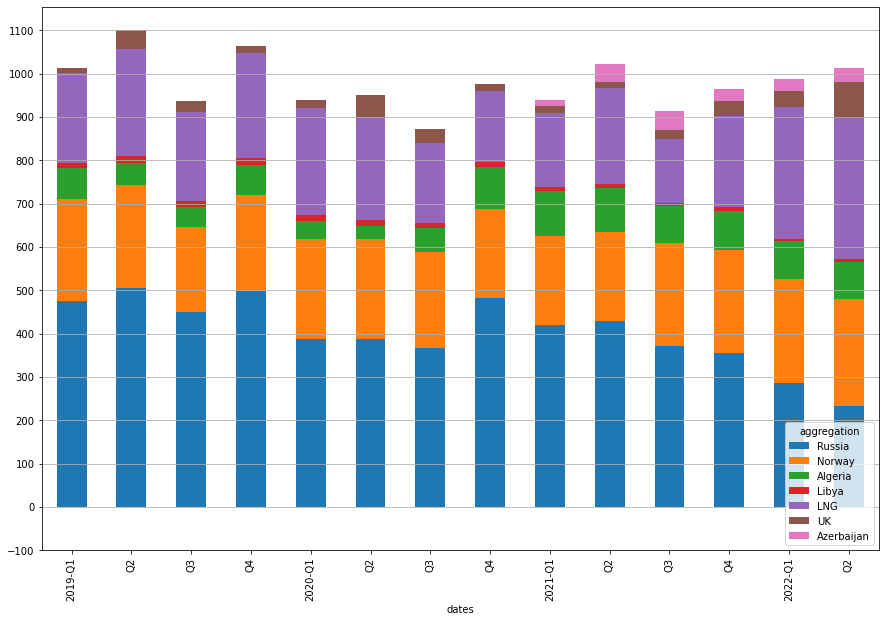

In [105]:
#We compare quite nicely with recent Eurostat report. (if anything we underestimate though)
dfplot = dfpivot.groupby(pd.Grouper(freq='Q')).sum(numeric_only=True)*kwhtwh

#ordering as EC's gas report
dfplot2 = dfplot[['Russia','Norway','Algeria','Libya','LNG','UK','Azerbaijan']]
ax = dfplot2['2019':'2022-06-30'].plot.bar(stacked=True,figsize=(15,10))
ax.set_xticklabels(['2019-Q1','Q2','Q3','Q4','2020-Q1','Q2','Q3','Q4','2021-Q1','Q2','Q3','Q4','2022-Q1','Q2'])
ax.set_yticks(y_ec)

plt.grid(axis='y')
# ax = dfplot['2018':'2021'].plot.bar(stacked=True,figsize=(10,10))
# ax.set_xticklabels(['2018-Q1','Q2','Q3','Q4','2019-Q1','Q2','Q3','Q4','2020-Q1','Q2','Q3','Q4','2021-Q1','Q2','Q3','Q4'])

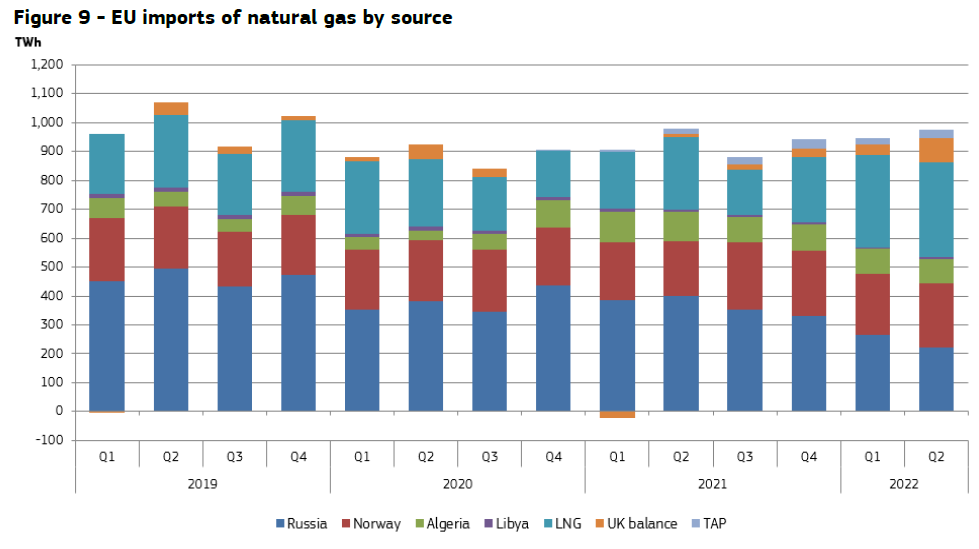

In [103]:
from IPython.display import Image
Image("imports by source.png")

In [27]:
## Merge with the aggregation which we use. 
mapping = pd.read_excel('locationsSAFE.xlsx')
mapping = mapping[['location','aggregation','aggregation2']]
df1 = df.merge(mapping,on='location',how='inner')

df1 = df1[df1['country']!='UA'] #exclude Ukraine imports. 
df1 = df1.drop_duplicates(subset=['dates', 'operator','label','country'], keep='last')
df1 = df1.set_index(pd.DatetimeIndex(df1['dates']))

#### A quick check comparing to the most recent report from the Commission which says in Q1 2021, net imports were 865 TWh. 
Page 9 on this report: https://ec.europa.eu/energy/sites/default/files/quarterly_report_on_european_gas_markets_q1_2021_final.pdf
We get 1,000 TWh but we include the UK. We also do not consider net, but there should be almost zero gas leaving the EU so should not make much difference.

Quarter 1: 
- Net imports: 865 TWh
- 20% of this was LNG = 865*0.2 = 173


From figure 9, 
- Russia: 390 TWh
- Norway: 200 TWh
- Algeria: 100 TWh

In [19]:
#EU27 (net) imports are calculated as 865TWh in Q1 2021 by the report
df1[df1['country'] != 'UK'].loc['2021-01-01':'2021-03-31']['values'].sum(numeric_only=True)/1000000000

862.6631812005971

In [20]:
## They have LNG imports at 170 TWh. 
vlng = df1[(df1['country'] != 'UK') & (df1['aggregation'] == 'LNG')].loc['2021-01-01':'2021-03-31']['values'].sum(numeric_only=True)/1000000000
vrus = df1[(df1['country'] != 'UK') & (df1['aggregation'] == 'Russia')].loc['2021-01-01':'2021-03-31']['values'].sum(numeric_only=True)/1000000000
vnor = df1[(df1['country'] != 'UK') & (df1['aggregation'] == 'Norway')].loc['2021-01-01':'2021-03-31']['values'].sum(numeric_only=True)/1000000000
valg = df1[(df1['country'] != 'UK') & (df1['aggregation'] == 'Algeria')].loc['2021-01-01':'2021-03-31']['values'].sum(numeric_only=True)/1000000000

print('LNG Q1 EU27 Imports:', vlng)
print('Russia Q1 EU27 Imports:', vrus)
print('Norway Q1 EU27 Imports:', vnor)
print('Algeria Q1 EU27 Imports:', valg)

LNG Q1 EU27 Imports: 169.7825515977
Russia Q1 EU27 Imports: 404.0914479299602
Norway Q1 EU27 Imports: 151.97678541193702
Algeria Q1 EU27 Imports: 103.732177806


In [168]:
## Comparison to EC data. 
Q1 = df1.loc['2021-01-01':'2021-03-31']
Q1['values'].sum(numeric_only=True)/1000000000

1070.5851090035972

In [169]:
Q1['values'][Q1['aggregation'] == 'Russia'].sum(numeric_only=True)/1000000000

404.0914479299602

#### Compare total across all countries

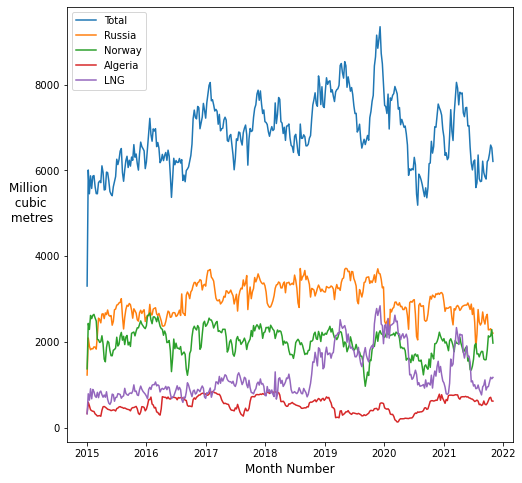

In [36]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(euplot['values'].loc['2015':'2021'],label='Total')
ax.plot(rusplot['values'].loc['2015':'2021'],label='Russia')
ax.plot(norplot['values'].loc['2015':'2021'],label='Norway')
ax.plot(algplot['values'].loc['2015':'2021'],label='Algeria')
ax.plot(lngplot['values'].loc['2015':'2021'],label='LNG')

plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)
plt.xlabel('Month Number',fontsize=12,rotation=0)
plt.legend(loc='best')

### Imports by exporting country 

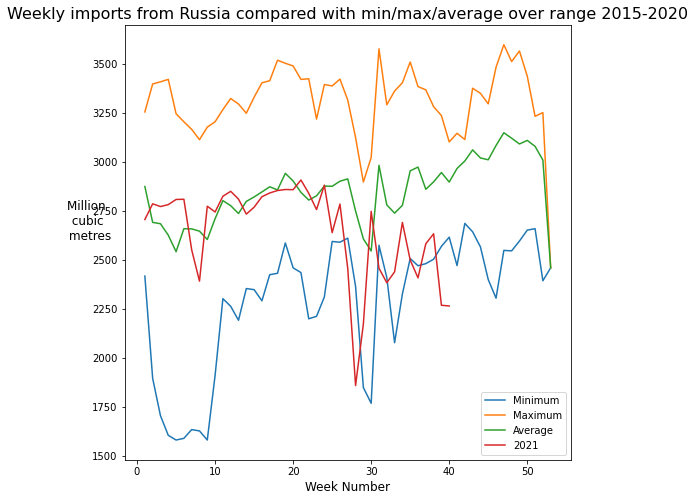

In [37]:
country = 'Russia'

ctemp = df1[df1['aggregation'] == country]
cplot = ctemp.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)[:'2021-10-15']/converter
cplot['week'] = cplot.index.isocalendar().week

minvalues = cplot['2015-01-05':'2020'].groupby('week').min()
maxvalues = cplot['2015-01-05':'2020'].groupby('week').max()
avgvalues = cplot['2015-01-05':'2020'].groupby('week').mean()
values2021 = cplot.loc['2021-01-05':].groupby('week').max()

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(minvalues,label='Minimum')
ax.plot(maxvalues,label='Maximum')
ax.plot(avgvalues,label='Average')
ax.plot(values2021,label='2021')

plt.title('Weekly imports from {} compared with min/max/average over range 2015-2020'.format(country),fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)
plt.xlabel('Week Number',fontsize=12,rotation=0)
plt.legend()
plt.show()
fig.savefig('figures/{}_imports.png'.format(country),dpi=300,bbox_inches="tight")

#### Imports by Route

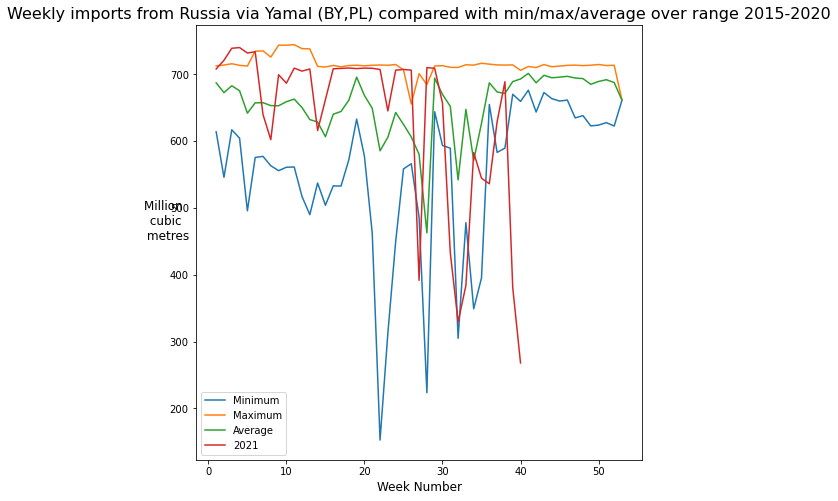

In [38]:
route = 'Yamal (BY,PL)'

rtemp = df1[df1['aggregation2'] == route]
rplot = rtemp.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)[:'2021-10-15']/converter
rplot['week'] = rplot.index.isocalendar().week

minvalues = rplot['2015-01-05':'2020'].groupby('week').min()
maxvalues = rplot['2015-01-05':'2020'].groupby('week').max()
avgvalues = rplot['2015-01-05':'2020'].groupby('week').mean()
values2021 = rplot.loc['2021-01-05':].groupby('week').max()

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(minvalues,label='Minimum')
ax.plot(maxvalues,label='Maximum')
ax.plot(avgvalues,label='Average')
ax.plot(values2021,label='2021')

plt.title('Weekly imports from Russia via {} compared with min/max/average over range 2015-2020'.format(route),fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)
plt.xlabel('Week Number',fontsize=12,rotation=0)
plt.legend()
plt.show()
fig.savefig('figures/{}_imports.png'.format(route),dpi=300,bbox_inches="tight")

In [450]:
IEA = pd.read_excel('IEAgas.xls',nrows=203)
del IEA['Borderpoint']
del IEA['Entry']
del IEA['MAXFLOW (Mm3/h)']
del IEA['Unnamed: 2']

IEAexport = IEA.groupby('Exit').sum(numeric_only=True).transpose().reset_index()
IEAexport = IEAexport.set_index(pd.DatetimeIndex(IEAexport['index']))

In [451]:
dfexporter = df.groupby(['exportcountry','dates']).sum(numeric_only=True).reset_index()
dfexporter = dfexporter.set_index(pd.DatetimeIndex(dfexporter['dates']))

In [452]:
IEAexport.columns

Index(['index', 'Algeria', 'Austria', 'Belarus', 'Belgium', 'Bulgaria',
       'Croatia', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France',
       'Georgia', 'Germany', 'Greece', 'Hungary', 'Iran', 'Italy', 'Latvia',
       'Libya', 'Liquefied Natural Gas', 'Lithuania', 'Morocco', 'Netherlands',
       'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'Slovak Republic',
       'Slovenia', 'Spain', 'Switzerland', 'Tunisia', 'Turkey', 'Ukraine',
       'United Kingdom'],
      dtype='object', name='Exit')

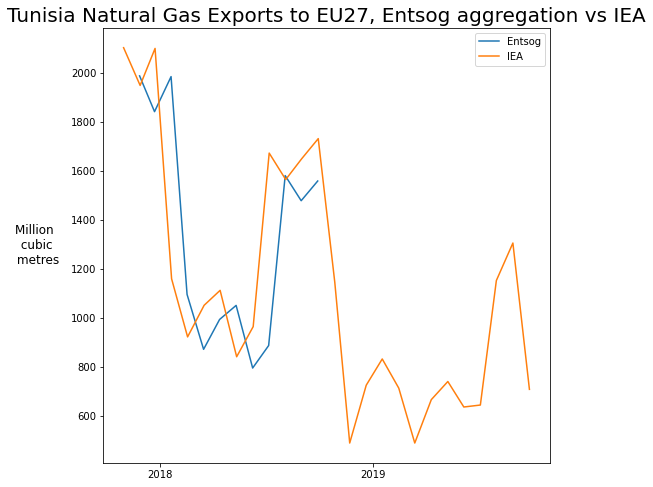

In [184]:
exporter = 'Tunisia'
startdate = '2021-01'
enddate = '2021-06'

tick_spacing = 400

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(dfexporter[dfexporter['exportcountry'] == exporter].groupby(pd.Grouper(freq='M')).sum(numeric_only=True)/converter,label='Entsog')
ax.plot(IEAexport.loc['2018':'2021-05'][exporter],label='IEA')

date_form = DateFormatter("%Y")
ax.xaxis.set_major_formatter(date_form)
ax.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
ax.yaxis.set_label_coords(-0.15,.45)

plt.title('{} Natural Gas Exports to EU27, Entsog aggregation vs IEA'.format(exporter),fontsize=20)
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0) #2018 prices
plt.legend()
plt.show()

## By Importing Country: IEA

In [142]:
import os
os.chdir('C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\Code\imports')
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\imports'

In [147]:
#read in the data, delete useless columns. 
IEA = pd.read_excel('Export_GTF_IEA_202208.xls',nrows=218)
del IEA['Unnamed: 2']
del IEA['MAXFLOW (Mm3/h)']

In [148]:
IEA

,Borderpoint,Exit,Entry,2008-10-01 00:00:00,2008-11-01 00:00:00,2008-12-01 00:00:00,2009-01-01 00:00:00,2009-02-01 00:00:00,2009-03-01 00:00:00,2009-04-01 00:00:00,...,2021-11-01 00:00:00,2021-12-01 00:00:00,2022-01-01 00:00:00,2022-02-01 00:00:00,2022-03-01 00:00:00,2022-04-01 00:00:00,2022-05-01 00:00:00,2022-06-01 00:00:00,2022-07-01 00:00:00,2022-08-01 00:00:00
0,Adriatic LNG,Liquefied Natural Gas,Italy,0.00,0.000,0.000,0.000,0.000,0.000,0.0,...,622.000,628.000,615.000,509.000,767.000,702.000,885.000,818.000,703.000,92.000
1,Almeria,Algeria,Spain,0.00,0.000,0.000,0.000,0.000,0.000,0.0,...,723.000,735.000,855.000,784.000,859.685,804.018,621.649,653.068,762.449,811.819
2,Alveringem,Belgium,France,0.00,0.000,0.000,0.000,0.000,0.000,0.0,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,Alveringem,France,Belgium,0.00,0.000,0.000,0.000,0.000,0.000,0.0,...,121.350,52.030,600.460,625.640,483.740,318.374,498.073,261.810,391.794,669.700
4,Badajoz,Portugal,Spain,0.00,0.000,0.000,0.000,12.390,2.000,0.0,...,4.000,5.000,16.000,51.000,34.662,39.924,71.259,0.000,3.691,5.977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,Zelzate (GTS),Belgium,Netherlands,156.56,108.959,53.837,101.810,85.078,150.379,0.0,...,438.210,168.850,412.980,569.460,811.270,1045.735,1226.174,1133.860,1256.458,1241.700
214,Zelzate (GTS),Netherlands,Belgium,0.00,0.000,0.000,0.000,0.000,0.000,0.0,...,57.140,319.570,10.110,0.000,0.330,0.000,0.000,0.000,0.000,0.000
215,Zelzate (Zebra),Belgium,Netherlands,133.51,111.406,109.636,130.616,113.335,113.070,0.0,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
216,Zevenaar,Germany,Netherlands,0.00,0.000,0.000,0.000,0.000,0.000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [149]:
## Create dataframe for extra-EU EU27 imports
IEA = IEA[IEA['Exit'].isin(['Liquefied Natural Gas','Algeria','Ukraine','Iran','Norway','Libya','Switzerland','Russia',
                     'Turkey','Belarus','Tunisia','Morocco','Georgia','United Kingdom'])]

In [150]:
IEA = IEA.replace('#N/A()',0)

In [151]:
##Create dataframe for EU27 imports. 
IEA['eu27'] = 'yes'
IEA.loc[IEA['Entry'].isin(['Ukraine','Turkey','Norway','Tunisia','Russia','Albania','Belarus','United Kingdom'
                           'Liquefied Natural Gas']),'eu27'] = 'no'

IEAEU = IEA.iloc[:,2:].groupby(['eu27']).sum(numeric_only=True)
IEAEU.columns = pd.to_datetime(IEAEU.columns) #tell python we are working with dates and times
IEAEU = IEAEU.transpose() 

In [152]:
#Groupby each countries imports. That is add all of the countries imports from different locations. 
IEAcountry = IEA.iloc[:,2:].groupby(['Entry']).sum(numeric_only=True)

In [153]:
IEAcountry.columns = pd.to_datetime(IEAcountry.columns) #tell python we are working with dates and times
IEAcountry = IEAcountry.transpose() #transpose because it is easier to plot that way 

#### Now we can plot for any import country we like over any date range. 

Text(0, 0.5, 'Million \n Cubic \n Metres')

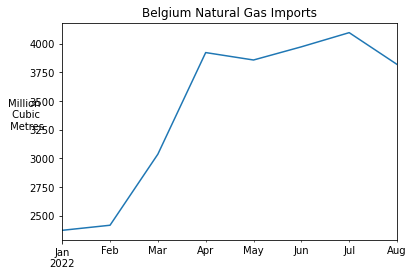

In [154]:
country = 'Belgium'
startdate = '2022-01'
enddate = '2022-10'

IEAcountry[country].loc[startdate:enddate].plot()
plt.title('{} Natural Gas Imports'.format(country))
plt.ylabel('Million \n Cubic \n Metres',rotation=0)

## Eurostat

In [42]:
df_euro = eurostat.get_data_df('nrg_cb_gasm') #this is the code for pply, transformation and consumption of gas - monthly data
EU_imports = df_euro[df_euro['nrg_bal'] == 'IMP'] #we filter to include Imports
EU_imports = EU_imports[EU_imports['unit'] == 'MIO_M3'] #filter to have only the unit million cubic metres.

In [43]:
ctries = EU_imports.iloc[:, 3] #we are storing this to set as our column names. 
EU_imports = EU_imports.transpose() #transpose for easier plotting. 
EU_imports.columns = ctries

In [44]:
EU_imports.head(5)

geo\time,AL,AT,BE,BG,CY,CZ,DE,DK,EA,EA19,...,PL,PT,RO,RS,SE,SI,SK,TR,UA,UK
nrg_bal,IMP,IMP,IMP,IMP,IMP,IMP,IMP,IMP,IMP,IMP,...,IMP,IMP,IMP,IMP,IMP,IMP,IMP,IMP,IMP,IMP
siec,G3000,G3000,G3000,G3000,G3000,G3000,G3000,G3000,G3000,G3000,...,G3000,G3000,G3000,G3000,G3000,G3000,G3000,G3000,G3000,G3000
unit,MIO_M3,MIO_M3,MIO_M3,MIO_M3,MIO_M3,MIO_M3,MIO_M3,MIO_M3,MIO_M3,MIO_M3,...,MIO_M3,MIO_M3,MIO_M3,MIO_M3,MIO_M3,MIO_M3,MIO_M3,MIO_M3,MIO_M3,MIO_M3
geo\time,AL,AT,BE,BG,CY,CZ,DE,DK,EA,EA19,...,PL,PT,RO,RS,SE,SI,SK,TR,UA,UK
2021M08,0,3840.07,2421.2,NaN,0,4083.26,11326.4,192.793,NaN,NaN,...,NaN,NaN,NaN,NaN,86.655,NaN,NaN,4170.9,NaN,NaN


In [45]:
EU_imports = EU_imports[4:] #first 4 rows not useful. 
EU_imports = EU_imports[::-1] #reverse order, because eurostat goes backwards.. 

In [46]:
#setting the index as datetime. 
EU_imports['month'] = EU_imports.index.str[5:7]
EU_imports['year'] = EU_imports.index.str[:4]
EU_imports['date'] = EU_imports['year'] + '-' + EU_imports['month'] + '-01'
EU_imports = EU_imports.set_index(pd.DatetimeIndex(EU_imports['date']))

### Exports by country for Eurostat

In [441]:
## EU exports
df_euro = eurostat.get_data_df('nrg_cb_gasm') #this is the code for pply, transformation and consumption of gas - monthly data
EU_exports = df_euro[df_euro['nrg_bal'] == 'EXP'] #we filter to include Imports
EU_exports = EU_exports[EU_exports['unit'] == 'MIO_M3'] #filter to have only the unit million cubic metres.

ctries = EU_exports.iloc[:, 3] #we are storing this to set as our column names. 

EU_exports = EU_exports.transpose() #transpose for easier plotting. 
EU_exports.columns = ctries

EU_exports = EU_exports[4:] #first 4 rows not useful. 
EU_exports = EU_exports[::-1] #reverse order, because eurostat goes backwards.. 

EU_exports['month'] = EU_exports.index.str[5:7]
EU_exports['year'] = EU_exports.index.str[:4]
EU_exports['date'] = EU_exports['year'] + '-' + EU_exports['month'] + '-01'
EU_exports = EU_exports.set_index(pd.DatetimeIndex(EU_exports['date']))

#### Now able to plot 

<AxesSubplot:xlabel='date'>

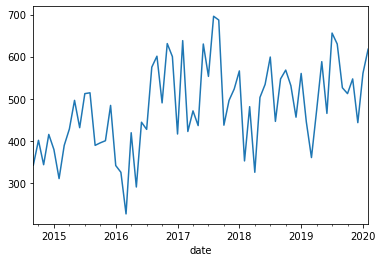

In [118]:
EU_imports['PT'].loc['2014-09':'2020-02'].plot()

### Compare IEA and Eurostat

In [1060]:
#ukr = ukrIs.groupby(pd.Grouper(freq='M')).sum(numeric_only=True)/converter
uk = dff[(dff['country'] == 'UK') & (dff['direction'] == 'entry')].groupby(pd.Grouper(freq='M')).sum(numeric_only=True)[:'2021-07']/converter
eu2 = EUdff[(EUdff['eu27'] == 'yes') & (EUdff['direction'] == 'entry')].groupby(pd.Grouper(freq='M')).sum(numeric_only=True)[:'2021-07']/converter
eu3 = EUdff[(EUdff['eu27'] == 'yes') & (EUdff['direction'] == 'exit')].groupby(pd.Grouper(freq='M')).sum(numeric_only=True)[:'2021-07']/converter

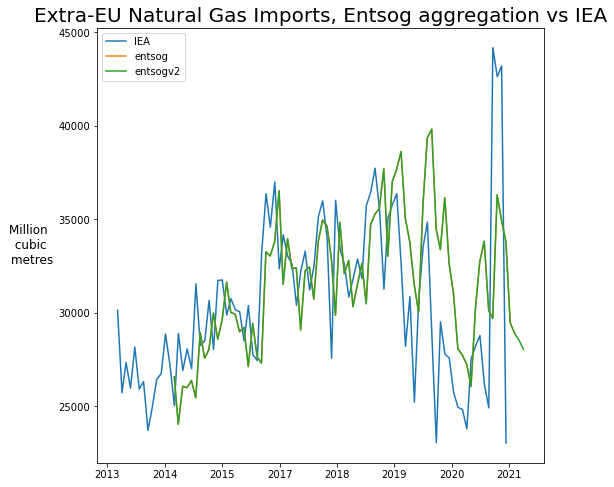

In [1219]:
country = 'EU27' #you need to also change the two digit code. 
startdate = '2014-01'
enddate = '2021-07'

tick_spacing = 400

fig, ax = plt.subplots(figsize=(8, 8))

#ax.plot(ukr,label='Ukrainian exit')
ax.plot(IEAEU['yes'].loc[startdate:enddate],label='IEA')
ax.plot(eu2,label='entsog')
ax.plot(euplot,label='entsogv2')

date_form = DateFormatter("%Y")
ax.xaxis.set_major_formatter(date_form)
ax.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
ax.yaxis.set_label_coords(-0.15,.45)

plt.title('Extra-EU Natural Gas Imports, Entsog aggregation vs IEA',fontsize=20)
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0) #2018 prices
plt.legend()
plt.show()
#fig.savefig('EU2.png',dpi=300,bbox_inches="tight")

### LNG Capacities